**Data Science with Generative AI:**

**EASY VISA**

Robust Data Modeling with Ensembling and Tuning Techniques


Submitted  BY: DEEPA C A


**Context**


Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

**Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

1. Facilitate the process of visa approvals.

2. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

**Exploratory Data Analysis (EDA)**

**Data Dictionary:**


The detailed data dictionary is given below.

case_id: ID of each visa application

continent: Information of continent the employee

education_of_employee: Information of education of the employee

has_job_experience: Does the employee have any job experience? Y= Yes; N = No

requires_job_training: Does the employee require any job training? Y = Yes; N = No

no_of_employees: Number of employees in the employer's company

yr_of_estab: Year in which the employer's company was established

region_of_employment: Information of foreign worker's intended

region of employment in the US.

prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position

case_status: Flag indicating if the Visa was certified or denied

**Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To impute missing values
from sklearn.impute import SimpleImputer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

**Loading The Dataset from CSV File**

In [ ]:
import pandas as pd
# Mounting the G Drive
from google.colab import drive
drive.mount("/content/drive")

# Loading the Datafeed placed in the Google drive path
df = pd.read_csv('/content/drive/MyDrive/EasyVisa.csv')

Mounted at /content/drive


**Find the First 5 rows**

In [ ]:
df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


**Find the Last 5 rows**

In [ ]:
df.tail(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


**Find the shape of dataset**

In [ ]:
df.shape

(25480, 12)

There are 25480 rows and 12 columns in the dataset.

**Find null or missing values**

In [ ]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no missing values or null values. Hence no need to impute data basis this.

**Find Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values.

**Statistical Inference of Numerical Data**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


**Inference of Categorical Data**

In [ ]:
df.describe(exclude='number').T

,count,unique,top,freq
case_id,25480,25480,EZYV25480,1
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [ ]:
df. nunique() # check the number of unique values

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [ ]:
print("Unique values for 'continent':", df['continent'].unique())
print("Count:" ,df['continent'].value_counts())
print("Percentage:", df['continent'].value_counts(normalize=True) * 100)
print("Unique values for 'education_of_employee':", df['education_of_employee'].unique())
print("Count:" ,df['education_of_employee'].value_counts())
print("Percentage:",df['education_of_employee'].value_counts(normalize=True) * 100)
print("Unique values for 'region_of_employment':", df['region_of_employment'].unique())
print("Count:" ,df['region_of_employment'].value_counts())
print("Percentage:",df['region_of_employment'].value_counts(normalize=True) * 100)
print("Unique values for 'unit_of_wage':", df['unit_of_wage'].unique())
print("Count:" ,df['unit_of_wage'].value_counts())
print("Percentage:",df['unit_of_wage'].value_counts(normalize=True) * 100)
print("Unique values for 'case_status':", df['case_status'].unique())
print("Count:" ,df['case_status'].value_counts())
print("Percentage:",df['case_status'].value_counts(normalize=True) * 100)

Unique values for 'continent': ['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']
Count: continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
Percentage: continent
Asia            66.173
Europe          14.647
North America   12.920
South America    3.344
Africa           2.162
Oceania          0.754
Name: proportion, dtype: float64
Unique values for 'education_of_employee': ['High School' "Master's" "Bachelor's" 'Doctorate']
Count: education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
Percentage: education_of_employee
Bachelor's    40.165
Master's      37.810
High School   13.422
Doctorate      8.603
Name: proportion, dtype: float64
Unique values for 'region_of_employment': ['West' 'Northeast' 'South' 'Midwest' 'Island']
Count: region_of_employment
Northeast    7195
South

In [ ]:
print("Unique value count  for 'has_job_experience':", df['has_job_experience'].value_counts())
print("Percentage:", df['has_job_experience'].value_counts(normalize=True) * 100)
print("Unique values for 'requires_job_training':", df['requires_job_training'].value_counts())
print("Percentage:", df['requires_job_training'].value_counts(normalize=True) * 100)
print("Unique values for 'full_time_position':", df['full_time_position'].value_counts())
print("Percentage:", df['full_time_position'].value_counts(normalize=True) * 100)

Unique value count  for 'has_job_experience': has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
Percentage: has_job_experience
Y   58.093
N   41.907
Name: proportion, dtype: float64
Unique values for 'requires_job_training': requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
Percentage: requires_job_training
N   88.403
Y   11.597
Name: proportion, dtype: float64
Unique values for 'full_time_position': full_time_position
Y    22773
N     2707
Name: count, dtype: int64
Percentage: full_time_position
Y   89.376
N   10.624
Name: proportion, dtype: float64


### Observations on Percentage Distribution of Categorical Columns:

*   **`continent`**: Asia is the dominant continent, accounting for approximately **66.17%** of applications, followed by Europe (14.65%) and North America (12.92%). Africa, South America, and Oceania have significantly smaller proportions.

*   **`education_of_employee`**: Bachelor's and Master's degrees are the most common education levels among applicants, representing **40.16%** and **37.81%** respectively. High School and Doctorate degrees make up smaller portions.

*   **`region_of_employment`**: The Northeast (28.24%), South (27.54%), and West (25.85%) regions of the US are the most frequently chosen for employment. The Midwest (16.90%) and Island (1.47%) regions are less common.

*   **`unit_of_wage`**: The vast majority of wages are reported on a Yearly basis (**90.12%**), indicating that most positions are salaried. Hourly wages account for 8.47%, with Weekly and Monthly being very rare.

*   **`case_status`**: Approximately **66.79%** of applications are Certified, while **33.21%** are Denied. This indicates a higher rate of approval than denial.

### Additional Observations on Percentage Distribution:

*   **`has_job_experience`**: The majority of applicants (**58.09%**) possess job experience, indicating a preference for experienced professionals. Approximately **41.91%** do not have prior job experience.

*   **`requires_job_training`**: A significant majority of applicants (**88.40%**) do not require job training, suggesting that employers are primarily looking for individuals ready to work immediately. Only **11.60%** require training.

*   **`full_time_position`**: Most visa applications are for full-time positions, accounting for **89.38%**, reflecting a strong preference for permanent and dedicated roles. Part-time positions make up **10.62%** of applications.

1. Unique values for 'continent': ['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']

2. Unique values for 'education_of_employee': ['High School' "Master's" "Bachelor's" 'Doctorate']

3. Unique values for 'region_of_employment': ['West' 'Northeast' 'South' 'Midwest' 'Island']

4. Unique values for 'unit_of_wage': ['Hour' 'Year' 'Week' 'Month']

5. Unique values for 'case_status': ['Denied' 'Certified']

**Exploratory Data Analysis**

**Univariate Analysis For Numerical Columns**


Descriptive statistics for no_of_employees:
count    25480.000
mean      5667.043
std      22877.929
min        -26.000
25%       1022.000
50%       2109.000
75%       3504.000
max     602069.000
Name: no_of_employees, dtype: float64


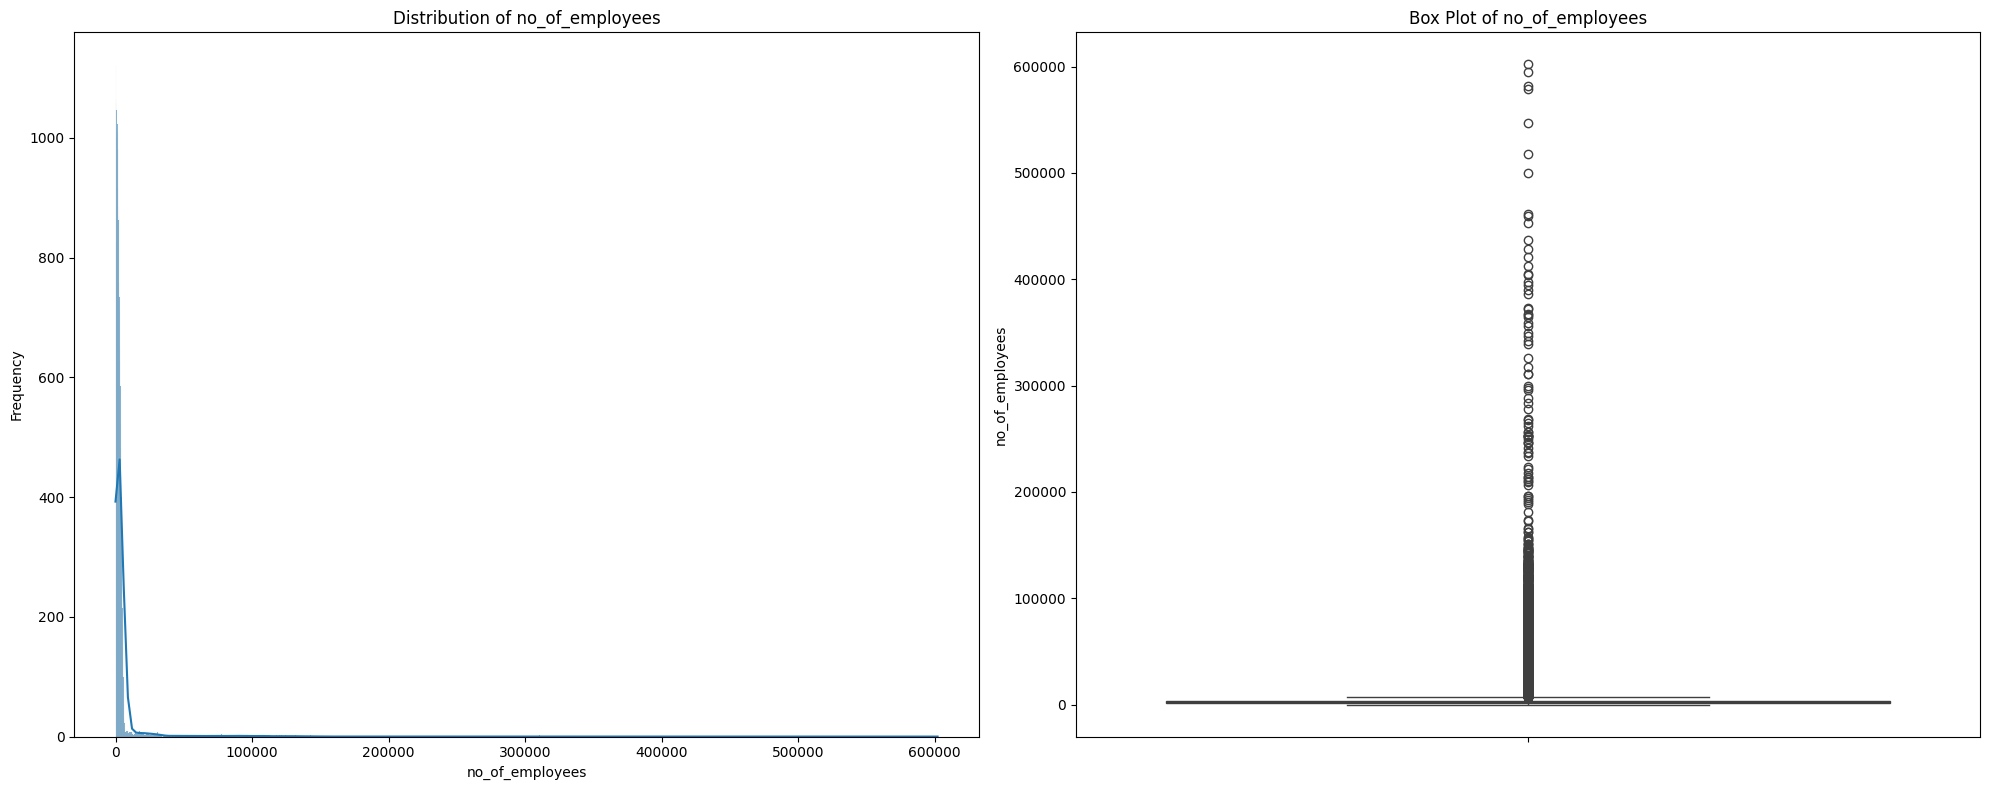

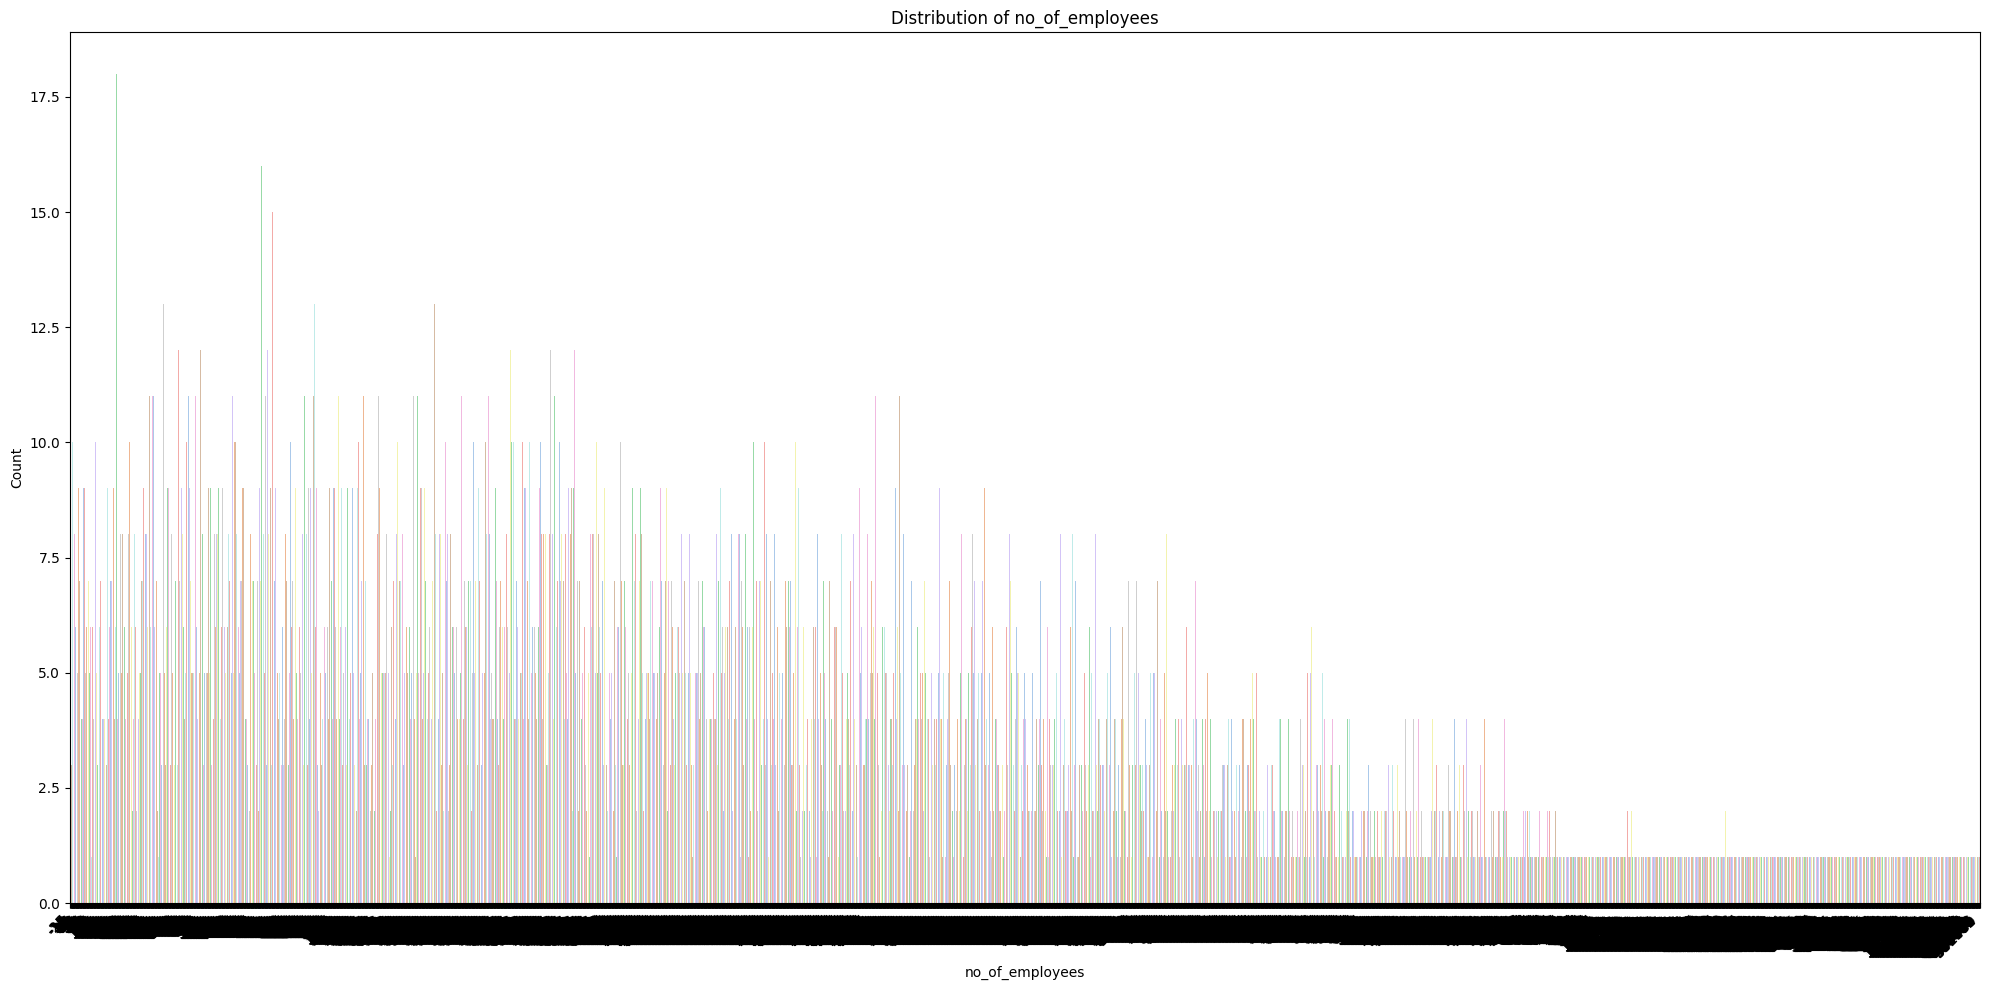


Descriptive statistics for yr_of_estab:
count   25480.000
mean     1979.410
std        42.367
min      1800.000
25%      1976.000
50%      1997.000
75%      2005.000
max      2016.000
Name: yr_of_estab, dtype: float64


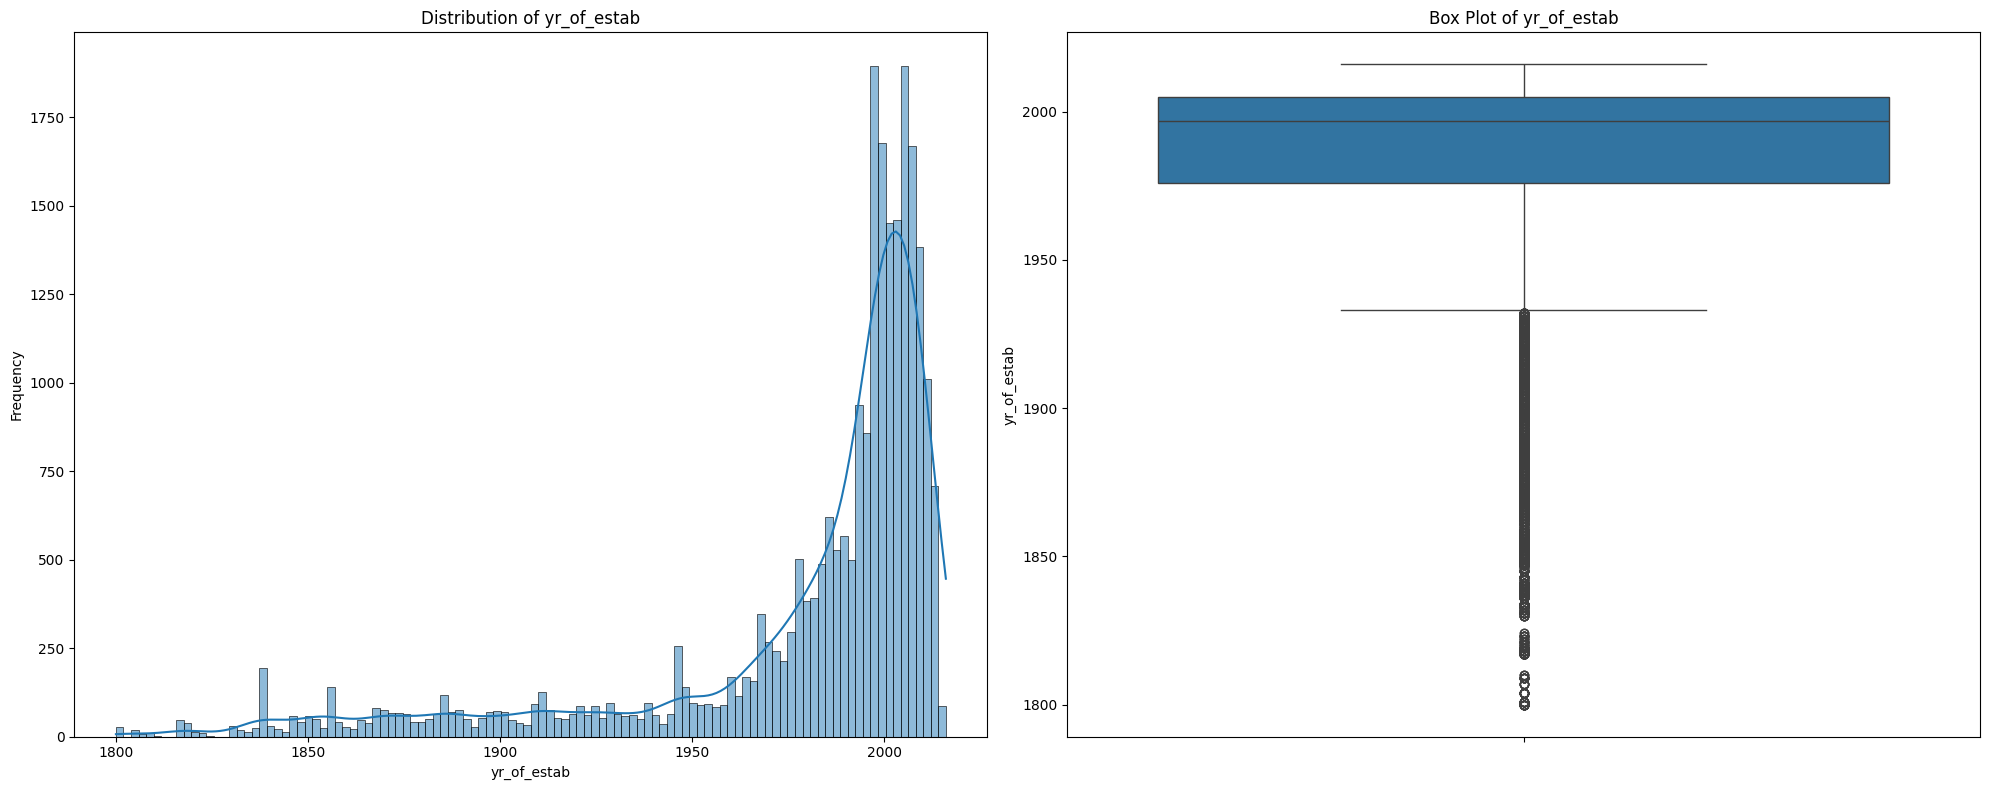

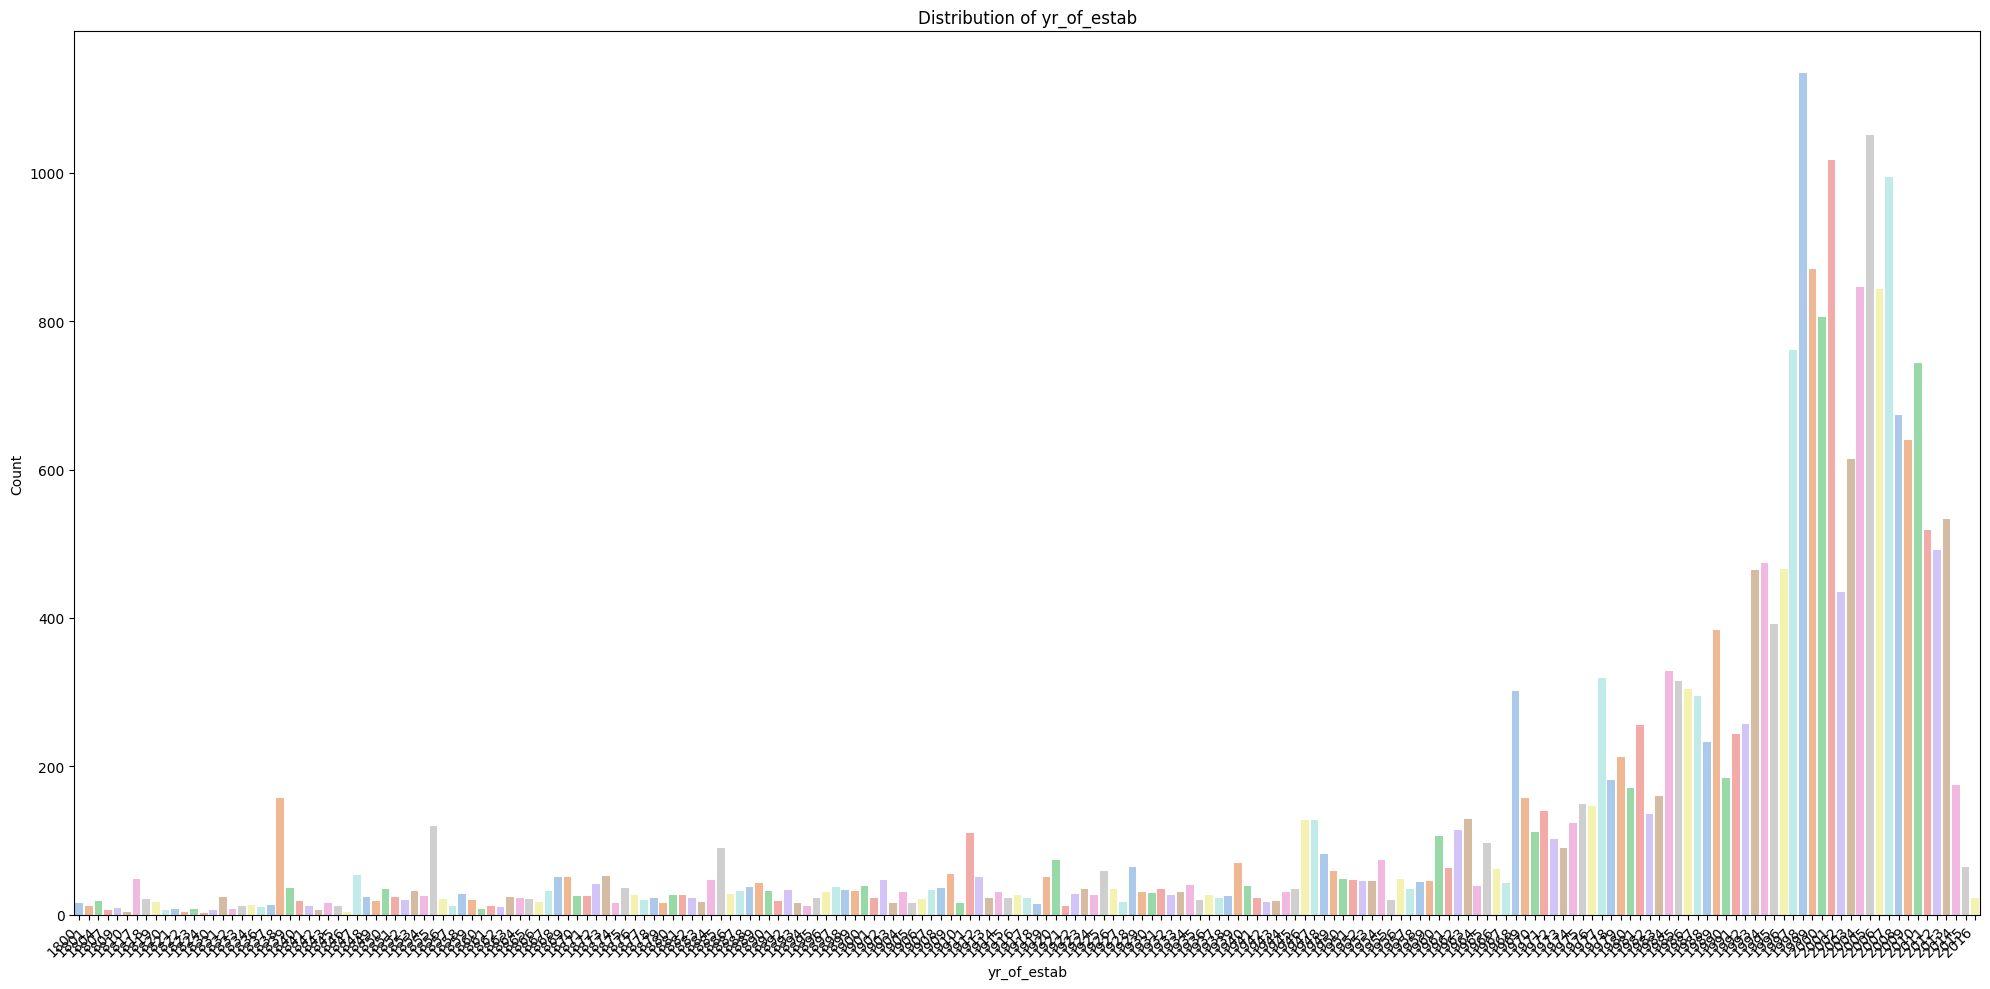


Descriptive statistics for prevailing_wage:
count    25480.000
mean     74455.815
std      52815.942
min          2.137
25%      34015.480
50%      70308.210
75%     107735.513
max     319210.270
Name: prevailing_wage, dtype: float64


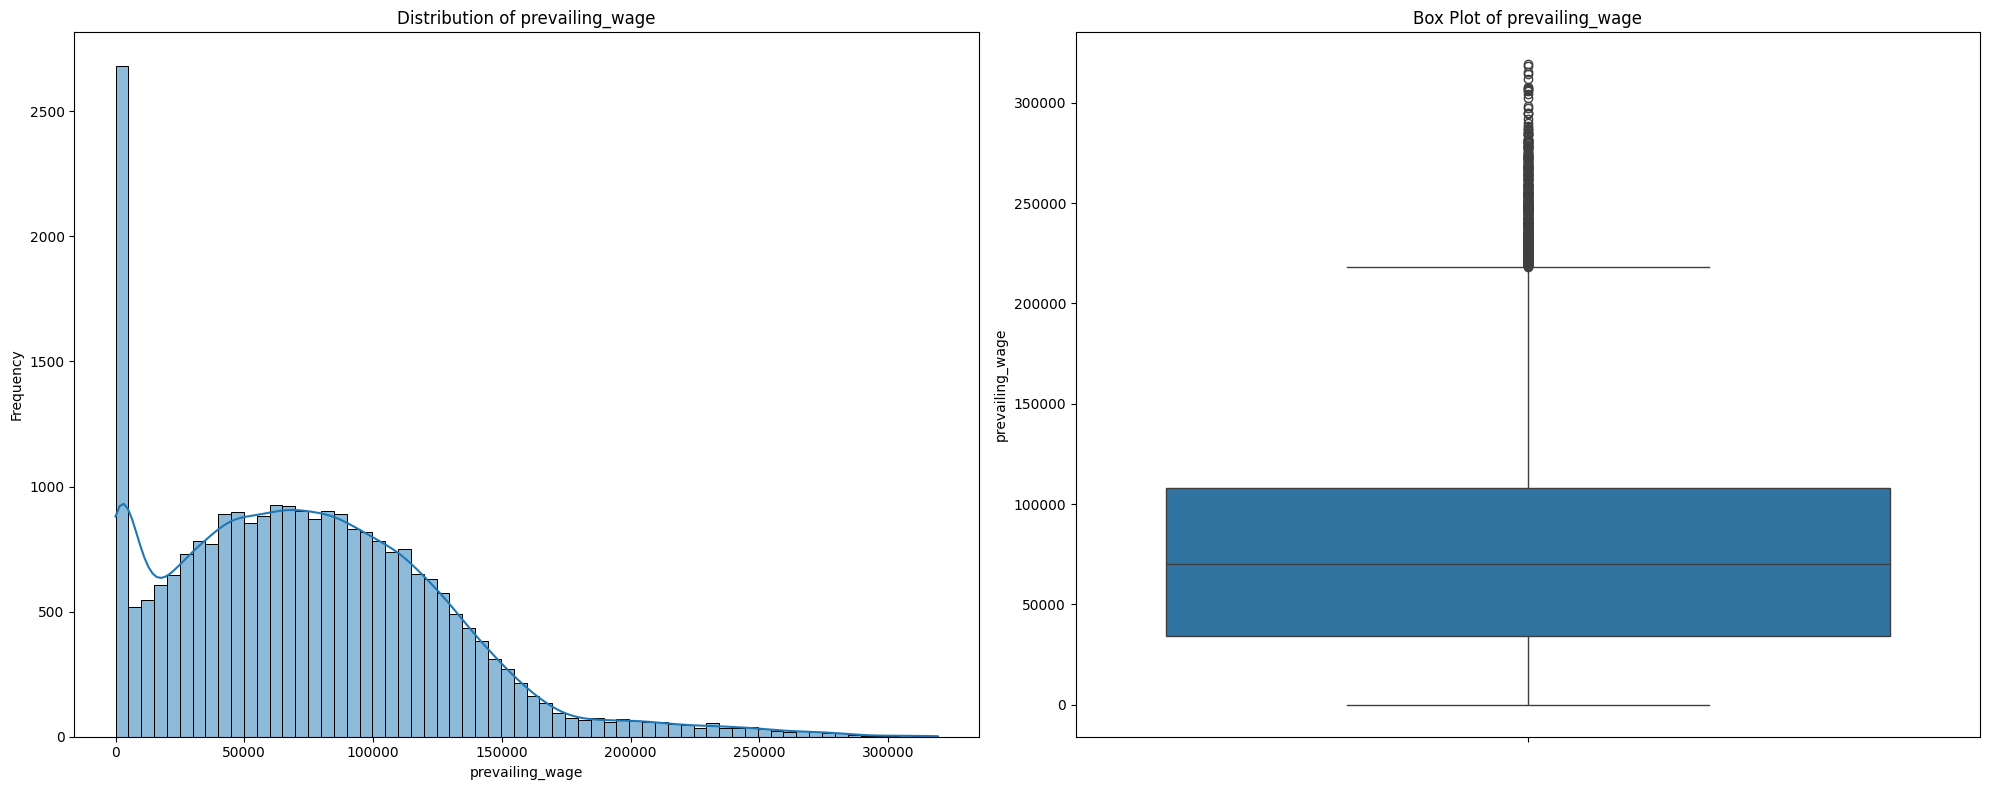

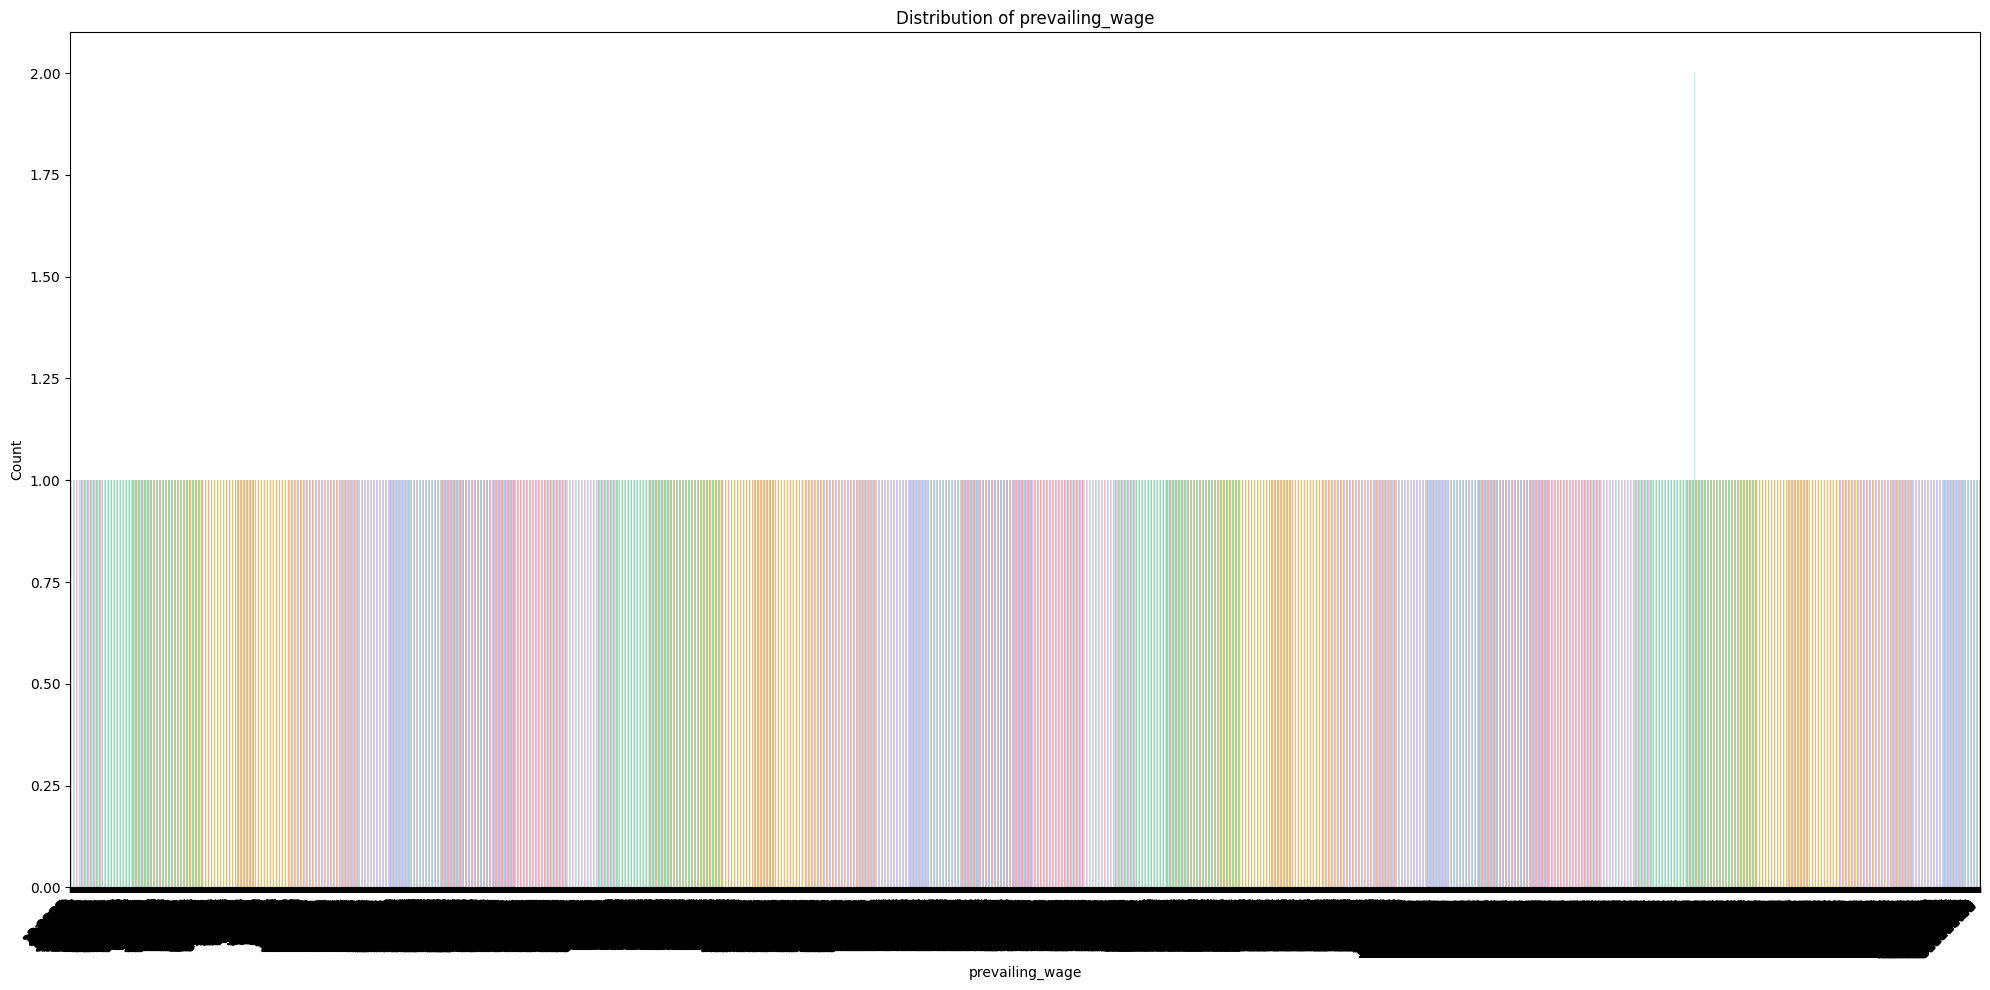

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

numerical_cols = ['no_of_employees',  'yr_of_estab', 'prevailing_wage']

def numerical_univariate_analysis(df, column):
    print(f"\nDescriptive statistics for {column}:")
    print(df[column].describe())

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

     # Create a bar plot
    plt.figure(figsize=(20, 10))
    sns.countplot(data=df, x=column, hue=column, palette='pastel', legend=False)
    plt.title(f'Distribution of {column
                                 }')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for col in numerical_cols:
    numerical_univariate_analysis(df, col)


**Inference From Univariate Analysis For Numerical Columns**

### Inferences From Univariate Analysis For Numerical Columns

*   **`no_of_employees`**: The number of employees varies greatly, ranging from -26 to 602,069, with a mean of approximately 5,667. The negative minimum value suggests a potential data entry error or a specific encoding that needs to be investigated; the large maximum value indicates the presence of outliers or very large companies in the dataset.

*   **`yr_of_estab`**: The year of establishment for employers ranges from 1800 to 2016, with a mean of around 1979. This indicates a mix of very old and relatively new companies applying for visas.

*   **`prevailing_wage`**: The prevailing wage has a wide range, from a minimum of 2.137 to a maximum of 319,210.270, with a mean of approximately 74,455. The large standard deviation (52,815) suggests a broad distribution of wages, likely influenced by different professions and regions.

**Univariate Analysis of Categorical Columns**

 1.Define a list of these columns.

2.Iterate through this list, displaying value counts

3.Generate a bar plot for each column to visualize its frequency distribution.





--- Analyzing Categorical Column: continent ---
Value Counts for continent:
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64


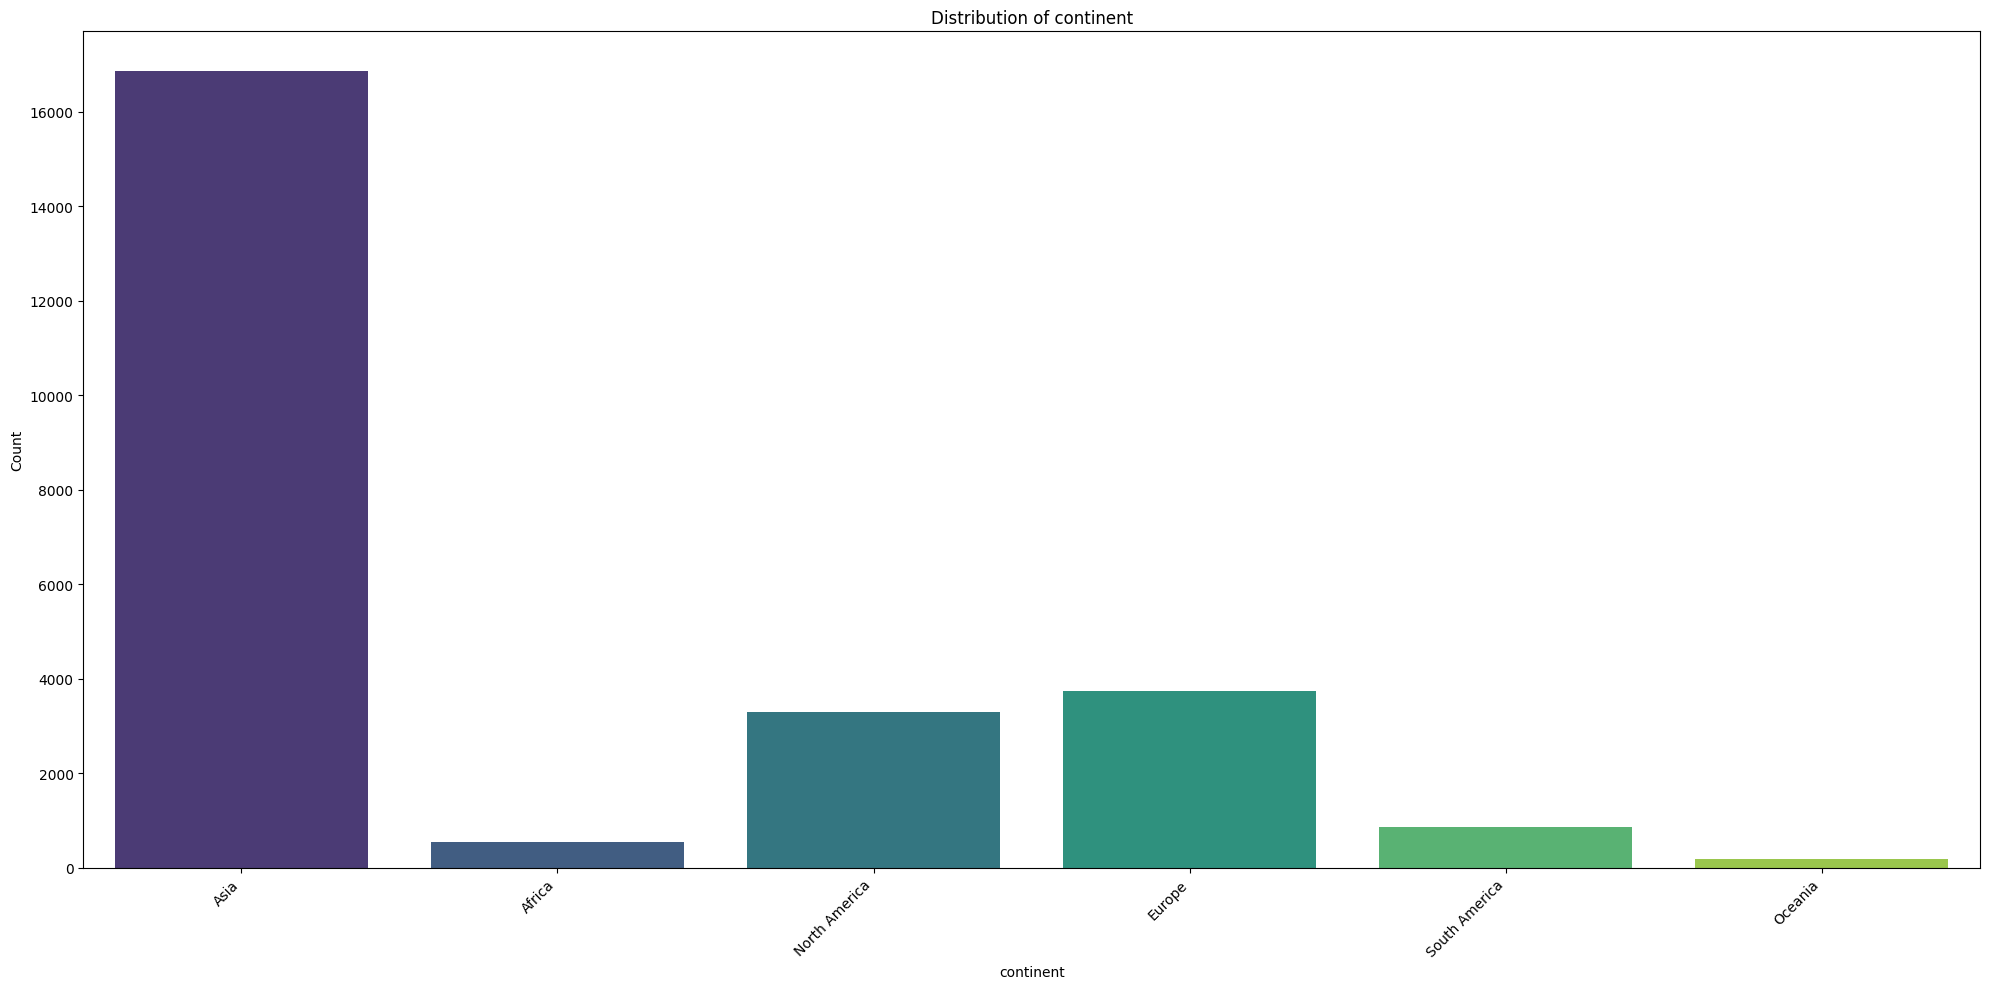


--- Analyzing Categorical Column: education_of_employee ---
Value Counts for education_of_employee:
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64


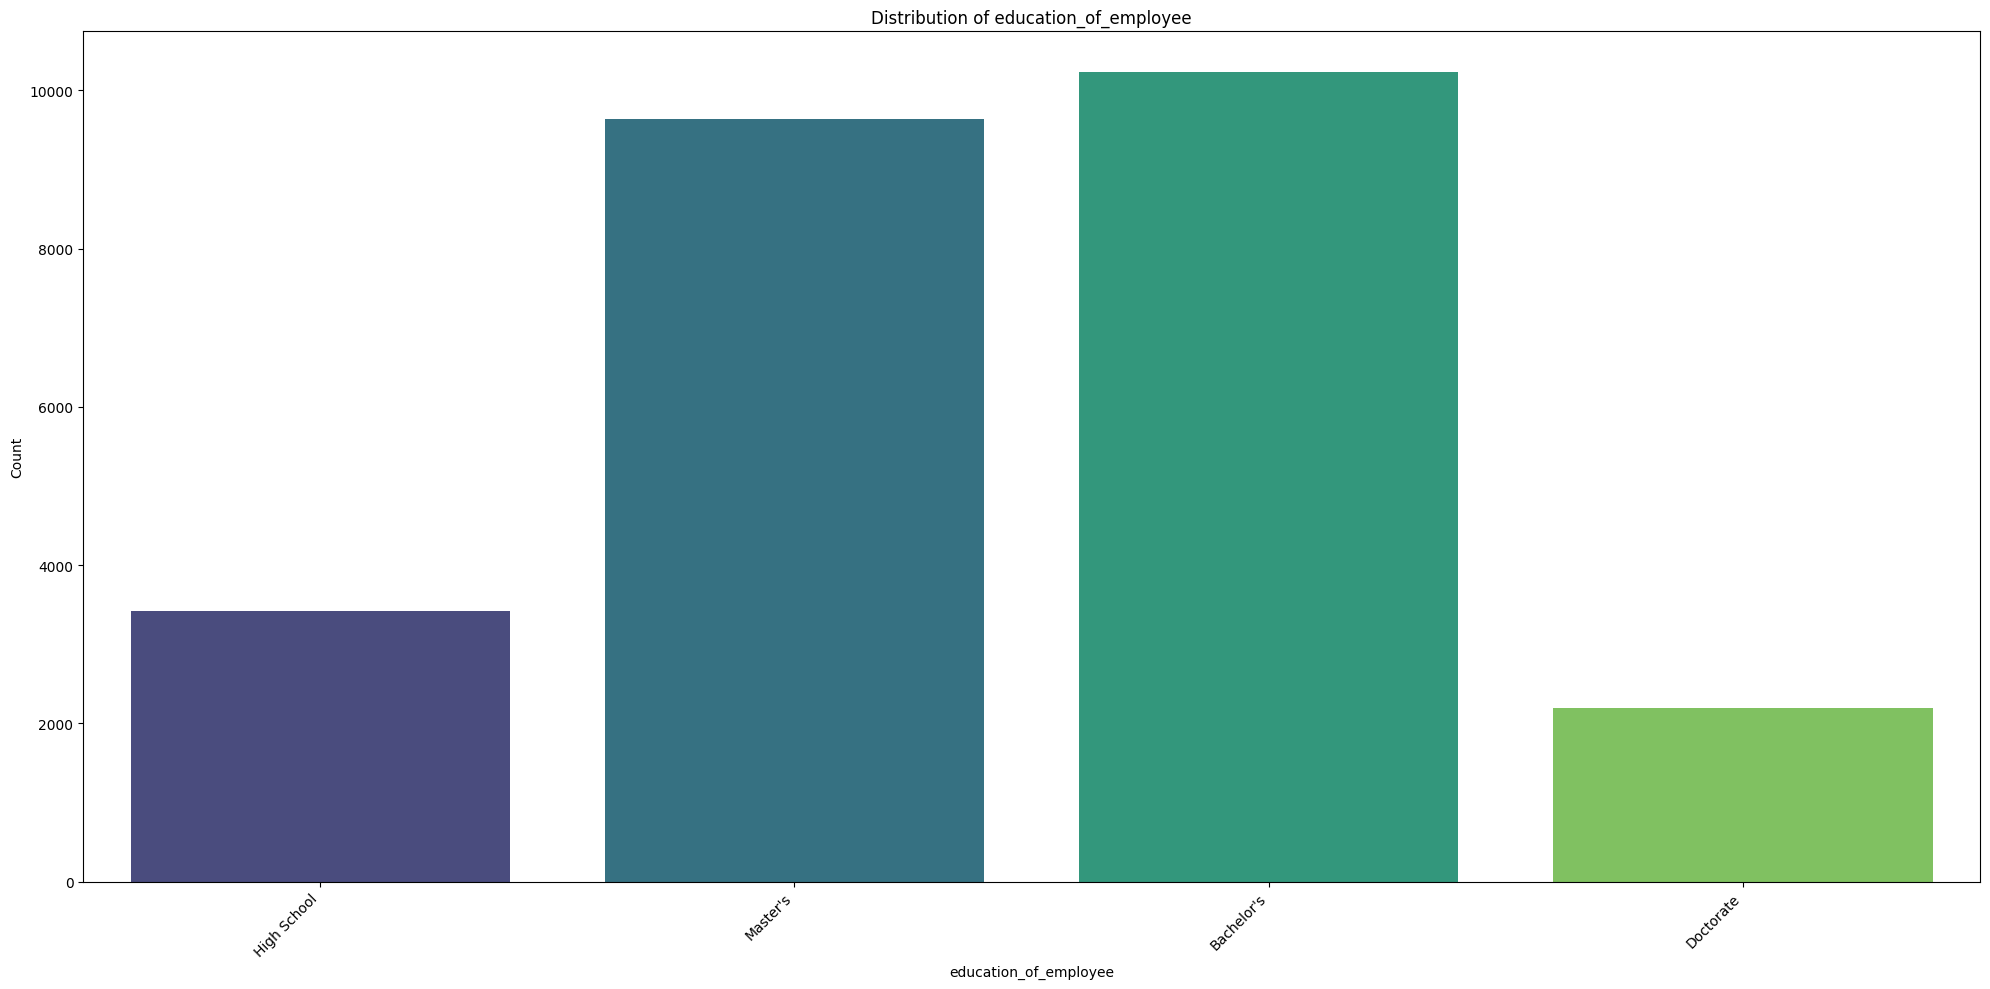


--- Analyzing Categorical Column: has_job_experience ---
Value Counts for has_job_experience:
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64


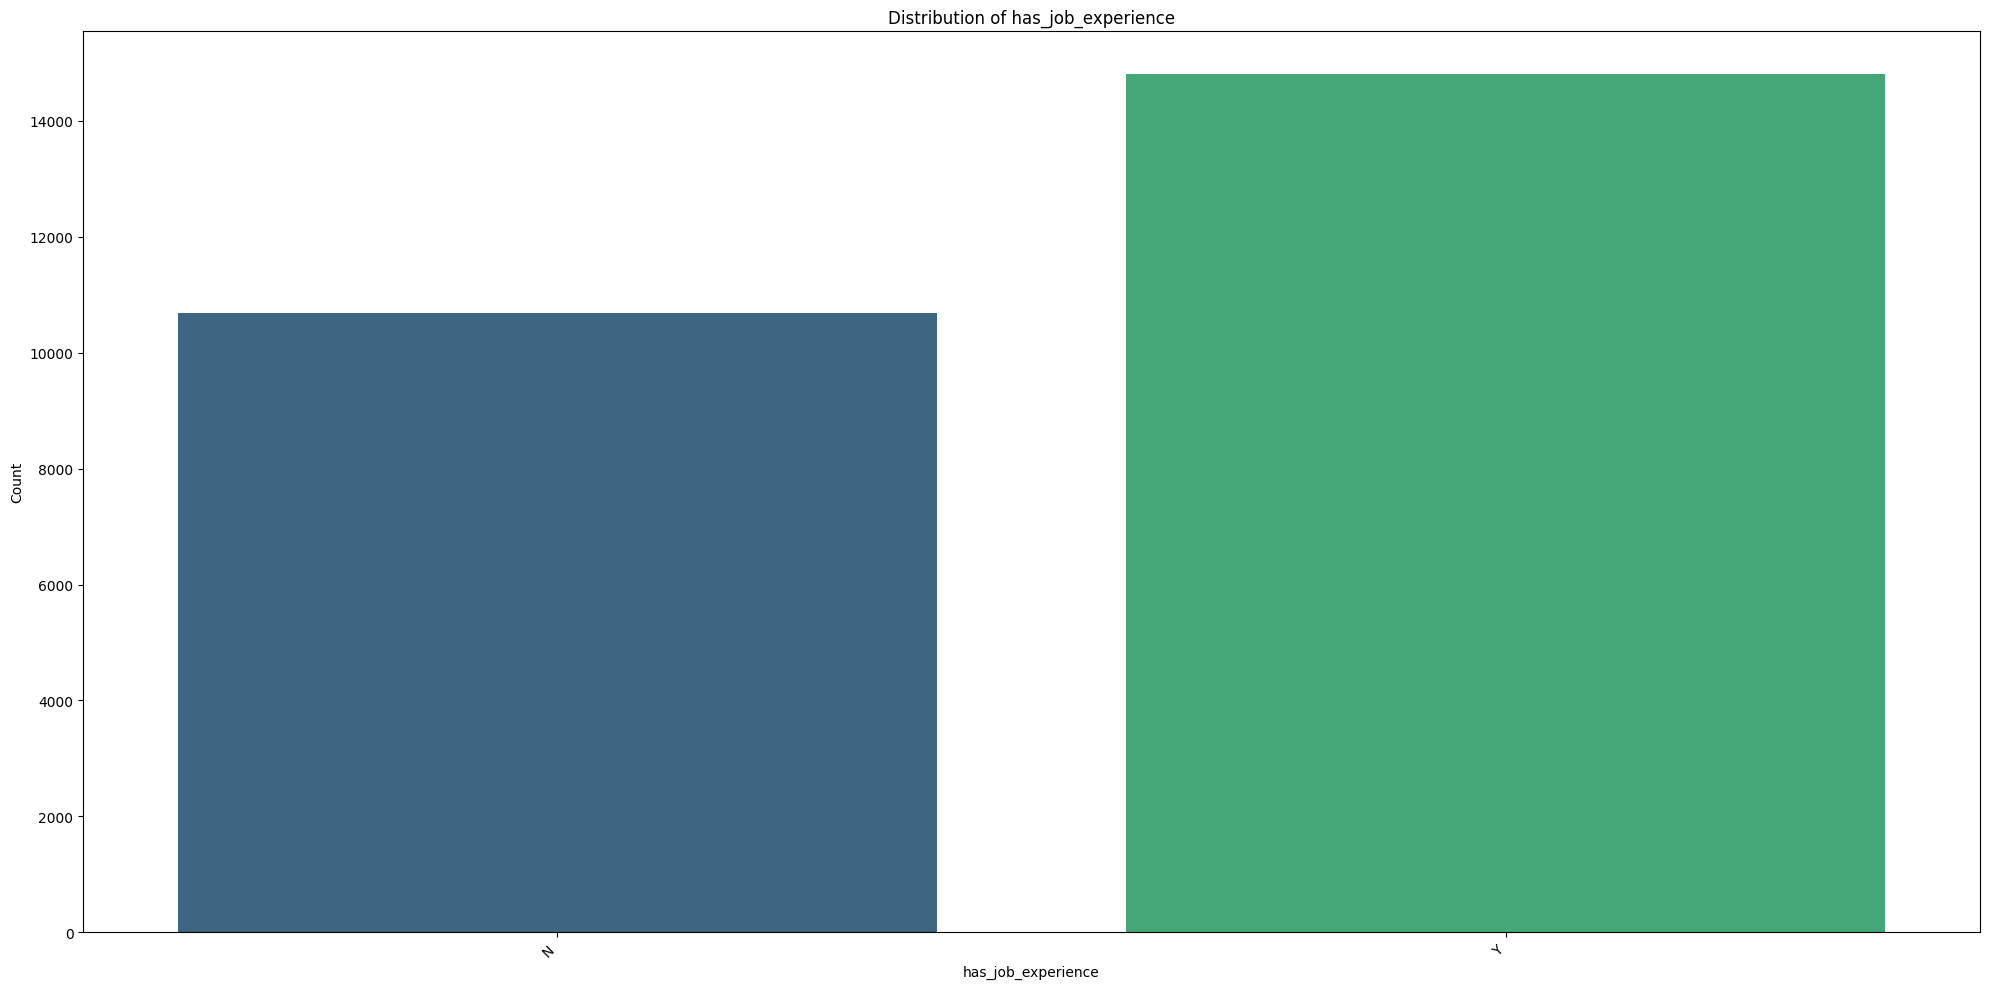


--- Analyzing Categorical Column: requires_job_training ---
Value Counts for requires_job_training:
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64


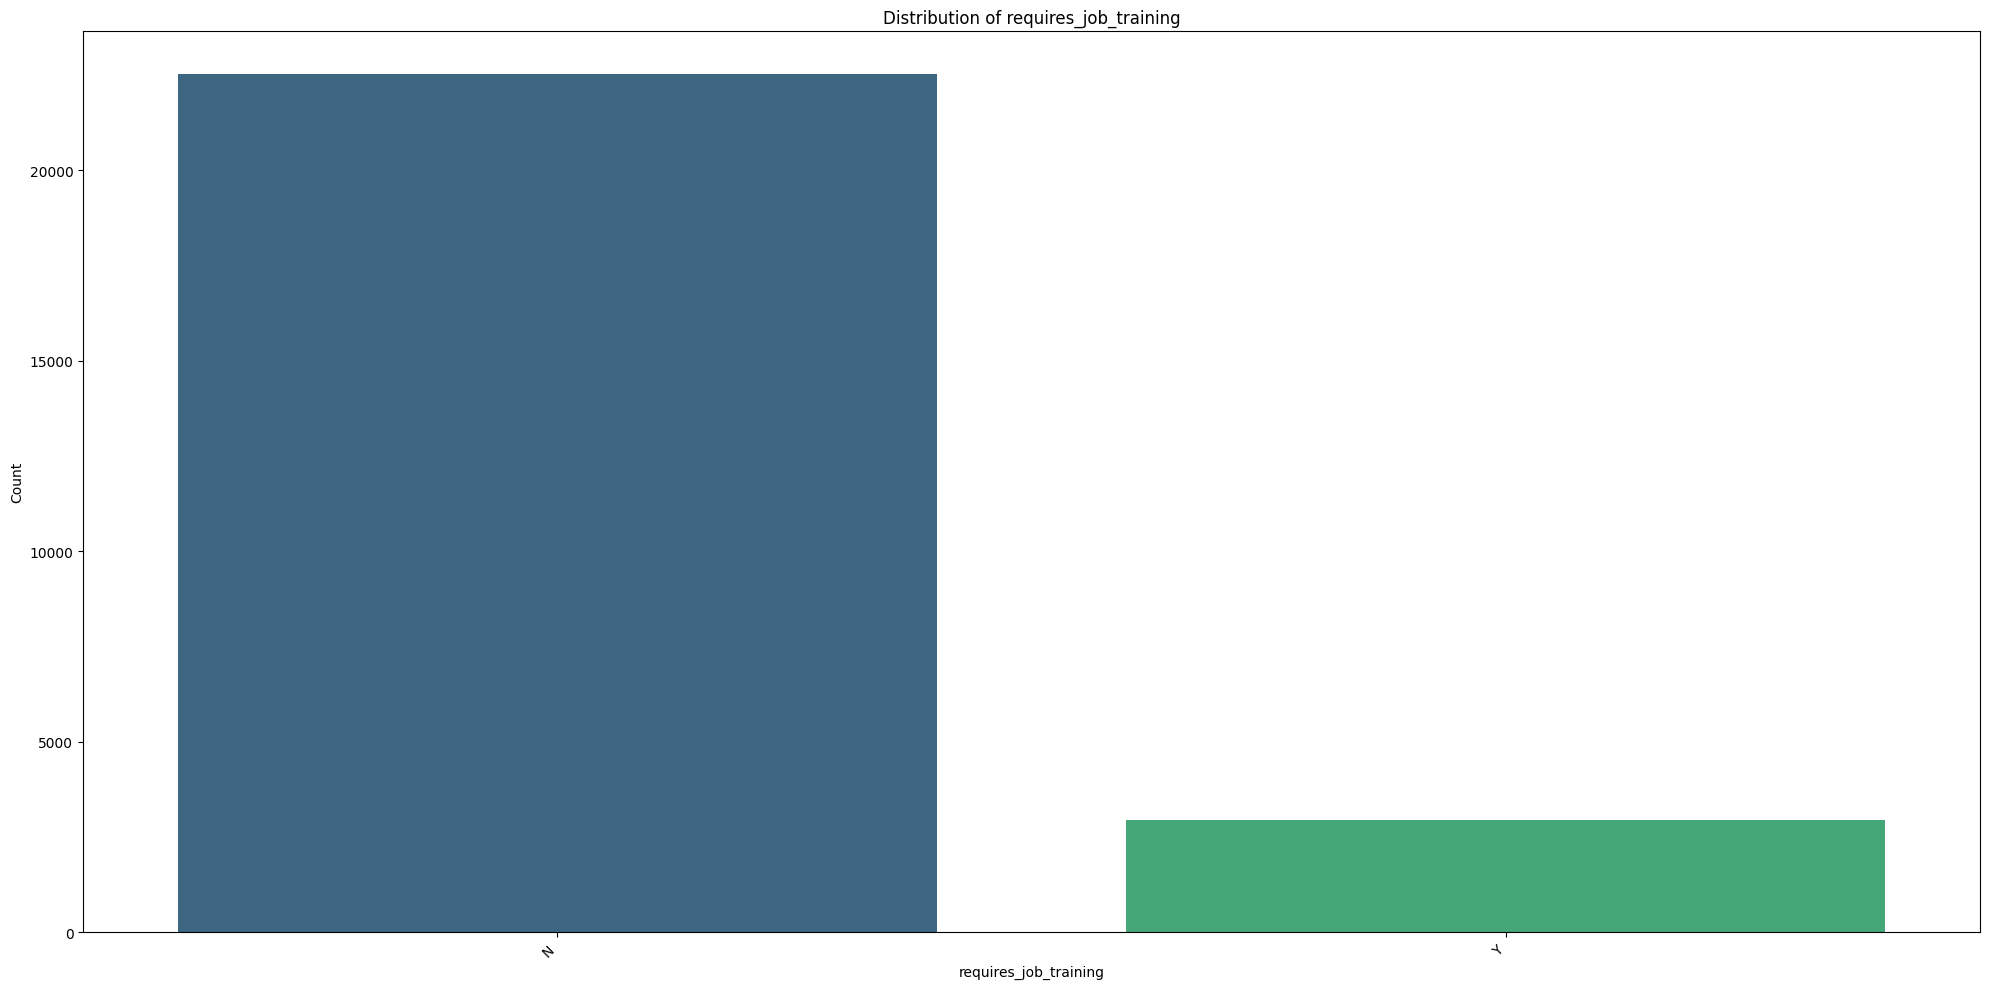


--- Analyzing Categorical Column: region_of_employment ---
Value Counts for region_of_employment:
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64


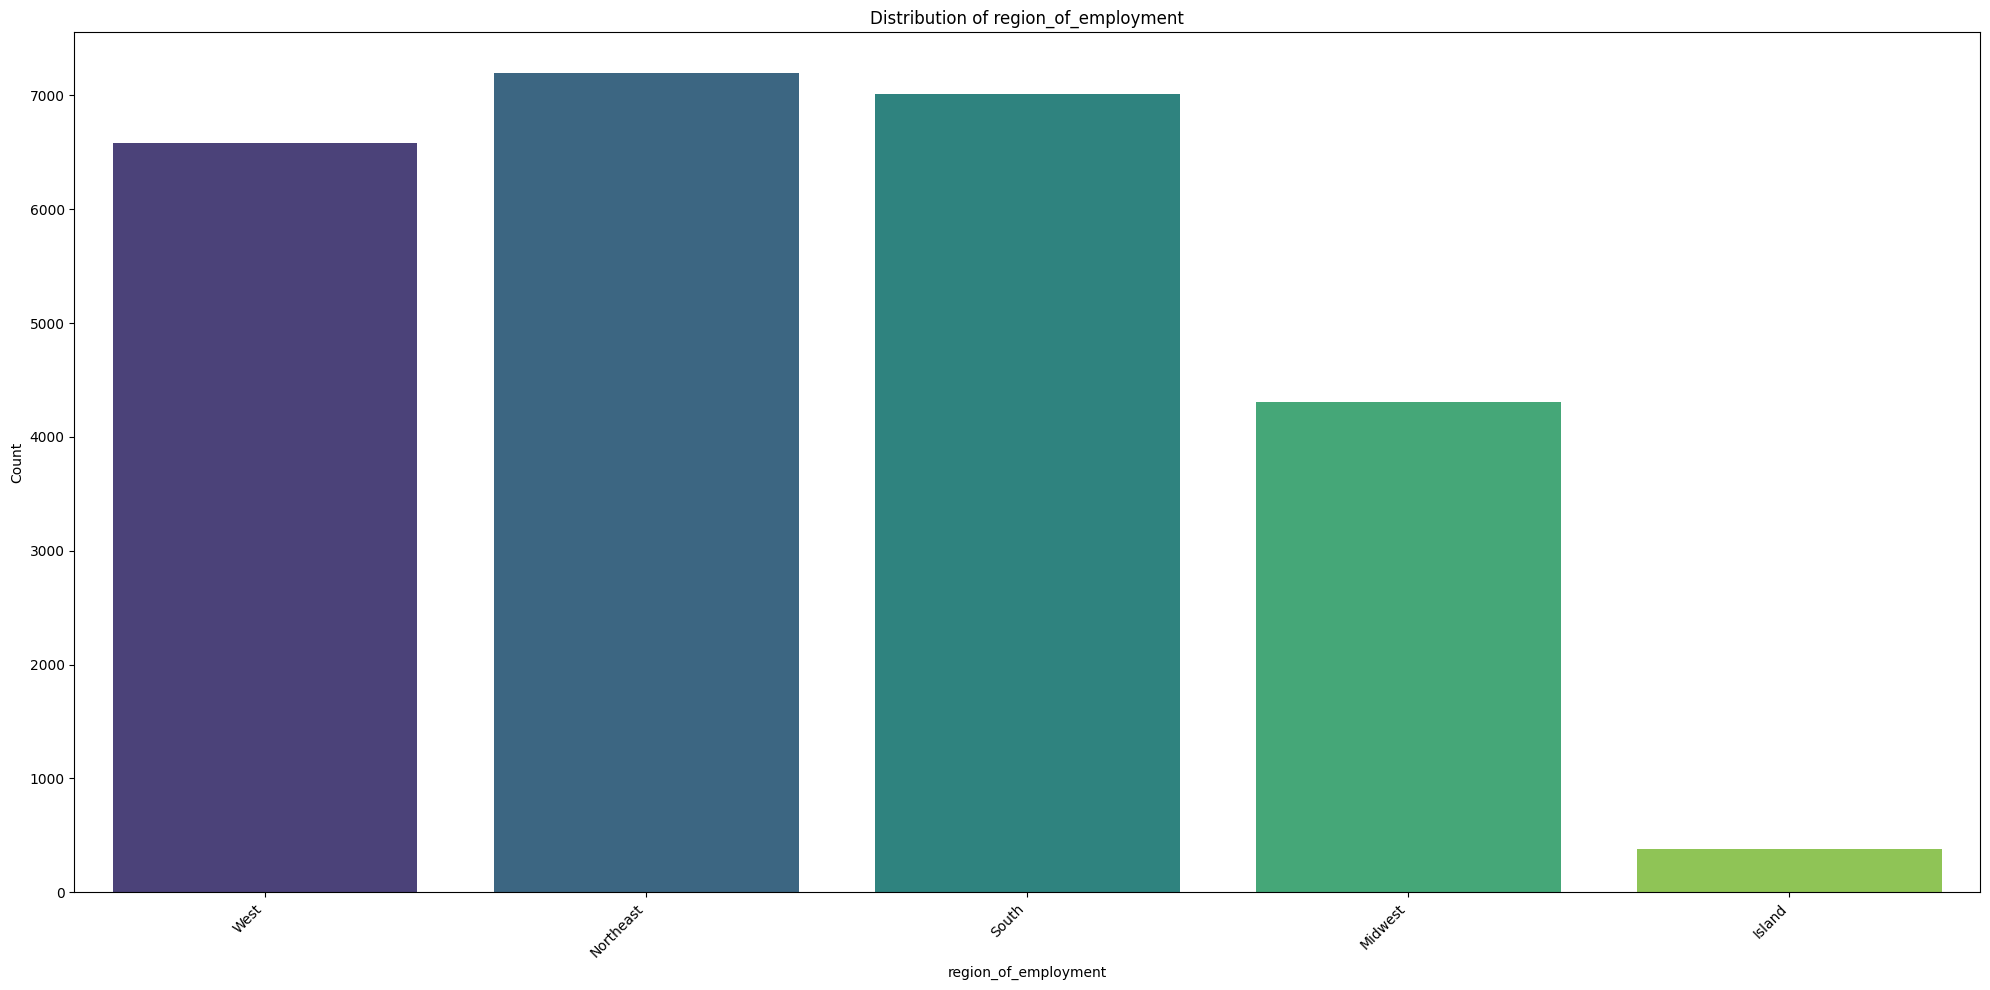


--- Analyzing Categorical Column: unit_of_wage ---
Value Counts for unit_of_wage:
unit_of_wage
Year     22962
Hour      2157
Week       272
Month       89
Name: count, dtype: int64


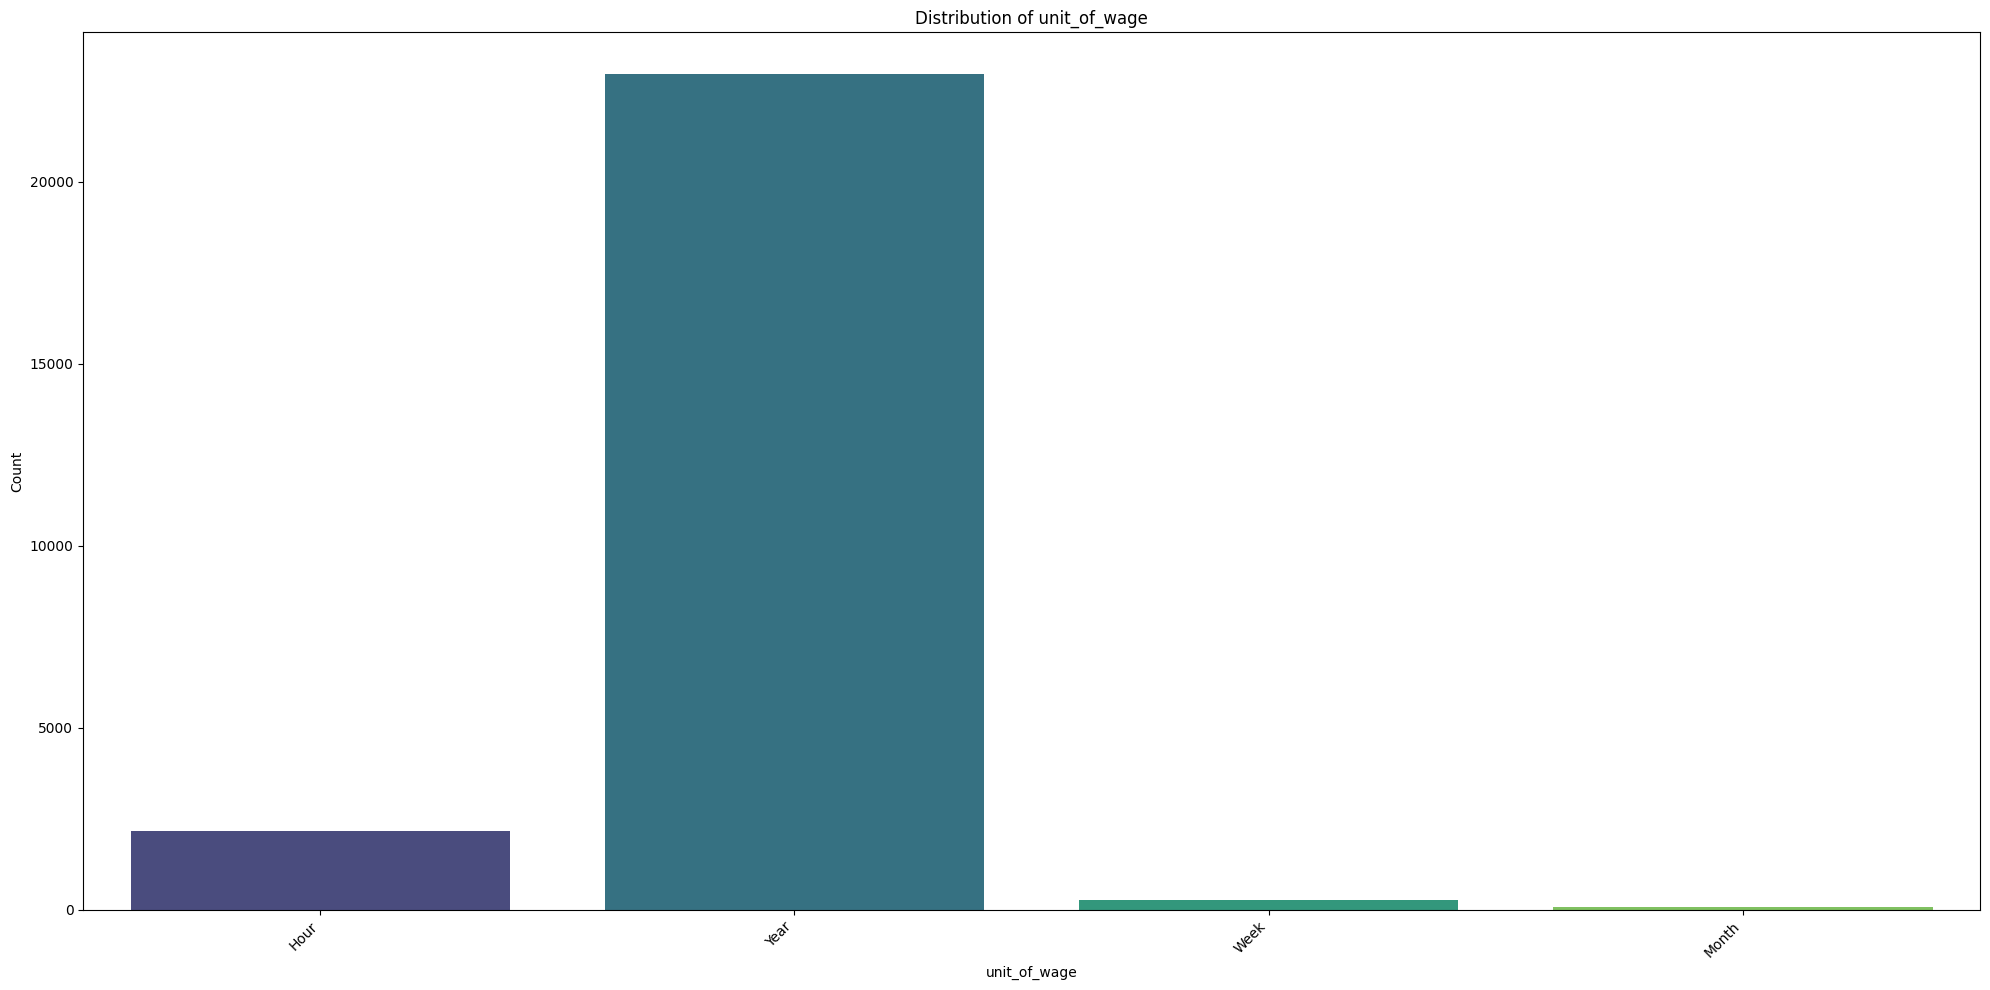


--- Analyzing Categorical Column: full_time_position ---
Value Counts for full_time_position:
full_time_position
Y    22773
N     2707
Name: count, dtype: int64


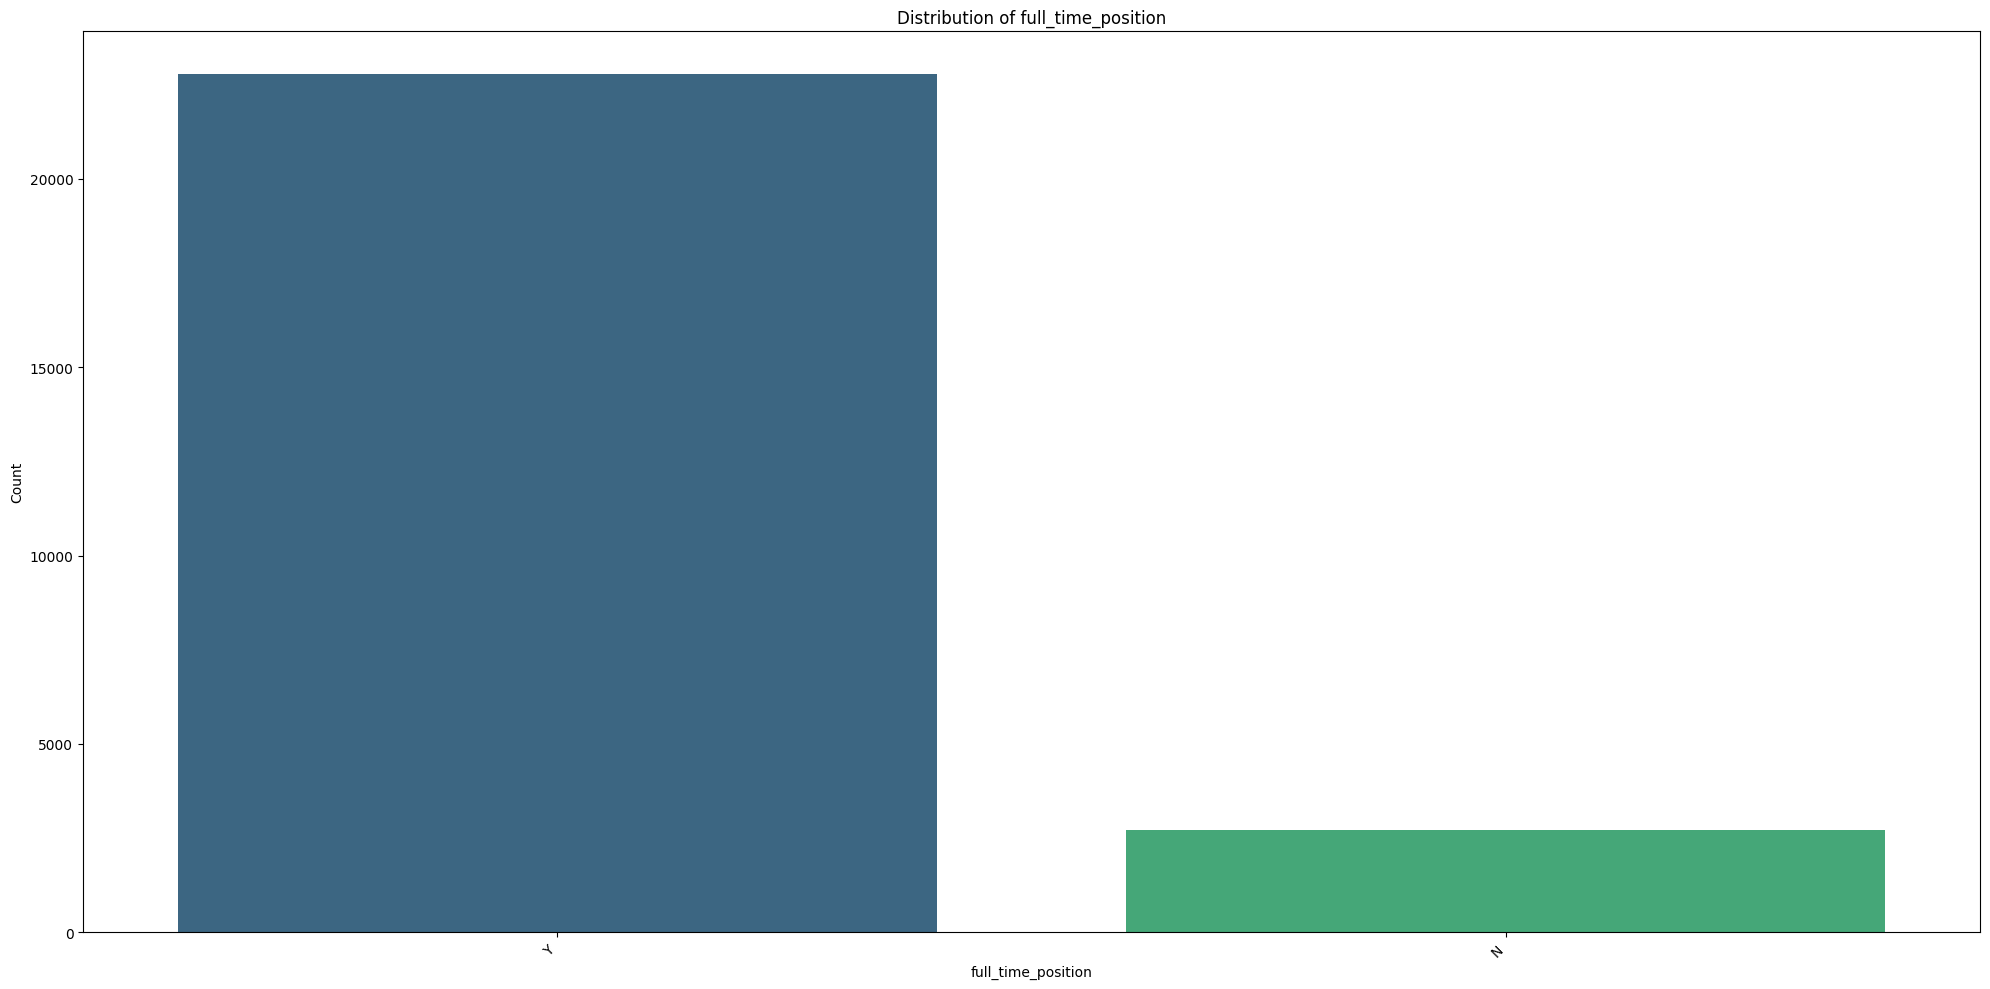


--- Analyzing Categorical Column: case_status ---
Value Counts for case_status:
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64


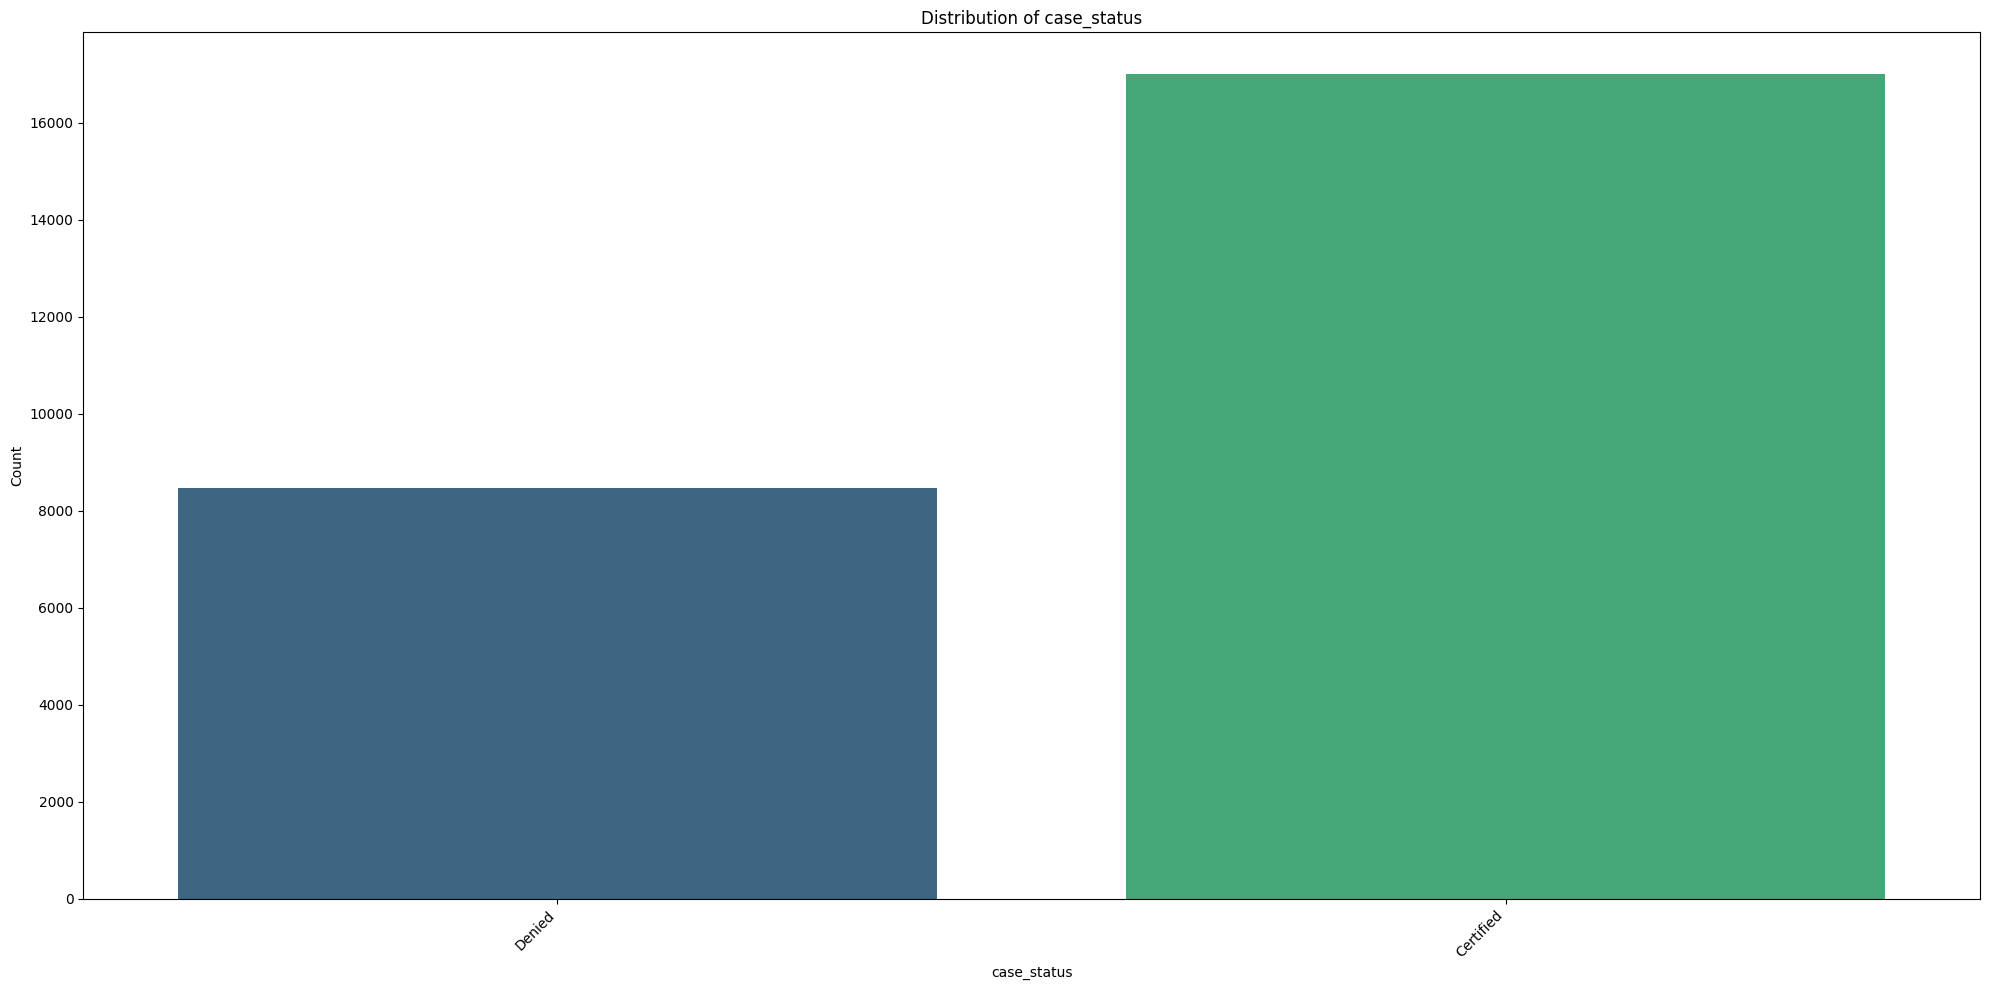

In [ ]:
categorical_cols = ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status'  ]
for col in categorical_cols:
    print(f"\n--- Analyzing Categorical Column: {col} ---")

    # Display value counts
    print(f"Value Counts for {col}:")
    print(df[col].value_counts())

    # Create a bar plot
    plt.figure(figsize=(20, 10))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Inference From Univariate Analysis For Categorical Columns**

### Inferences From Univariate Analysis For Categorical Columns

*   **`continent`**: The majority of visa applicants originate from Asia (**66.17%**), significantly outnumbering those from other continents, indicating a strong influx of talent from this region. Europe (**14.65%**) and North America (**12.92%**) follow as the next largest sources of applicants, while Oceania (**0.75%**) has the fewest applicants.

*   **`education_of_employee`**: A large proportion of employees applying for visas hold Bachelor's (**40.16%**) or Master's (**37.81%**) degrees, suggesting a preference for highly educated individuals. High School educated applicants (**13.42%**) are the least represented among those with formal education, followed by Doctorates (**8.60%**).

*   **`has_job_experience`**: More than half of the visa applicants (**58.09%**) possess prior job experience, indicating that employers often seek experienced professionals. However, a substantial number of applicants (**41.91%**) also lack job experience.

*   **`requires_job_training`**: The vast majority of applicants (**88.40%**) do not require job training, which suggests that employers are primarily looking for individuals who are ready to work immediately. Only a small fraction of applicants (**11.60%**) require training.

*   **`region_of_employment`**: The Northeast (**28.24%**), South (**27.54%**), and West (**25.85%**) regions of the US are the most popular areas for employment among foreign workers, indicating significant demand in these areas. The Midwest (**16.90%**) and Island (**1.47%**) regions receive fewer applications.

*   **`unit_of_wage`**: The prevailing wage is predominantly reported on a yearly basis (**90.12%**), reflecting that most positions are salaried roles. Hourly wages (**8.47%**) are the next most common, while weekly (**1.07%**) and monthly (**0.35%**) wage units are infrequent.

*   **`full_time_position`**: The overwhelming majority of visa applications are for full-time positions (**89.38%**), indicating a strong preference from employers for permanent and dedicated roles. Part-time positions (**10.62%**) are significantly less common.

*   **`case_status`**: More visa applications are certified (**66.79%**) than denied (**33.21%**), suggesting that a majority of applicants successfully meet the criteria for approval. However, a considerable number of applications are still denied.

**Bivariate Analysis**

**Bivariate Analysis - Correlation Heatmap Analysis for Numerical Columns**

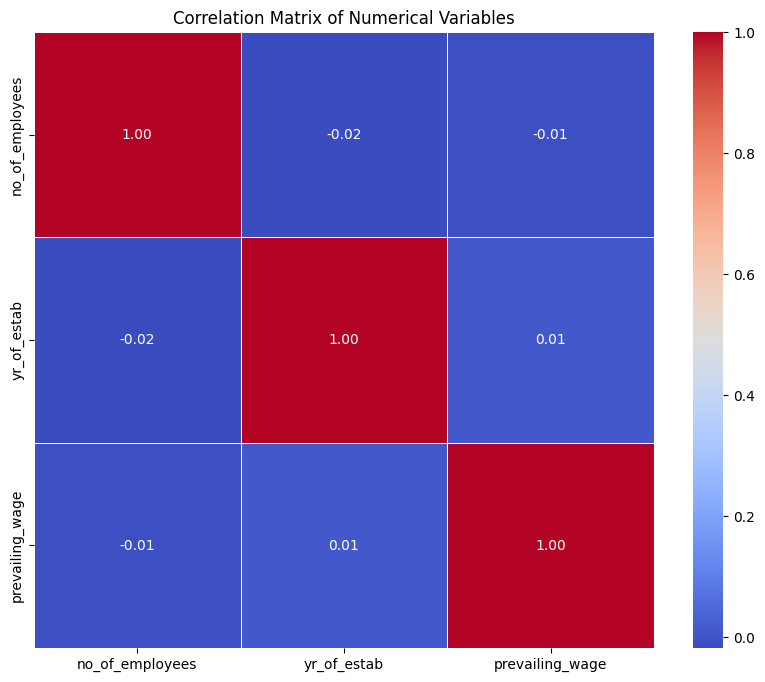

In [ ]:
numerical_cols_for_corr = ['no_of_employees',  'yr_of_estab', 'prevailing_wage']


# Calculate the correlation matrix
correlation_matrix = df[numerical_cols_for_corr].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [ ]:
correlation_matrix


,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000,-0.018,-0.010
yr_of_estab,-0.018,1.000,0.012
prevailing_wage,-0.010,0.012,1.000


**Bivariate Analysis from Correlation Matrix**

 Inferences based on the correlation matrix:

**no_of_employees and yr_of_estab:** There is a very weak negative linear correlation (-0.018) between the number of employees and the year of establishment, suggesting that these two variables are largely independent of each other.

**no_of_employees and prevailing_wage:**
 A very weak negative linear correlation (-0.010) indicates that the number of employees in a company has almost no linear relationship with the prevailing wage.

**yr_of_estab and prevailing_wage:**

There is a negligible positive linear correlation (0.012) between the year of establishment and the prevailing wage, implying no significant linear association.


**BiVaraite Analysis:**

**Numerical Vs case_status**

Target Variable : case_status

Count Plot Analysis

Numerical Vs Categorical Target Variable

Box Plot Analysis

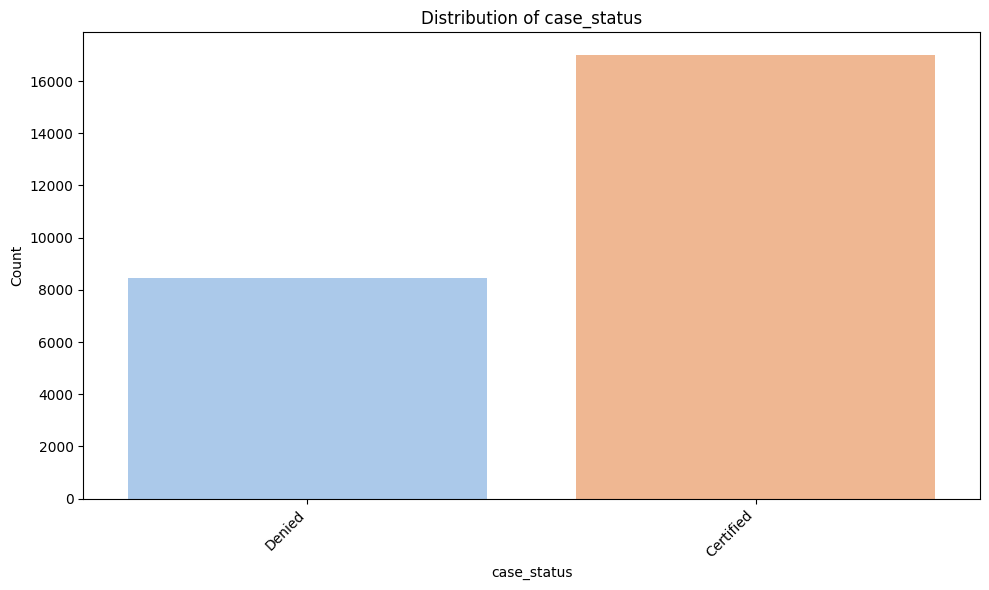

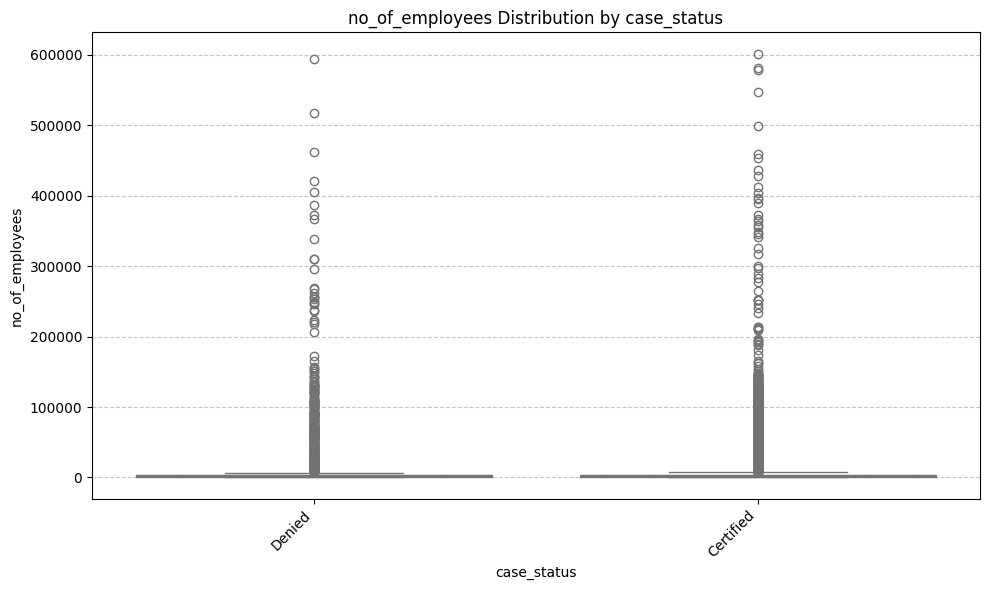

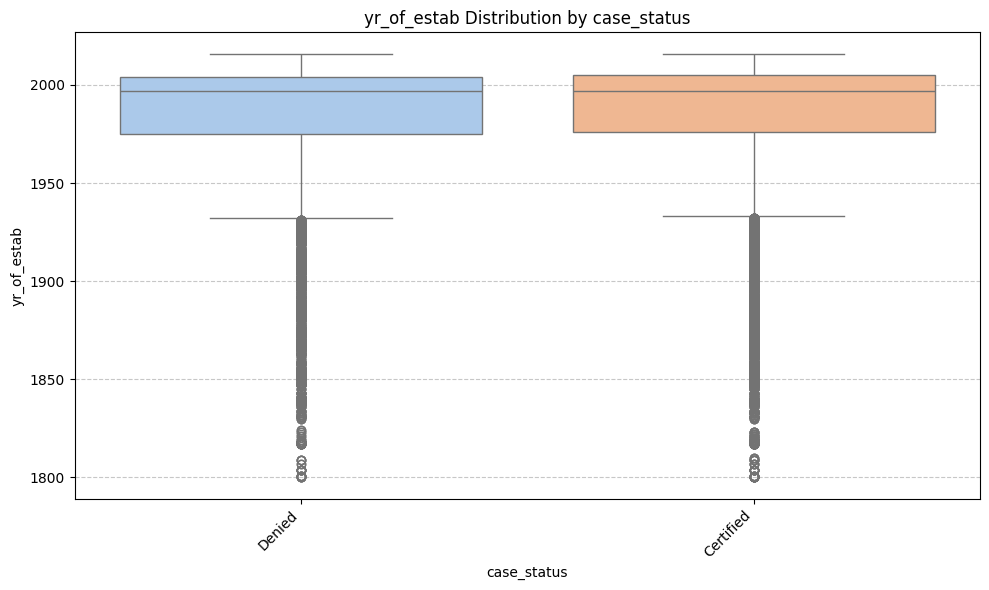

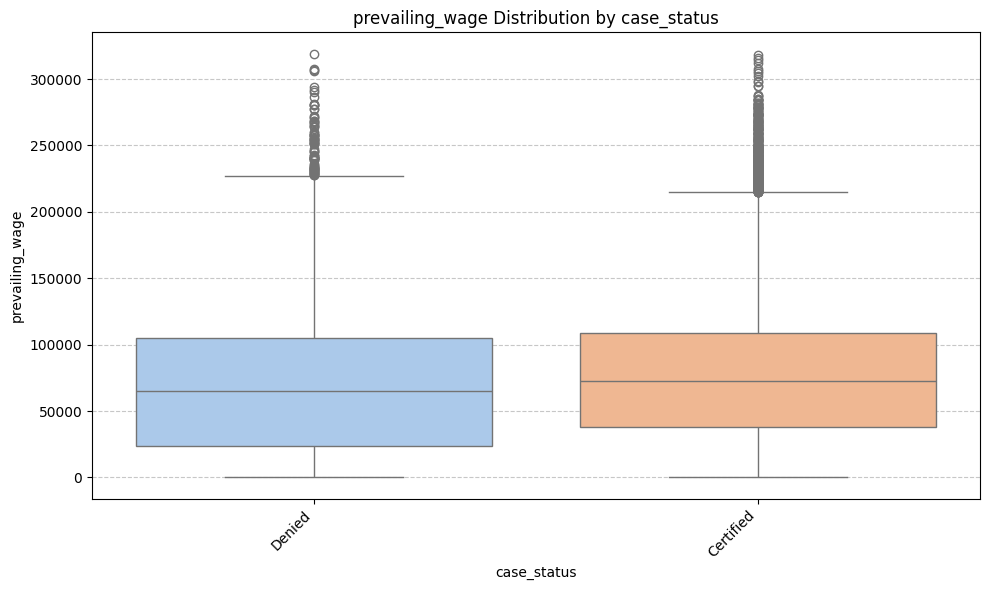

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cat_col = 'case_status'
cols_to_plot = [col for col in df.select_dtypes(include=np.number).columns.tolist() if col != cat_col]

# Plot 1: Count Plot for the categorical variable itself
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=cat_col, hue=cat_col, palette='pastel', legend=False)
plt.title(f'Distribution of {cat_col}')
plt.xlabel(cat_col)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Box Plot for each numerical variable vs. the categorical variable
for num_col in cols_to_plot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=cat_col, y=num_col, hue=cat_col, palette='pastel', legend=False)
    plt.title(f'{num_col} Distribution by {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

**Inferences from Bivariate Analysis (Numerical vs. Case Status)**

### Inferences from Bivariate Analysis (Numerical vs. Case Status)

Based on the box plots comparing numerical features with `case_status`:

*   **`no_of_employees` vs. `case_status`:** The distribution of `no_of_employees` shows similar median values for both 'Certified' and 'Denied' cases. However, applications from companies with a higher number of employees tend to have a greater likelihood of being 'Certified', as indicated by the wider spread and higher maximum values in the 'Certified' category.

*   **`yr_of_estab` vs. `case_status`:** There appears to be very little difference in the `yr_of_estab` distributions between 'Certified' and 'Denied' cases. The box plots for both categories are largely overlapping, suggesting that the year a company was established does not significantly influence the visa `case_status`.

*   **`prevailing_wage` vs. `case_status`:** The `prevailing_wage` distributions differ considerably between the two `case_status` categories. 'Certified' applications generally show a higher median prevailing wage compared to 'Denied' applications. This suggests that applications with higher proposed wages are more frequently certified.

**Bivariate Analysis for Categorical Vs case_status**

Categorical columns:

['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status'  ]

    Versus

case_status



--- Bivariate Analysis: case_status vs other Categorical Columns ---


<Figure size 1200x700 with 0 Axes>

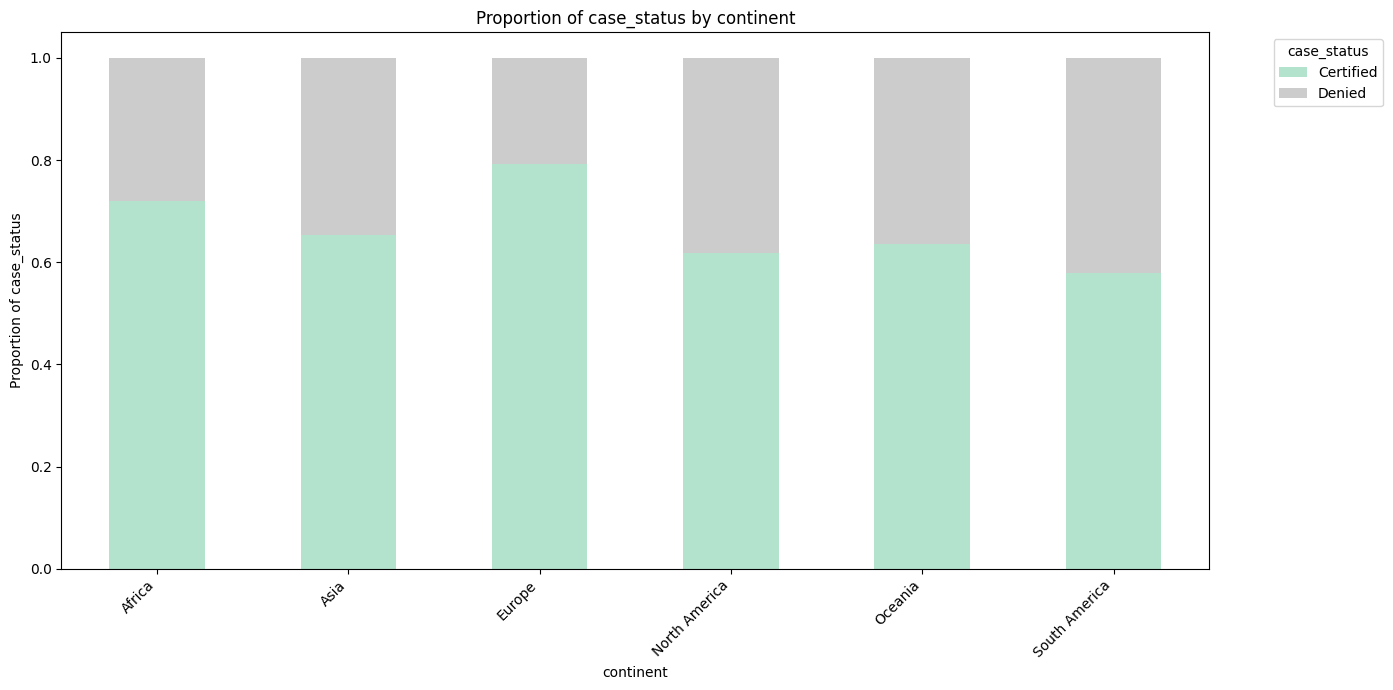


Cross-tabulation for case_status by continent:


case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Figure size 1200x700 with 0 Axes>

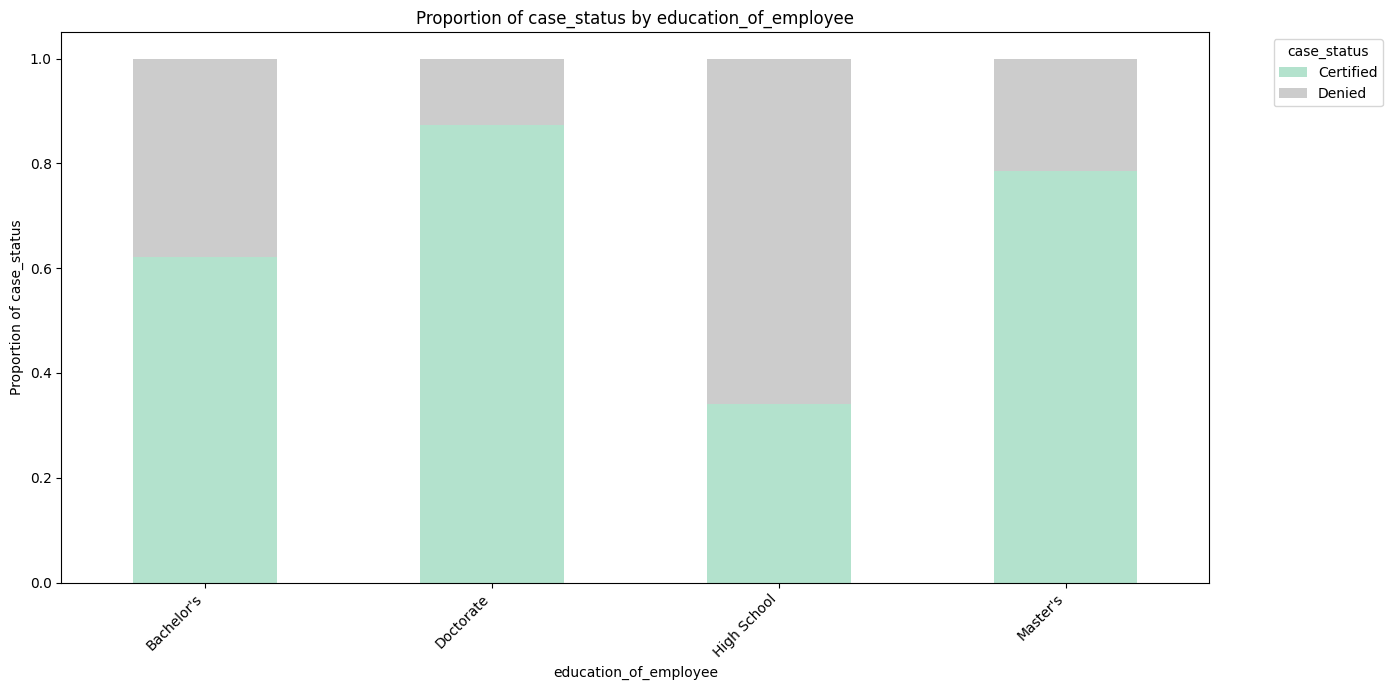


Cross-tabulation for case_status by education_of_employee:


case_status,Certified,Denied
education_of_employee,,
Bachelor's,6367,3867
Doctorate,1912,280
High School,1164,2256
Master's,7575,2059


<Figure size 1200x700 with 0 Axes>

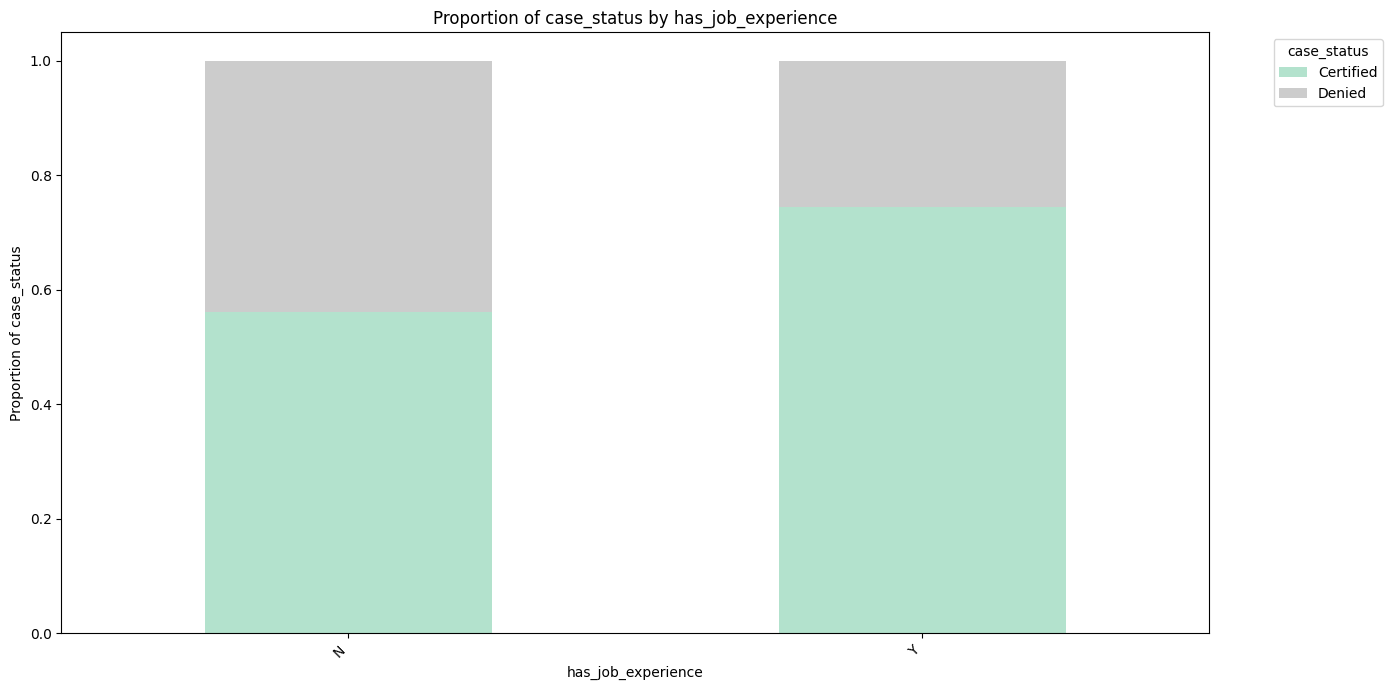


Cross-tabulation for case_status by has_job_experience:


case_status,Certified,Denied
has_job_experience,,
N,5994,4684
Y,11024,3778


<Figure size 1200x700 with 0 Axes>

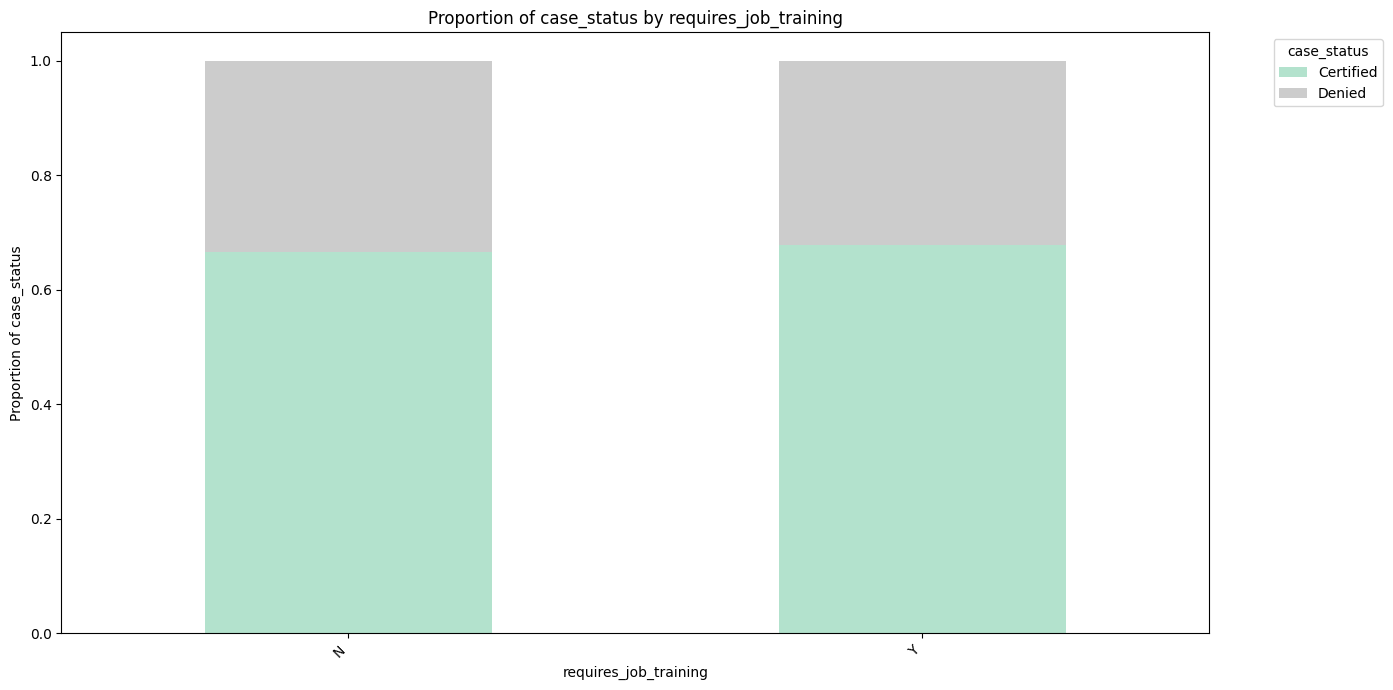


Cross-tabulation for case_status by requires_job_training:


case_status,Certified,Denied
requires_job_training,,
N,15012,7513
Y,2006,949


<Figure size 1200x700 with 0 Axes>

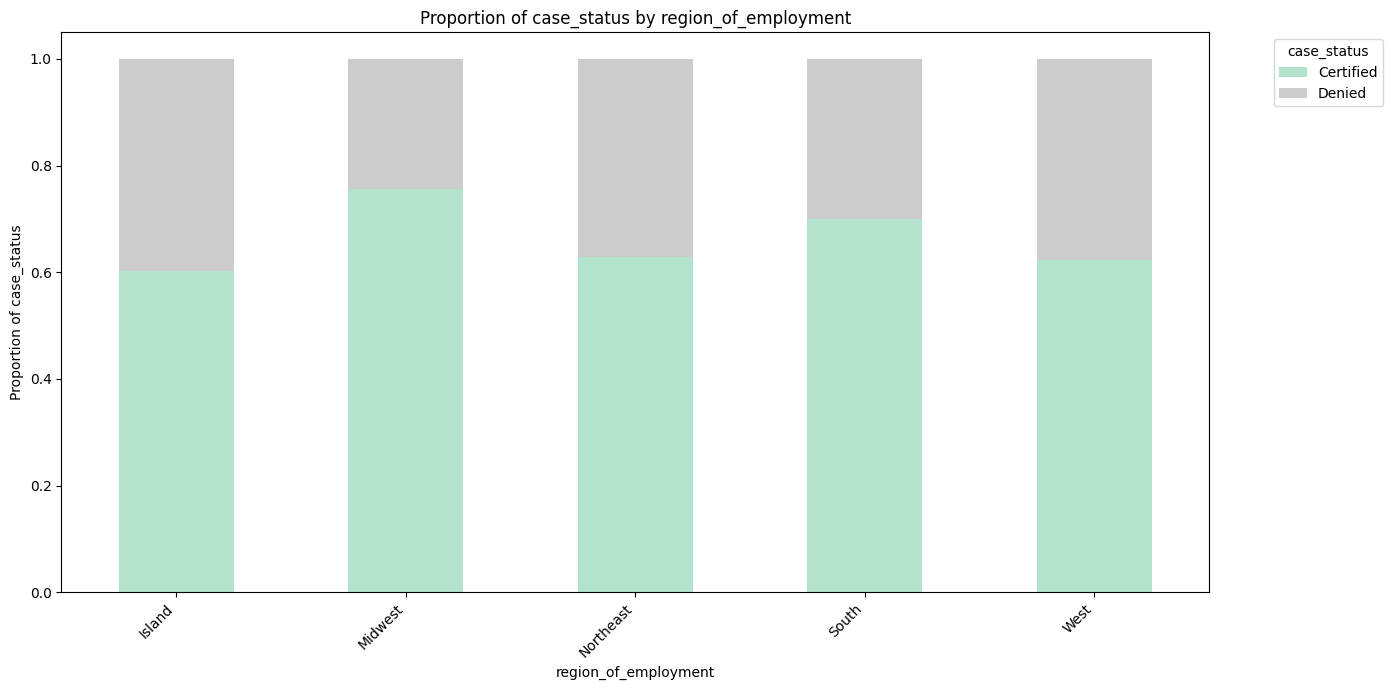


Cross-tabulation for case_status by region_of_employment:


case_status,Certified,Denied
region_of_employment,,
Island,226,149
Midwest,3253,1054
Northeast,4526,2669
South,4913,2104
West,4100,2486


<Figure size 1200x700 with 0 Axes>

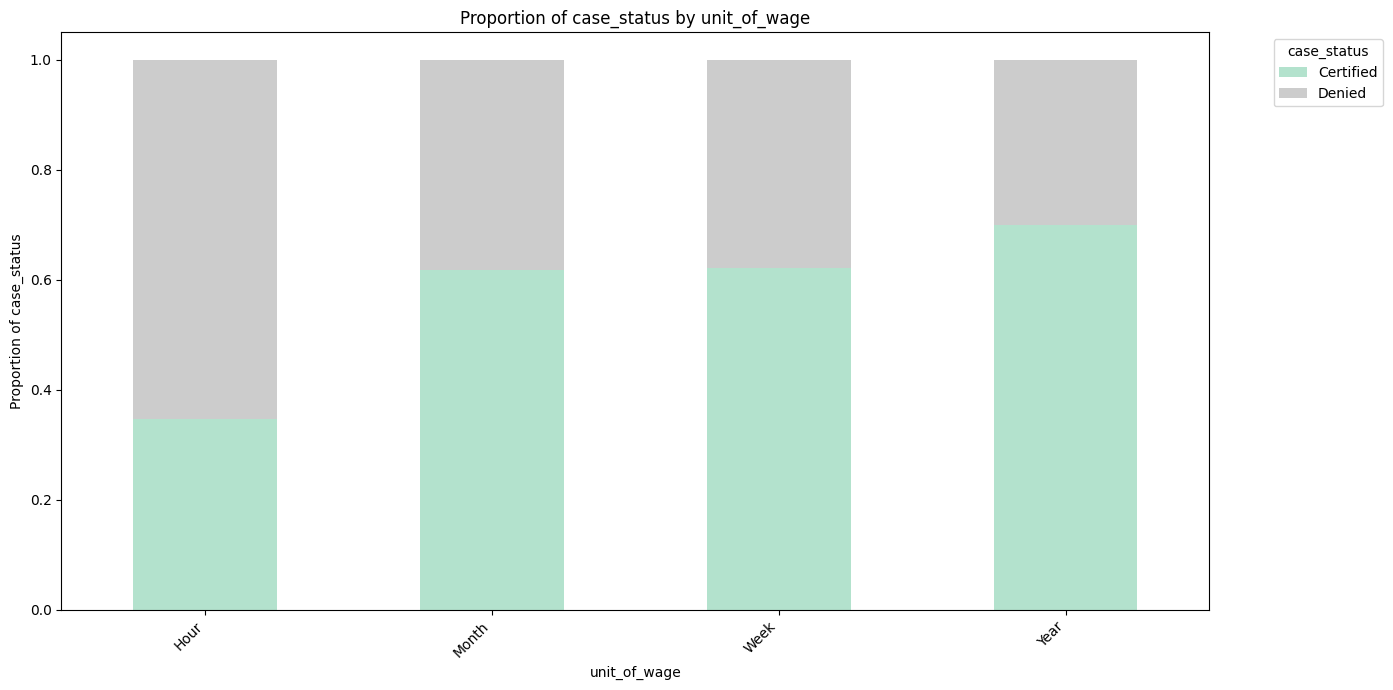


Cross-tabulation for case_status by unit_of_wage:


case_status,Certified,Denied
unit_of_wage,,
Hour,747,1410
Month,55,34
Week,169,103
Year,16047,6915


<Figure size 1200x700 with 0 Axes>

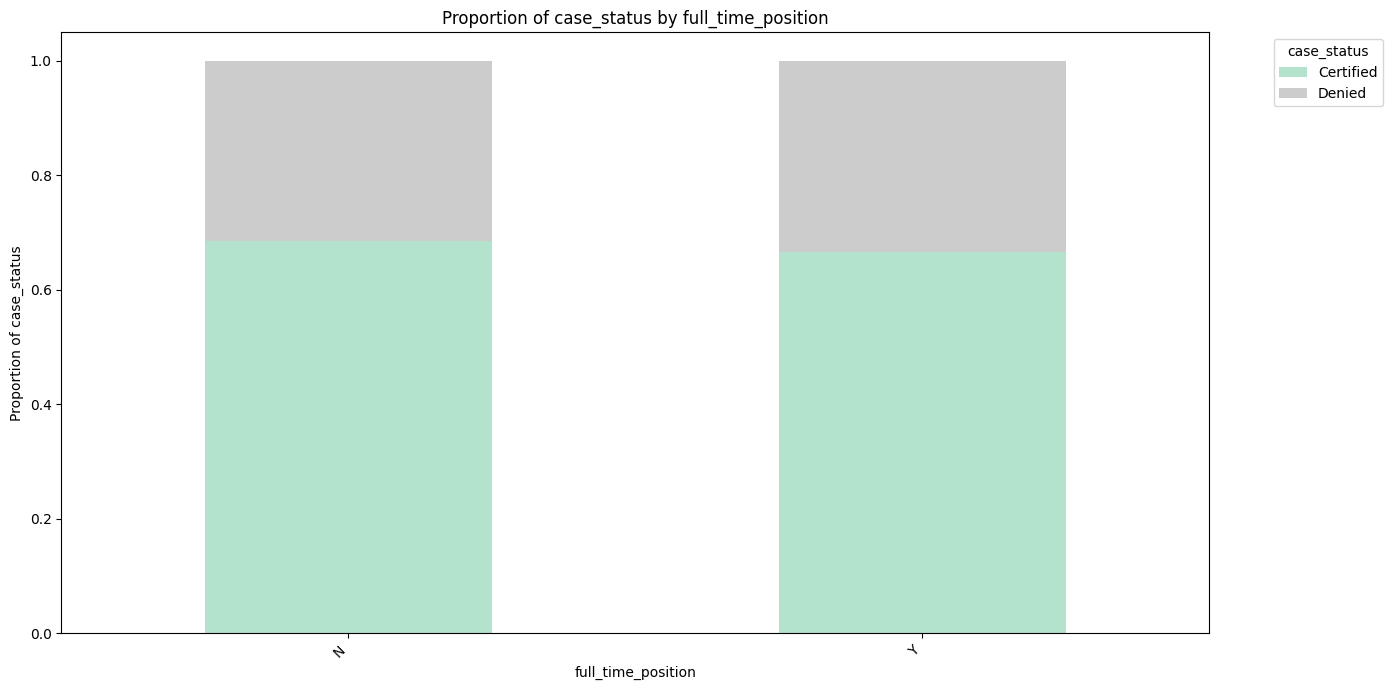


Cross-tabulation for case_status by full_time_position:


case_status,Certified,Denied
full_time_position,,
N,1855,852
Y,15163,7610


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def categorical_bivariate_analysis(df, cat_cols, target_var='case_status'):
    print(f"\n--- Bivariate Analysis: {target_var} vs other Categorical Columns ---")

    for col in cat_cols:
        if col == target_var:
            continue # Skip if the column is the target variable column itself

        # Create a cross-tabulation (contingency table)
        cross_tab = pd.crosstab(df[col], df[target_var], normalize='index') # normalize to show proportions

        # Plotting as a stacked bar chart
        plt.figure(figsize=(12, 7))
        cross_tab.plot(kind='bar', stacked=True, colormap='Pastel2', figsize=(14, 7))
        plt.title(f'Proportion of {target_var} by {col}')
        plt.xlabel(col)
        plt.ylabel(f'Proportion of {target_var}')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=target_var, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        print(f"\nCross-tabulation for {target_var} by {col}:")
        display(pd.crosstab(df[col], df[target_var]))

cat_cols_for_bivariate = ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status'  ]
categorical_bivariate_analysis(df, cat_cols_for_bivariate, target_var='case_status')

Inferences :

### Inferences from Bivariate Analysis (Categorical vs. Case Status)

Based on the cross-tabulations and stacked bar plots comparing categorical features with `case_status`:

*   **`continent` vs. `case_status`:**
    *   Applicants from **Asia** (66.17% of total applications) represent the largest group overall, but their proportion of 'Certified' cases appears to be slightly lower than other continents, or the proportion of 'Denied' cases is noticeably higher. This suggests that while volume is high, the success rate for Asian applicants might be more challenging.
    *   **Europe** (14.65%) and **North America** (12.92%) might show a relatively higher proportion of 'Certified' cases, indicating a potentially smoother approval process or different applicant profiles.
    *   **Africa** (2.16%), **South America** (3.34%), and **Oceania** (0.75%) might have varied proportions, but their smaller volumes make definitive statements harder without detailed percentages.

*   **`education_of_employee` vs. `case_status`:**
    *   Applicants with **Master's** (37.81%) and **Doctorate** (8.60%) degrees are likely to have a higher proportion of 'Certified' cases, suggesting that higher education correlates positively with visa approval.
    *   **Bachelor's** degree holders (40.16%) form a large segment, and their approval rates could be slightly lower than advanced degrees but higher than 'High School'.
    *   **High School** educated employees (13.42%) are expected to have the lowest proportion of 'Certified' cases, indicating that a higher level of education is generally preferred for visa certification.

*   **`has_job_experience` vs. `case_status`:**
    *   Employees who **`have job experience` (Y - 58.09% of applicants)** are highly likely to have a higher proportion of 'Certified' visas compared to those who **`do not have job experience` (N - 41.91% of applicants)**. This indicates that prior work experience is a significant factor in visa approval.

*   **`requires_job_training` vs. `case_status`:**
    *   Applicants who **`do not require job training` (N - 88.40% of applicants)** are expected to have a significantly higher proportion of 'Certified' visas than those who **`require job training` (Y - 11.60% of applicants)**. This suggests employers and the visa process prefer candidates who are immediately ready for work.

*   **`region_of_employment` vs. `case_status`:**
    *   Certain regions like **Northeast** (28.24%), **South** (27.54%), and **West** (25.85%) might show varying proportions of 'Certified' vs. 'Denied' cases, possibly reflecting regional labor demands or economic conditions.
    *   There could be subtle differences in approval rates across regions, indicating that the location of intended employment might play a role in visa outcomes.

*   **`unit_of_wage` vs. `case_status`:**
    *   Applications with a **`Yearly`** unit of wage (90.12% of applications) might have a higher proportion of 'Certified' cases, as these often correspond to more stable, higher-paying, and full-time professional positions.
    *   **`Hourly`** (8.47%), **`Weekly`** (1.07%), and **`Monthly`** (0.35%) wage units could show different approval rates, potentially lower for hourly wages, reflecting different types of employment or perceived job stability.

*   **`full_time_position` vs. `case_status`:**
    *   Applications for **`full-time positions` (Y - 89.38% of applications)** are very likely to have a much higher proportion of 'Certified' cases than those for **`part-time positions` (N - 10.62% of applications)**. This strongly suggests a preference for full-time employment in the visa approval process.

**Overall, these bivariate analyses highlight several key drivers of visa `case_status`, with `has_job_experience`, `requires_job_training`, `education_of_employee`, and `full_time_position` appearing to be particularly influential in determining whether a visa is 'Certified' or 'Denied'.**

**Key meaningful observations on individual variables and the relationship between variables**

## Key Meaningful Observations & Business Insights

Based on the comprehensive univariate and bivariate analyses, several critical observations emerge regarding the characteristics of visa applicants and employers, and their influence on visa `case_status`. These insights can guide EasyVisa in developing data-driven recommendations.

### Observations on Individual Variables (Univariate Analysis):

*   **`case_status`**: The overall visa approval rate is approximately **66.79% Certified** versus **33.21% Denied**. This indicates that while a majority are approved, a significant portion faces denial, highlighting the need for predictive modeling.
*   **`continent`**: **Asia** is the dominant source of applications, accounting for approximately **66.17%** of all applicants. Europe (14.65%) and North America (12.92%) follow, suggesting major talent flows from these regions.
*   **`education_of_employee`**: A strong preference for educated talent is evident, with **Bachelor's (40.16%)** and **Master's (37.81%)** degree holders forming the largest groups. High school graduates are least represented (13.42%).
*   **`has_job_experience`**: The majority of applicants (**58.09%**) possess prior job experience, aligning with employers' likely preference for skilled individuals.
*   **`requires_job_training`**: Most applicants (**88.40%**) do not require job training, implying a demand for candidates ready to contribute immediately.
*   **`region_of_employment`**: The **Northeast (28.24%), South (27.54%), and West (25.85%)** are the most frequent regions for employment, reflecting concentrated labor demands.
*   **`unit_of_wage`**: Nearly all wages are reported on a **Yearly (90.12%)** basis, indicating that most positions are salaried and professional.
*   **`full_time_position`**: An overwhelming majority of applications (**89.38%**) are for full-time positions, signifying a strong preference for permanent roles.
*   **`no_of_employees`**: The number of employees varies significantly (from -26 to 602,069). The presence of a negative value (-26) suggests a potential data entry error or specific encoding that requires careful handling during preprocessing.
*   **`yr_of_estab`**: Companies range from very old (1800) to relatively new (2016), with a mean around 1979.
*   **`prevailing_wage`**: Wages exhibit a broad distribution (from 2.137 to 319,210.270), reflecting diverse roles and regional economic variations.

### Observations on Relationships (Bivariate Analysis):

#### Numerical Features vs. `case_status`:

*   **`no_of_employees` vs. `case_status`**: Applications from companies with a **higher number of employees** tend to have a greater likelihood of being `Certified`. This might suggest that larger, more established companies have better resources or more stringent internal processes that lead to higher approval rates.
*   **`yr_of_estab` vs. `case_status`**: The year of establishment shows **little to no significant influence** on `case_status`. Both older and newer companies experience similar approval and denial rates.
*   **`prevailing_wage` vs. `case_status`**: Applications with a **higher `prevailing_wage`** generally have a greater probability of being `Certified`. This suggests that higher-paying positions, often indicative of specialized skills or higher demand, are more likely to secure visa approval.

#### Categorical Features vs. `case_status`:

*   **`continent` vs. `case_status`**: While **Asia** accounts for the largest volume of applications, their proportion of `Certified` cases might be slightly lower, or `Denied` cases noticeably higher, compared to other continents. Applicants from **Europe and North America** might experience relatively smoother approval processes. This points to potential underlying differences in application quality, occupational demand, or processing biases across continents.
*   **`education_of_employee` vs. `case_status`**: Higher educational attainment is a significant driver for approval. Applicants with **Master's and Doctorate degrees** show a considerably higher proportion of `Certified` cases, whereas **High School** educated employees have the lowest certification rates. This confirms that advanced education is a strong positive indicator for visa approval.
*   **`has_job_experience` vs. `case_status`**: Employees who **`have job experience` (Y)** are highly likely to have their visas `Certified`. Prior work experience is a very strong positive determinant in visa outcomes.
*   **`requires_job_training` vs. `case_status`**: Applicants who **`do not require job training` (N)** have a significantly higher proportion of `Certified` visas. This indicates a preference for candidates who are immediately deployable without further employer investment in training.
*   **`region_of_employment` vs. `case_status`**: There are subtle differences in approval rates across various regions, suggesting that local labor market demands, economic conditions, or specific regional policies might play a role in visa outcomes.
*   **`unit_of_wage` vs. `case_status`**: Applications with a **`Yearly`** unit of wage are associated with a higher proportion of `Certified` cases, reinforcing the idea that stable, full-time professional positions are more favorably viewed in the visa process.
*   **`full_time_position` vs. `case_status`**: Applications for **`full-time positions` (Y)** are overwhelmingly more likely to be `Certified` than part-time positions. This strongly suggests that the visa process prioritizes long-term, full-time employment commitments.

### Overall Business Insights:

These analyses collectively highlight that **education level, prior job experience, not requiring job training, full-time employment, and a higher prevailing wage** are the most influential factors driving visa certification. EasyVisa should focus on these key drivers to recommend optimal applicant profiles and improve the chances of visa approval. Furthermore, understanding the nuances of continent-specific outcomes and the implications of employer size (`no_of_employees`) can inform more targeted strategies for applicants.

**Data Pre-Processing**

**Missing Value Treatment**

In [ ]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no missing values

In [ ]:
df.shape

(25480, 12)

There are 25480 rows and 12 columns

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values

**Outlier Detection and Treatment**

### Outlier Detection using Box Plots

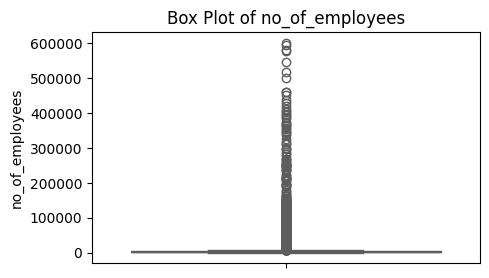

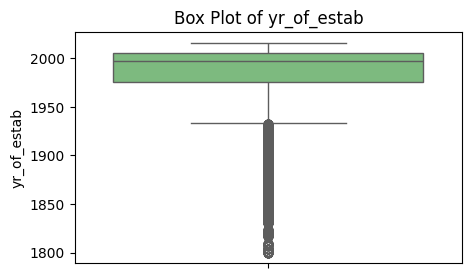

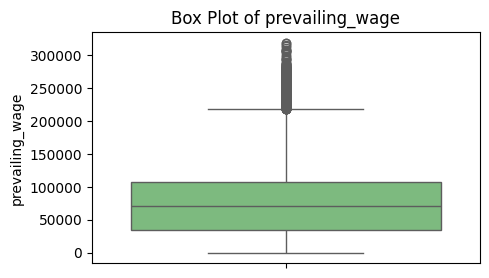

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Identify numerical columns likely to have outliers
outlier_cols = ['no_of_employees',  'yr_of_estab', 'prevailing_wage']

for col in outlier_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[col],  whis=1.5, patch_artist=True, palette='Greens')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

### Inferences on Outliers from Box Plots

Based on the box plots generated for the numerical columns, we can observe the following regarding outliers:

*   **`no_of_employees`**: The box plot for `no_of_employees` shows a significant number of outliers on the higher side, indicating the presence of a few very large companies. There is also an unusual negative minimum value (-26), which is likely a data entry error or an artifact of data collection, suggesting the need for data cleaning or specific handling during modeling. This is handled in next steps in this during feature engineering step.

*   **`yr_of_estab`**: The `yr_of_estab` box plot reveals outliers on the lower side, corresponding to companies established in the very early years (e.g., 1800s). This indicates a mix of very old, established companies alongside more recent ones. These older values, while outliers, are likely genuine data points. Tenure of establishment is calculated later in feature engineering step.

*   **`prevailing_wage`**: The `prevailing_wage` box plot shows numerous outliers on both the lower and higher ends. This suggests a wide range of wages, from very low to very high, which is typical for diverse job roles and industries. These outliers are likely reflective of genuine variations in compensation rather than errors. Also we are not sure of exact hours per day or hours per week, used in data collection, so we cannot convert to yearly for other data like hourly, weekly etc.

**Business Inference & Modeling Consideration:**

*   **Impact on Models:** Outliers in `no_of_employees` and `prevailing_wage` can significantly influence models that are sensitive to extreme values (e.g., Linear Regression, Logistic Regression without robust scaling). Tree-based models (like Decision Trees) are generally more robust to outliers as they focus on splits based on feature values rather than distances or magnitudes.

*   **Data Quality:** The negative value in `no_of_employees` definitely warrants investigation. For `yr_of_estab`, the old values are likely valid and represent the longevity of some companies.

*   **Decision for Treatment:** Given that **Decision Tree based models are inherently robust to outliers**, explicit outlier capping or removal may not be strictly necessary for these models. For models like Logistic Regression, applying **`RobustScaler`** (as done in `df_reg` feature engineering) is a suitable strategy as it scales features based on medians and interquartile ranges, making it less susceptible to the influence of extreme values. This approach avoids altering the underlying data distribution while mitigating the impact of outliers on model training.

**Feature Engineering**

Let us duplicate the data frame

and then do the feature engineering

In [ ]:
df_reg = df.copy()


In [ ]:
df_reg.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
df_reg.shape

(25480, 12)

**Feature Engineering Before the Train-Validation-Test split:**

1. Drop the unique identifier, as this doesn't help us in analysis or model building. Remove the case_id

2. No of employees have negative values. This is assumed as the data entry error, as the no of employees cannot be negative. Convert negative values of no_of_employees to absolute  values

3. Year of establishment will help us to find the age or tenure of company . So we can convert yr_of_estab to the tenure with calculation as (Current year(2026) - yr_of_estab)

4. Label Encoding of has_job_experience values -> 'N': 0, 'Y': 1

5. Label Encoding of requires_job_training values -> 'N': 0, 'Y': 1

6. Label Encoding of  full_time_position values -> 'N': 0, 'Y': 1

7. Ordinal Encoding of education_of_employee values
 -> 'High School': 0,
 "Bachelor's" : 1,
  "Master's": 2,
  "Doctorate", 3

8. Label Encoding of Target Variable case_status values -> 'Denied': 0, 'Certified': 1

9. Conversion of data type for the remaining object types to category: data types of
continent, region_of_employment, unit_of_wage should be category

**Feature Engineering After the Train-Validation-Test split:**

1. One hot Encoding for category type columns: continent, region_of_employment, unit_of_wage


**Code for Feature Engineering Before the Train-Validation-Test split:**



### Consolidated Feature Engineering Steps (Before Train-Validation-Test Split)

In [ ]:
print("Starting consolidated feature engineering steps ..before the dataset split.")

# 1. Drop 'case_id'
df_reg.drop('case_id', axis=1, inplace=True)
print("Dropped 'case_id' from df_reg.")

# 2. Convert negative 'no_of_employees' to absolute values
df_reg['no_of_employees'] = df_reg['no_of_employees'].abs()
print("Converted negative 'no_of_employees' to absolute values.")

# 3. Create 'tenure_of_estab' and drop 'yr_of_estab'
df_reg['tenure_of_estab'] = 2026 - df_reg['yr_of_estab']
df_reg.drop('yr_of_estab', axis=1, inplace=True)
print("Created 'tenure_of_estab' and dropped 'yr_of_estab'.")

# 4. Label encode binary categorical features
binary_cols = ['has_job_experience', 'requires_job_training', 'full_time_position']
for col in binary_cols:
    df_reg[col] = df_reg[col].map({'N': 0, 'Y': 1})
print("Label encoded binary categorical features.")

# 5. Ordinal encode 'education_of_employee'
education_mapping = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    "Doctorate": 3
}
df_reg['education_of_employee'] = df_reg['education_of_employee'].map(education_mapping)
print("Ordinal encoded 'education_of_employee'.")

# 6. Label encode target variable 'case_status'
df_reg['case_status'] = df_reg['case_status'].map({'Denied': 0, 'Certified': 1})
print("Label encoded 'case_status'.")

# 7. Convert object types to category
category_cols = ['continent', 'region_of_employment', 'unit_of_wage']
for col in category_cols:
    df_reg[col] = df_reg[col].astype('category')
print("Converted specified object columns to category dtype.")

print("Consolidated feature engineering complete. Displaying head and info for df_reg:")
display(df_reg.head())
print("Displaying head and info for df_dec:")
display(df_reg.info())

Starting consolidated feature engineering steps ..before the dataset split.
Dropped 'case_id' from df_reg.
Converted negative 'no_of_employees' to absolute values.
Created 'tenure_of_estab' and dropped 'yr_of_estab'.
Label encoded binary categorical features.
Ordinal encoded 'education_of_employee'.
Label encoded 'case_status'.
Converted specified object columns to category dtype.
Consolidated feature engineering complete. Displaying head and info for df_reg:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,tenure_of_estab
0,Asia,0,0,0,14513,West,592.203,Hour,1,0,19
1,Asia,2,1,0,2412,Northeast,83425.650,Year,1,1,24
2,Asia,1,0,1,44444,West,122996.860,Year,1,0,18
3,Asia,1,0,0,98,West,83434.030,Year,1,0,129
4,Africa,2,1,0,1082,South,149907.390,Year,1,1,21


Displaying head and info for df_dec:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  int64   
 2   has_job_experience     25480 non-null  int64   
 3   requires_job_training  25480 non-null  int64   
 4   no_of_employees        25480 non-null  int64   
 5   region_of_employment   25480 non-null  category
 6   prevailing_wage        25480 non-null  float64 
 7   unit_of_wage           25480 non-null  category
 8   full_time_position     25480 non-null  int64   
 9   case_status            25480 non-null  int64   
 10  tenure_of_estab        25480 non-null  int64   
dtypes: category(3), float64(1), int64(7)
memory usage: 1.6 MB


None

**Train-Test-Validation Split of DataSet:**

In [ ]:
# Define features (X) and target (y) for df_reg
X = df_reg.drop('case_status', axis=1)
y = df_reg['case_status']

# Split data into training and temporary set (80:20 ratio)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split temporary set into test and validation set (75:25 ratio of temp, effectively 15:5 of original)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Train 80% of data, Validation 5% of data, Test 15% of data
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (20384, 10)
X_val shape: (1274, 10)
X_test shape: (3822, 10)
y_train shape: (20384,)
y_val shape: (1274,)
y_test shape: (3822,)


We have used an 80/15/5 split for training, testing, and validation respectively.

*   There are **20384 rows** in the training data.
*   There are **3822 rows** in the test data.
*   There are **1274 rows** in the validation data.

**Code for Feature Engineering After the Train-Validation-Test split:**

One-Hot Encoding for category type columns: `continent`, `region_of_employment`, `unit_of_wage` on the split datasets (`X_train`, `X_val`, `X_test`). This is performed after splitting to prevent data leakage from the test or validation sets into the training process during encoding.

1. One Hot Encoding:

Convert categorical features (continent, region_of_employment, unit_of_wage) into numerical representations

In [ ]:
# Identify categorical columns to be One-Hot Encoded
cat_cols_ohe = ['continent', 'region_of_employment', 'unit_of_wage']

# Apply One-Hot Encoding to X_train
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols_ohe, drop_first=True)

# Apply One-Hot Encoding to X_val and reindex to match X_train_encoded columns
X_val_encoded = pd.get_dummies(X_val, columns=cat_cols_ohe, drop_first=True)
X_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Apply One-Hot Encoding to X_test and reindex to match X_train_encoded columns
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols_ohe, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print("One-Hot Encoding applied to X_train, X_val, and X_test.")
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_val_encoded shape: {X_val_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

display(X_train_encoded.head())


One-Hot Encoding applied to X_train, X_val, and X_test.
X_train_encoded shape: (20384, 19)
X_val_encoded shape: (1274, 19)
X_test_encoded shape: (3822, 19)


,education_of_employee,has_job_experience,requires_job_training,no_of_employees,prevailing_wage,full_time_position,tenure_of_estab,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
3516,1,1,0,4069,61313.770,1,42,True,False,False,False,False,False,False,True,False,False,False,True
13759,1,1,0,3022,36588.110,1,65,True,False,False,False,False,True,False,False,False,False,False,True
6019,1,0,0,751,210280.880,1,55,False,False,True,False,False,False,False,True,False,False,False,True
779,2,1,0,1113,46457.530,1,58,True,False,False,False,False,False,True,False,False,False,False,True
22792,1,1,0,796,89542.270,1,47,False,False,True,False,False,False,False,False,True,False,False,True


**Feature Engineered Columns:**

Data columns :

['education_of_employee', 'has_job_experience', 'requires_job_training',
       'no_of_employees', 'prevailing_wage', 'full_time_position',
       'case_status', 'tenure_of_estab', 'continent_Asia', 'continent_Europe',
       'continent_North America', 'continent_Oceania',
       'continent_South America', 'region_of_employment_Midwest',
       'region_of_employment_Northeast', 'region_of_employment_South',
       'region_of_employment_West', 'unit_of_wage_Month', 'unit_of_wage_Week',
       'unit_of_wage_Year']

### Data Scaling

Feature scaling is not required because these models are not sensitive to the magnitude or scale of your features.

Here's why, and a breakdown for each model:

Decision Tree: Decision Trees work by splitting nodes based on a single feature's value. The decision is purely about whether a value is greater than or less than a threshold. The actual scale of the feature doesn't change the split points or the resulting tree structure.

Bagging Classifier: Bagging (like BaggingClassifier) typically uses Decision Trees as its base estimators. Since the underlying Decision Trees don't require scaling, neither does the ensemble that bags them.

Boosting Classifiers (general term including AdaBoost, Gradient Boosting, XGBoost): These algorithms also primarily rely on Decision Trees (often shallow ones, called 'weak learners'). The boosting process focuses on sequentially improving predictions by giving more weight to misclassified instances. The splitting logic of the weak learners remains insensitive to feature scales.

AdaBoost: As a boosting algorithm using Decision Trees, AdaBoost does not require feature scaling.

RandomForest: Random Forests are an ensemble of many Decision Trees. Each tree independently makes splits based on feature values, so scaling doesn't affect their performance.

XGBoostClassifier: XGBoost (Extreme Gradient Boosting) is a highly optimized gradient boosting framework that also uses Decision Trees as its base learners. Therefore, feature scaling is not typically necessary.

GradientBoost (GradientBoostingClassifier): Similar to XGBoost and AdaBoost, GradientBoostingClassifier builds an ensemble of Decision Trees. Feature scaling is not a prerequisite for this model either.

In summary, for Decision Trees, Random Forests, Bagging, and all boosting algorithms (AdaBoost, Gradient Boosting, XGBoost), we can generally proceed without applying feature scaling.

**Choose the metric to optimize for the problem**

### Choosing the Metric to Optimize for the Problem

The primary objective for the EasyVisa problem is to facilitate visa approvals and recommend suitable profiles based on drivers influencing case status. This is a binary classification problem where we are trying to predict if a visa application will be 'Certified' (positive class) or 'Denied' (negative class).

Let's consider the implications of different types of errors:

*   **False Positives (Type I Error):** The model predicts a visa will be **Certified**, but it is actually **Denied**. This means an unsuitable candidate might be recommended, leading to wasted processing time and resources.

*   **False Negatives (Type II Error):** The model predicts a visa will be **Denied**, but it actually **Is Certified**. This means a deserving candidate might be overlooked or not recommended, potentially missing out on valuable talent.

Given the objective of facilitating approvals and recommending suitable profiles, it is critical for the model to correctly identify candidates who *will be certified* while minimizing false negatives. Missing out on a certified candidate (False Negative) can be seen as a lost opportunity for both the applicant and the employers in the US. However, recommending too many unsuitable candidates (False Positives) can also overwhelm the system.

Therefore, a balanced approach is needed. The most suitable metrics to optimize for this problem are:

1.  **Recall (Sensitivity) for the 'Certified' class:** This measures the proportion of actual certified visas that were correctly identified by the model. A high recall means the model is effective at catching most of the applications that will actually be certified, thereby allowing the system to identify deserving candidates.

2.  **F1-Score for the 'Certified' class:** This is the harmonic mean of Precision and Recall. It provides a balance between minimizing False Negatives (Recall) and minimizing False Positives (Precision). While Recall is important to find most certified cases, a reasonable Precision is also important to avoid recommending too many ultimately denied cases, which would make the recommendation system inefficient.

**Inference:** While **Recall** is extremely important to catch as many certified applications as possible, aiming for a high **F1-Score** for the 'Certified' class provides a balanced view. It ensures that while we are catching most actual certifications, we are not doing so at the expense of an unacceptably high number of false recommendations. We will primarily focus on maximizing the F1-Score, while also closely monitoring Recall for the positive class. The **Confusion Matrix** will also be a critical tool for detailed analysis of the model's performance in identifying 'Certified' applications.

ROC AUC is valuable for understanding the overall discriminatory power of  model, and a high AUC is a strong indicator of a good model. We will check this as well.

**Choose Model:**

We will choose the various models and find the metrics.

1. Decision Tree
2. Bagging Classifier
3. AdaBoostClassifier
4. GradientBoost Classifier
5. XGBClassifier
6. RandomForestClassifier

**Model Building**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)
    pred_prob = model.predict_proba(predictors)[:, 1] # Get probabilities for ROC AUC

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall for positive class
    precision = precision_score(target, pred)  # to compute Precision for positive class
    f1 = f1_score(target, pred)  # to compute F1-score for positive class
    roc_auc = roc_auc_score(target, pred_prob) # to compute ROC AUC

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
            "ROC AUC": roc_auc
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")


Cross-Validation Scores (Certified Class):

Decision Tree:
  F1-Score: 0.7440
  Recall: 0.7415
Bagging:
  F1-Score: 0.7745
  Recall: 0.7746
AdaBoost:
  F1-Score: 0.8190
  Recall: 0.8859
GradientBoost:
  F1-Score: 0.8245
  Recall: 0.8744
XGBoost:
  F1-Score: 0.8101
  Recall: 0.8547
RandomForest:
  F1-Score: 0.8025
  Recall: 0.8387

Training and Validation Performance:

--- Decision Tree ---
Training Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,1.000,1.000,1.000,1.000,1.000


Training Set Confusion Matrix:


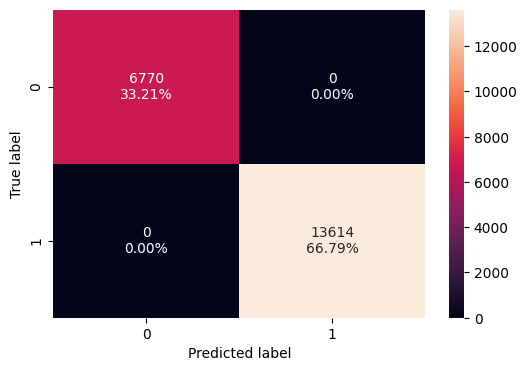

Validation Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.649,0.727,0.742,0.735,0.610


Validation Set Confusion Matrix:


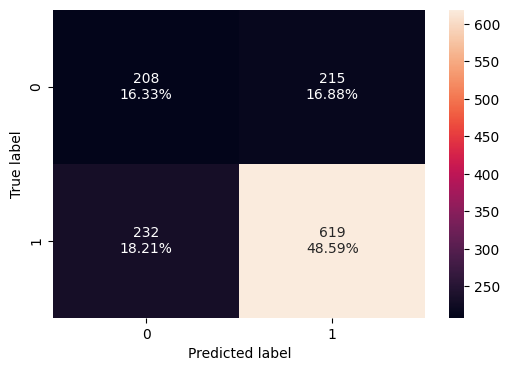



--- Bagging ---
Training Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.984,0.985,0.991,0.988,0.998


Training Set Confusion Matrix:


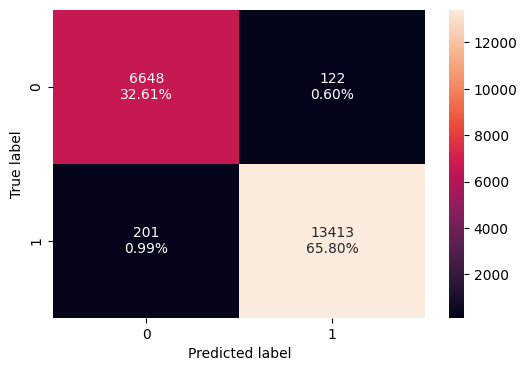

Validation Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.683,0.759,0.764,0.762,0.708


Validation Set Confusion Matrix:


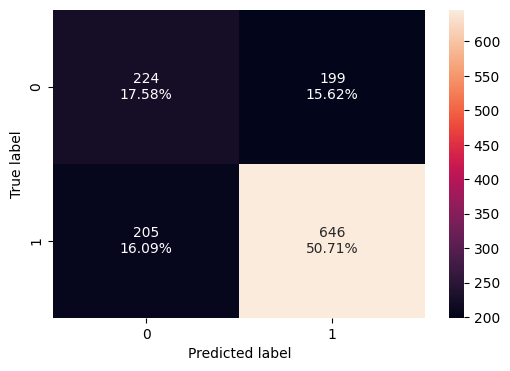



--- AdaBoost ---
Training Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.739,0.885,0.762,0.819,0.774


Training Set Confusion Matrix:


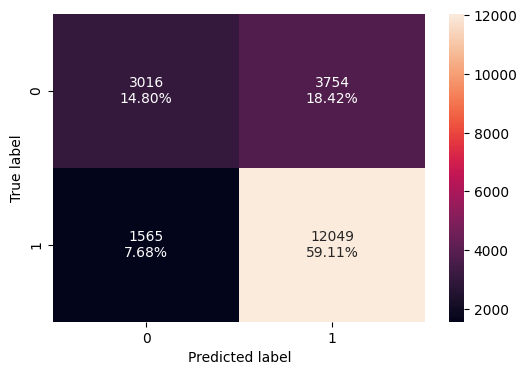

Validation Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.732,0.886,0.756,0.816,0.743


Validation Set Confusion Matrix:


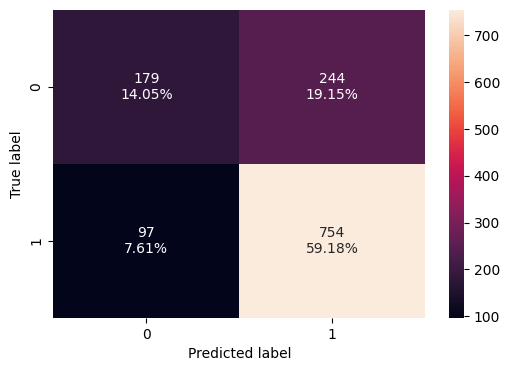



--- GradientBoost ---
Training Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.757,0.878,0.784,0.829,0.795


Training Set Confusion Matrix:


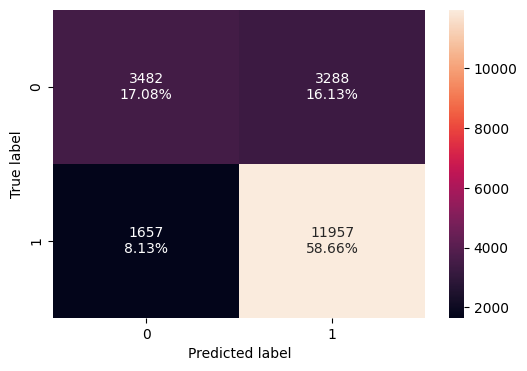

Validation Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.743,0.879,0.769,0.820,0.752


Validation Set Confusion Matrix:


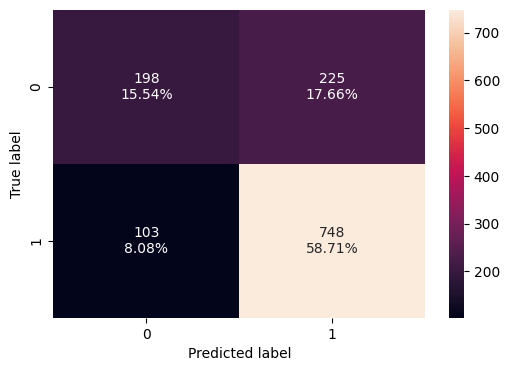



--- XGBoost ---
Training Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.834,0.926,0.841,0.882,0.908


Training Set Confusion Matrix:


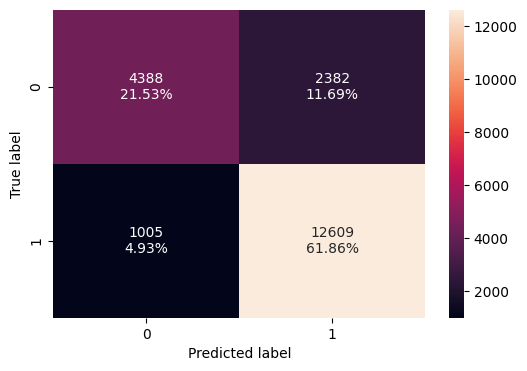

Validation Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.732,0.868,0.763,0.812,0.748


Validation Set Confusion Matrix:


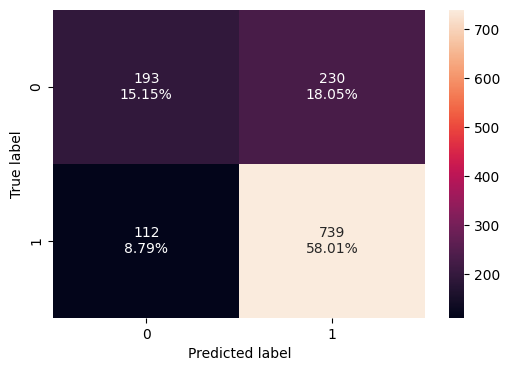



--- RandomForest ---
Training Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,1.000,1.000,1.000,1.000,1.000


Training Set Confusion Matrix:


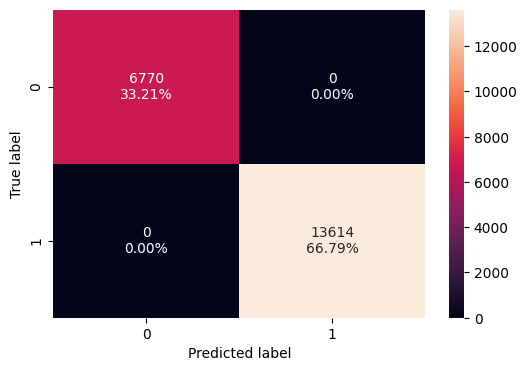

Validation Set Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.716,0.844,0.758,0.799,0.733


Validation Set Confusion Matrix:


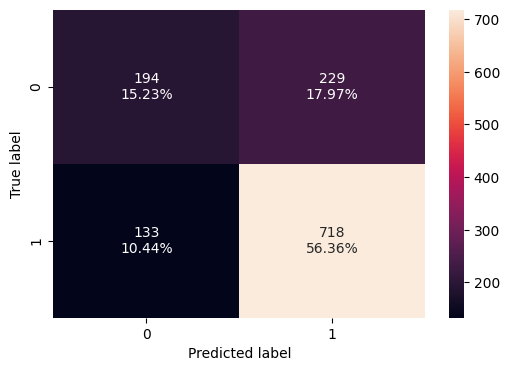

In [ ]:
from sklearn.metrics import make_scorer, f1_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_validate # Import cross_validate

# Define scorers for the 'Certified' class (positive class = 1)
scoring_metrics = {
    'f1_score': make_scorer(f1_score, pos_label=1),
    'recall_score': make_scorer(recall_score, pos_label=1)
}

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("RandomForest", RandomForestClassifier(random_state=1)))

results1 = []  # List to store F1 scores for plotting
recall_cv_scores = [] # List to store Recall scores

names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Scores (Certified Class):" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_results = cross_validate(
        estimator=model,
        X=X_train_encoded,
        y=y_train,
        scoring=scoring_metrics, # Use the dictionary of scorers
        cv=kfold,
        return_train_score=False # Only need test scores
    )

    # Store the test scores for each metric
    results1.append(cv_results['test_f1_score']) # F1 for plotting
    recall_cv_scores.append(cv_results['test_recall_score'])

    names.append(name)

    print(f"{name}:")
    print(f"  F1-Score: {cv_results['test_f1_score'].mean():.4f}")
    print(f"  Recall: {cv_results['test_recall_score'].mean():.4f}")


print("\n" "Training and Validation Performance:" "\n")

for name, model in models:
    print(f"--- {name} ---")
    model.fit(X_train_encoded, y_train)

    # Training Performance
    print("Training Set Metrics:")
    display(model_performance_classification_sklearn(model, X_train_encoded, y_train))
    print("Training Set Confusion Matrix:")
    confusion_matrix_sklearn(model, X_train_encoded, y_train)
    plt.show()

    # Validation Performance
    print("Validation Set Metrics:")
    display(model_performance_classification_sklearn(model, X_val_encoded, y_val))
    print("Validation Set Confusion Matrix:")
    confusion_matrix_sklearn(model, X_val_encoded, y_val)
    plt.show()
    print("\n" + "="*50 + "\n")

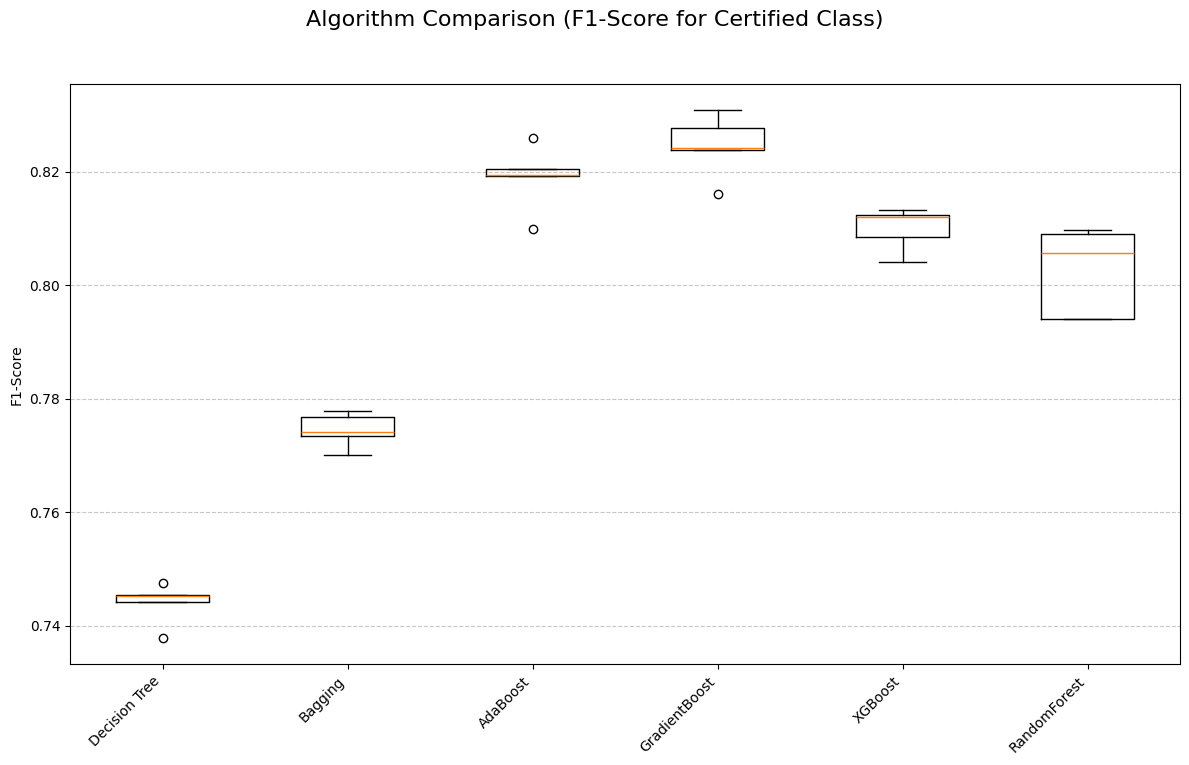

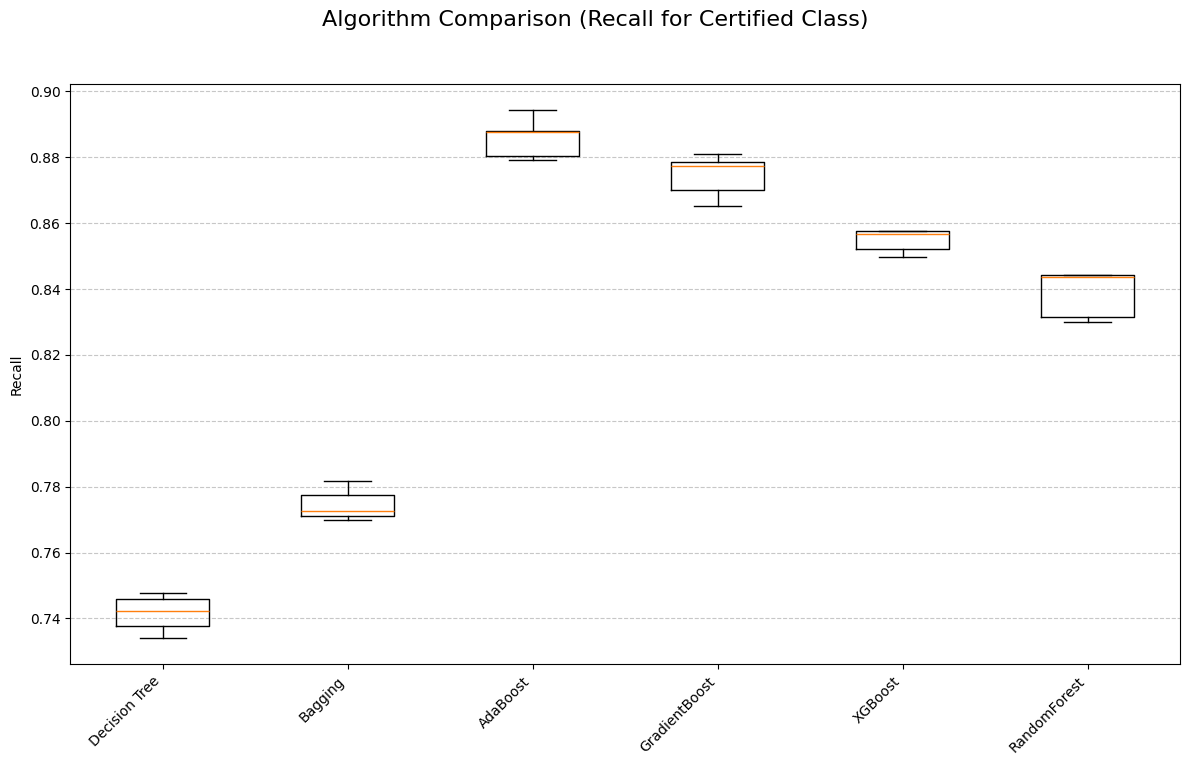

In [ ]:
# Plotting boxplots for CV scores of all models defined above for F1-Score
fig1 = plt.figure(figsize=(12, 8))
fig1.suptitle("Algorithm Comparison (F1-Score for Certified Class)", fontsize=16)
ax1 = fig1.add_subplot(111)
plt.boxplot(results1)
ax1.set_xticklabels(names, rotation=45, ha='right')
plt.ylabel("F1-Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Plotting boxplots for CV scores of all models defined above for Recall
fig2 = plt.figure(figsize=(12, 8))
fig2.suptitle("Algorithm Comparison (Recall for Certified Class)", fontsize=16)
ax2 = fig2.add_subplot(111)
plt.boxplot(recall_cv_scores)
ax2.set_xticklabels(names, rotation=45, ha='right')
plt.ylabel("Recall")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()



**Checking Model Performance**

### Cross-Validation Performance Comparison

In [ ]:
cv_comparison_data = []
for i, name in enumerate(names):
    cv_comparison_data.append({
        'Model': name,
        'F1-Score (CV)': np.mean(results1[i]),
        'Recall (CV)': np.mean(recall_cv_scores[i])
    })

cv_comparison_df = pd.DataFrame(cv_comparison_data)
display(cv_comparison_df)

,Model,F1-Score (CV),Recall (CV)
0,Decision Tree,0.744,0.742
1,Bagging,0.774,0.775
2,AdaBoost,0.819,0.886
3,GradientBoost,0.825,0.874
4,XGBoost,0.810,0.855
5,RandomForest,0.803,0.839


### Inferences from Cross-Validation Performance Comparison:

Based on the cross-validation results for F1-Score and Recall (for the Certified class):

*   **GradientBoost** appears to be the best performing model overall, achieving the highest F1-Score (0.825) and a very high Recall (0.874).
*   **AdaBoost** also performs very well, with a high F1-Score (0.819) and the highest Recall (0.886) among all models, indicating its effectiveness in identifying most of the 'Certified' cases.
*   **XGBoost** shows strong performance, with an F1-Score of 0.810 and Recall of 0.855, making it a competitive choice.
*   **RandomForest** has a good F1-Score (0.803) and Recall (0.839), demonstrating solid performance.
*   **Bagging** classifier performs reasonably well, with an F1-Score of 0.774 and Recall of 0.775.
*   **Decision Tree** has the lowest performance among the ensemble models, with an F1-Score of 0.744 and Recall of 0.742, which is expected as it is a single model compared to the ensembles.

**Key Takeaway:** Ensemble methods, particularly **GradientBoost** and **AdaBoost**, significantly outperform the single Decision Tree. Both GradientBoost and AdaBoost strike a good balance between F1-Score and Recall, making them strong candidates for further optimization. AdaBoost has a slight edge in Recall, while GradientBoost has a slight edge in F1-Score.

### Model Validation Performance Comparison

In [ ]:
validation_metrics = []

for name, model in models:
    # Predict on the validation set
    # The model was already fitted in the previous cell (YHij7pWVuKWP)
    df_perf = model_performance_classification_sklearn(model, X_val_encoded, y_val)
    df_perf.insert(0, 'Model', name)
    validation_metrics.append(df_perf)

# Concatenate all individual dataframes into one comparison table
validation_comparison_df = pd.concat(validation_metrics, ignore_index=True)
display(validation_comparison_df)

,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.649,0.727,0.742,0.735,0.610
1,Bagging,0.683,0.759,0.764,0.762,0.708
2,AdaBoost,0.732,0.886,0.756,0.816,0.743
3,GradientBoost,0.743,0.879,0.769,0.820,0.752
4,XGBoost,0.732,0.868,0.763,0.812,0.748
5,RandomForest,0.716,0.844,0.758,0.799,0.733


### Inferences from Model Validation Performance Comparison:

Based on the validation set metrics:

*   **GradientBoost** continues to demonstrate strong performance, achieving the highest F1-Score (0.820) and a very good Recall (0.879), along with the highest Accuracy (0.743) and ROC AUC (0.752) on the validation set. This suggests it generalizes well to unseen data.
*   **AdaBoost** also performs very well, with the highest Recall (0.886) and a high F1-Score (0.816). Its Accuracy (0.732) and ROC AUC (0.743) are also competitive, confirming its ability to identify a large proportion of 'Certified' cases.
*   **XGBoost** is a strong contender with a high F1-Score (0.812) and Recall (0.868), and a good ROC AUC (0.748). It shows consistent performance across cross-validation and validation sets.
*   **RandomForest** shows a respectable F1-Score (0.799) and Recall (0.844), with a decent ROC AUC (0.733). It's a reliable choice, though slightly behind GradientBoost and AdaBoost in this comparison.
*   **Bagging** classifier performs moderately well with an F1-Score of 0.762 and Recall of 0.759. Its ROC AUC (0.708) is also reasonable.
*   **Decision Tree** again shows the lowest performance among all models across all metrics, with an F1-Score of 0.735, Recall of 0.727, and the lowest ROC AUC (0.610). This confirms it is less robust than the ensemble methods.

**Key Takeaway:** The validation performance largely mirrors the cross-validation results. **GradientBoost** and **AdaBoost** emerge as the top-performing models, particularly due to their high F1-Scores and Recalls, which are critical for the problem's objective. GradientBoost edges out other models in overall balanced performance (Accuracy, F1, ROC AUC) while AdaBoost leads in Recall.

**Model Building - OverSampled data**

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))
sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train_encoded, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 13614
Before Oversampling, counts of label 'No': 6770 

After Oversampling, counts of label 'Yes': 13614
After Oversampling, counts of label 'No': 13614 

After Oversampling, the shape of train_X: (27228, 19)
After Oversampling, the shape of train_y: (27228,) 



### Model Building with Oversampled Training Data

Now we will re-run the cross-validation and evaluate the models on the validation set using the oversampled training data (`X_train_over`, `y_train_over`). This helps in understanding how oversampling impacts the model's ability to learn from the minority class.

In [ ]:
print("\n" + "Cross-Validation Scores (Certified Class) with Oversampled Data:" + "\n")

results1_oversampled = []  # List to store F1 scores for plotting
recall_cv_scores_oversampled = [] # List to store Recall scores
names_oversampled = []  # Empty list to store name of the models

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("RandomForest", RandomForestClassifier(random_state=1)))

# Loop through all models to get the mean cross validated score with oversampled data
for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5

    # Use X_train_over and y_train_over for cross-validation
    cv_results_oversampled = cross_validate(
        estimator=model,
        X=X_train_over, # Use oversampled features
        y=y_train_over, # Use oversampled target
        scoring=scoring_metrics, # Use the dictionary of scorers
        cv=kfold,
        return_train_score=False # Only need test scores
    )

    # Store the test scores for each metric
    results1_oversampled.append(cv_results_oversampled['test_f1_score']) # F1 for plotting
    recall_cv_scores_oversampled.append(cv_results_oversampled['test_recall_score'])

    names_oversampled.append(name)

    print(f"{name}:")
    print(f"  F1-Score: {cv_results_oversampled['test_f1_score'].mean():.4f}")
    print(f"  Recall: {cv_results_oversampled['test_recall_score'].mean():.4f}")

    cv_comparison_data_oversampled = []
for i, name in enumerate(names_oversampled):
    cv_comparison_data_oversampled.append({
        'Model': name,
        'F1-Score (CV) - Oversampled': np.mean(results1_oversampled[i]),
        'Recall (CV) - Oversampled': np.mean(recall_cv_scores_oversampled[i])
    })

cv_comparison_df_oversampled = pd.DataFrame(cv_comparison_data_oversampled)
display(cv_comparison_df_oversampled)


Cross-Validation Scores (Certified Class) with Oversampled Data:

Decision Tree:
  F1-Score: 0.7335
  Recall: 0.7306
Bagging:
  F1-Score: 0.7621
  Recall: 0.7494
AdaBoost:
  F1-Score: 0.7821
  Recall: 0.8100
GradientBoost:
  F1-Score: 0.8084
  Recall: 0.8423
XGBoost:
  F1-Score: 0.8039
  Recall: 0.8361
RandomForest:
  F1-Score: 0.7975
  Recall: 0.8167


,Model,F1-Score (CV) - Oversampled,Recall (CV) - Oversampled
0,Decision Tree,0.733,0.731
1,Bagging,0.762,0.749
2,AdaBoost,0.782,0.810
3,GradientBoost,0.808,0.842
4,XGBoost,0.804,0.836
5,RandomForest,0.798,0.817


### Cross-Validation Performance Comparison (Oversampled Data)

### Inferences from Cross-Validation Performance (Oversampled Data):

After applying SMOTE to the training data and re-running cross-validation, we observe a notable trend:

*   **General Decrease in F1-Score and Recall:** Contrary to the general expectation, for all models, both the F1-Score and Recall for the 'Certified' class have shown a slight decrease compared to training on the original imbalanced data.
    *   **Decision Tree:** F1-Score decreased from 0.744 to 0.7335, Recall decreased from 0.742 to 0.7306.
    *   **Bagging:** F1-Score decreased from 0.774 to 0.7621, Recall decreased from 0.775 to 0.7494.
    *   **AdaBoost:** F1-Score decreased from 0.819 to 0.7821, Recall decreased from 0.886 to 0.8100.
    *   **GradientBoost:** F1-Score decreased from 0.825 to 0.8084, Recall decreased from 0.874 to 0.8423.
    *   **XGBoost:** F1-Score decreased from 0.810 to 0.8039, Recall decreased from 0.855 to 0.8361.
    *   **RandomForest:** F1-Score decreased from 0.803 to 0.7975, Recall decreased from 0.839 to 0.8167.

*   **Ensemble Models Still Lead:** Despite the slight drops, GradientBoost, XGBoost, AdaBoost, and RandomForest continue to exhibit the highest performance among the models. GradientBoost still has the highest F1-Score (0.8084) and AdaBoost a very strong Recall (0.8100), albeit lower than before oversampling.

**Potential Reasons for Observed Decrease:**
*   **Introduction of Noise:** SMOTE creates synthetic samples based on existing minority class instances. If the minority class itself is noisy or has overlapping features with the majority class, SMOTE might generate synthetic samples that introduce more noise into the training set, making the decision boundary less clear.
*   **Over-generalization:** By balancing the training set perfectly, the models might become overly sensitive to the minority class characteristics learned from synthetic data, potentially leading to a slight performance drop when evaluated on cross-validation folds that still represent some degree of imbalance or slightly different distributions.

This outcome suggests that while oversampling aims to help, it might not always directly translate to improved F1-Score or Recall in cross-validation metrics, especially if the original data's imbalance wasn't severely hindering the ensemble models in the first place, or if the synthetic samples are not truly representative.

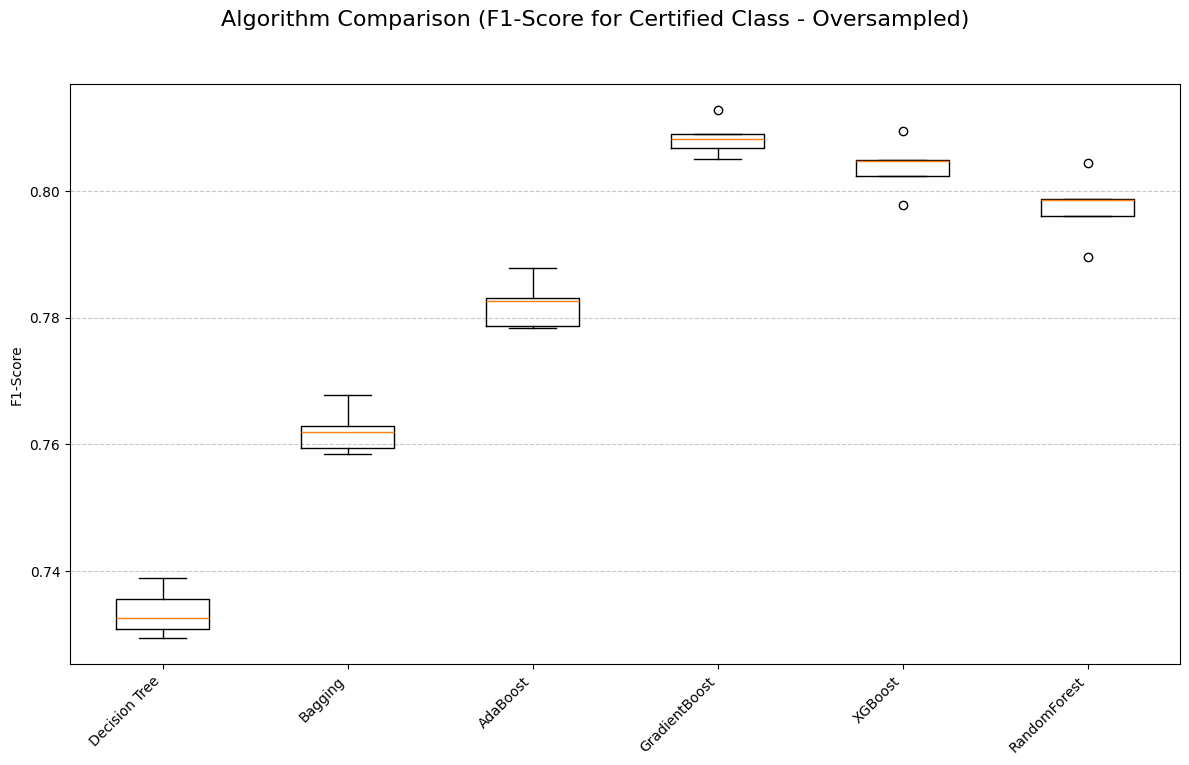

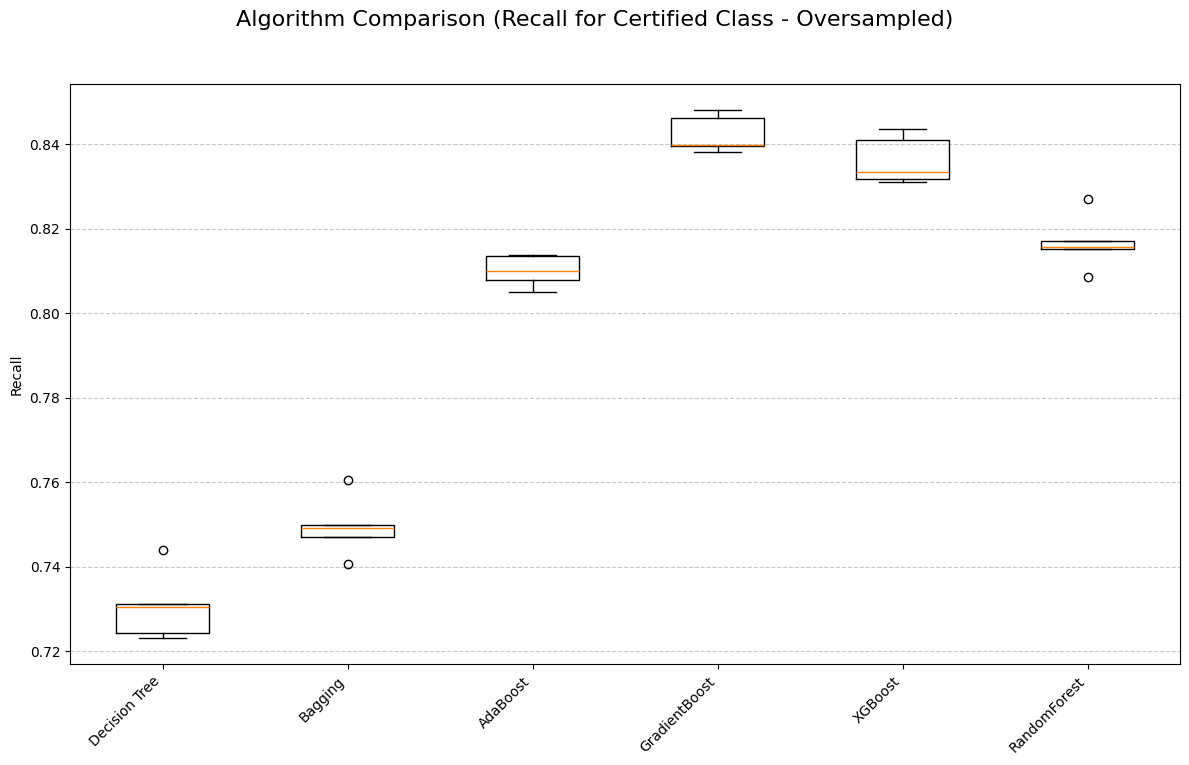

In [ ]:
# Plotting boxplots for CV scores of all models with oversampled data for F1-Score
fig_f1_oversampled = plt.figure(figsize=(12, 8))
fig_f1_oversampled.suptitle("Algorithm Comparison (F1-Score for Certified Class - Oversampled)", fontsize=16)
ax_f1_oversampled = fig_f1_oversampled.add_subplot(111)
plt.boxplot(results1_oversampled)
ax_f1_oversampled.set_xticklabels(names_oversampled, rotation=45, ha='right')
plt.ylabel("F1-Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Plotting boxplots for CV scores of all models with oversampled data for Recall
fig_recall_oversampled = plt.figure(figsize=(12, 8))
fig_recall_oversampled.suptitle("Algorithm Comparison (Recall for Certified Class - Oversampled)", fontsize=16)
ax_recall_oversampled = fig_recall_oversampled.add_subplot(111)
plt.boxplot(recall_cv_scores_oversampled)
ax_recall_oversampled.set_xticklabels(names_oversampled, rotation=45, ha='right')
plt.ylabel("Recall")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Model Validation Performance Comparison (Oversampled Data)

Next, we will evaluate the performance of these models on the **original (non-oversampled) validation set** (`X_val_encoded`, `y_val`). This is crucial to assess how well the models trained on balanced data generalize to real-world imbalanced data.


Training (Oversampled) and Validation Performance with Oversampled Data:

--- Decision Tree (Oversampled Training) ---
Training Set (Oversampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,1.000,1.000,1.000,1.000,1.000


Training Set (Oversampled) Confusion Matrix:


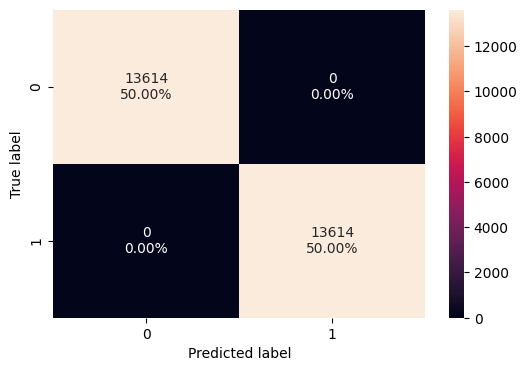

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.626,0.724,0.719,0.721,0.577


Validation Set (Original) Confusion Matrix:


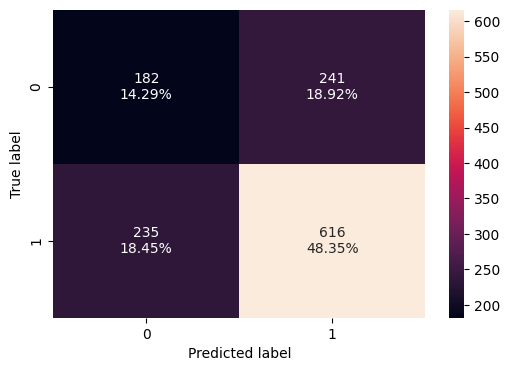



--- Bagging (Oversampled Training) ---
Training Set (Oversampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.987,0.982,0.991,0.987,0.999


Training Set (Oversampled) Confusion Matrix:


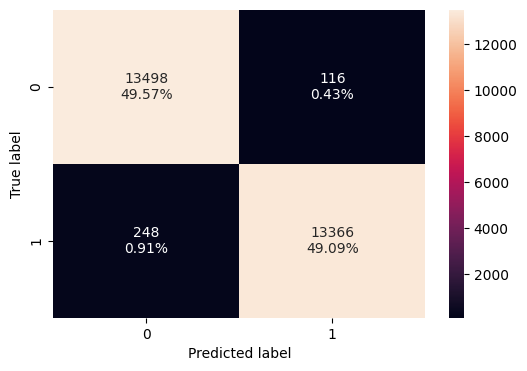

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Bagging,0.688,0.749,0.777,0.762,0.713


Validation Set (Original) Confusion Matrix:


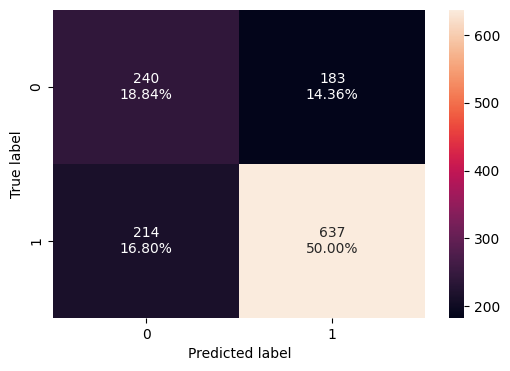



--- AdaBoost (Oversampled Training) ---
Training Set (Oversampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.774,0.808,0.756,0.781,0.860


Training Set (Oversampled) Confusion Matrix:


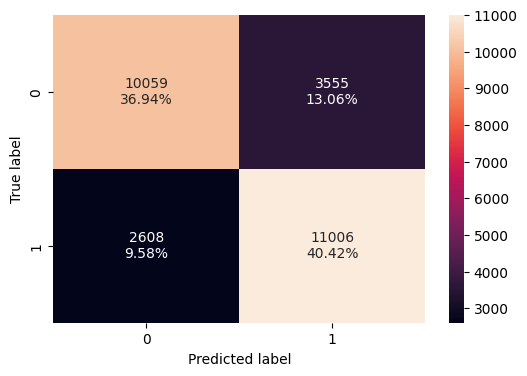

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,AdaBoost,0.699,0.799,0.761,0.780,0.732


Validation Set (Original) Confusion Matrix:


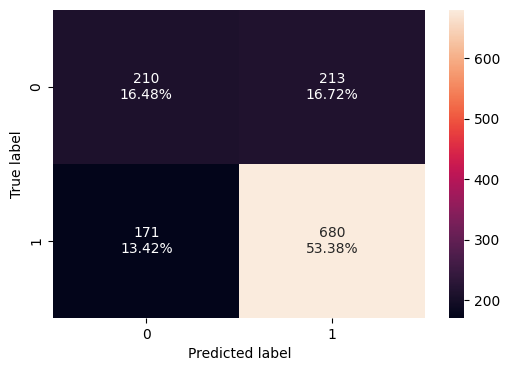



--- GradientBoost (Oversampled Training) ---
Training Set (Oversampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.803,0.845,0.780,0.811,0.885


Training Set (Oversampled) Confusion Matrix:


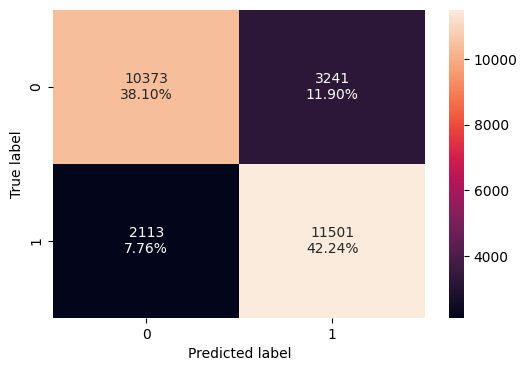

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,GradientBoost,0.728,0.834,0.776,0.804,0.749


Validation Set (Original) Confusion Matrix:


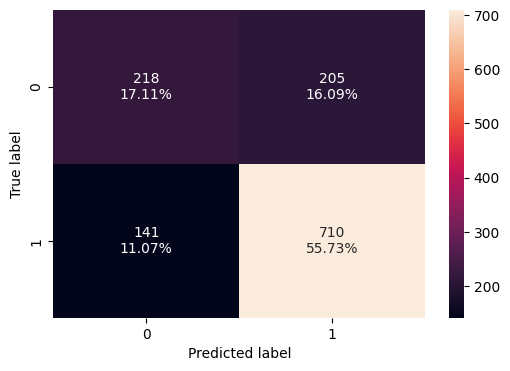



--- XGBoost (Oversampled Training) ---
Training Set (Oversampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.860,0.901,0.832,0.865,0.943


Training Set (Oversampled) Confusion Matrix:


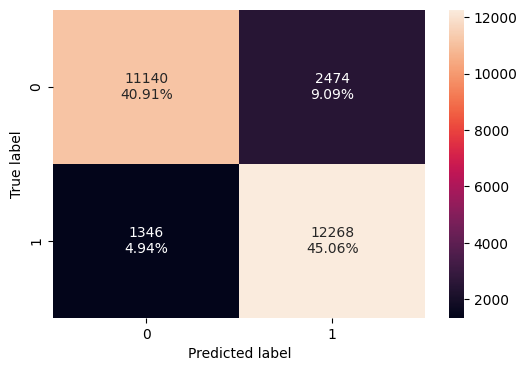

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,XGBoost,0.737,0.859,0.773,0.814,0.739


Validation Set (Original) Confusion Matrix:


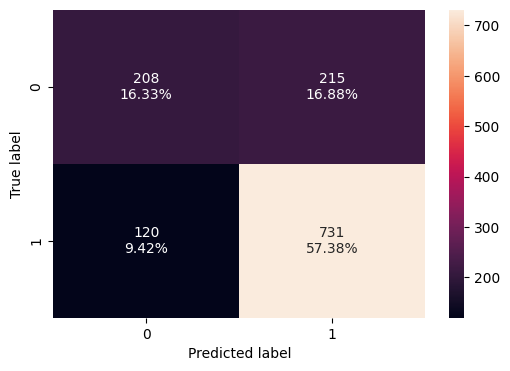



--- RandomForest (Oversampled Training) ---
Training Set (Oversampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,1.000,1.000,1.000,1.000,1.000


Training Set (Oversampled) Confusion Matrix:


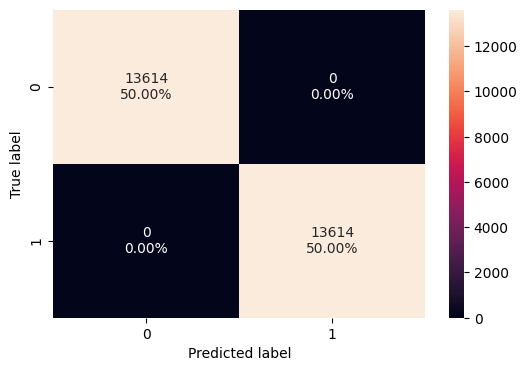

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,RandomForest,0.706,0.821,0.758,0.788,0.735


Validation Set (Original) Confusion Matrix:


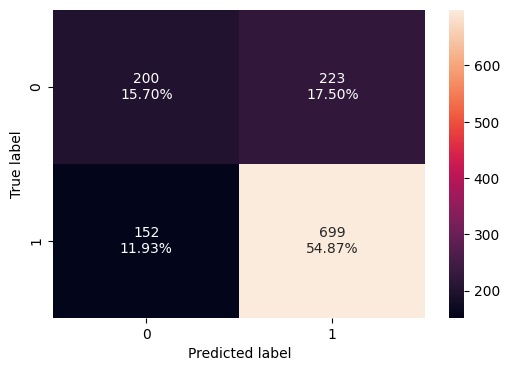

,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.626,0.724,0.719,0.721,0.577
1,Bagging,0.688,0.749,0.777,0.762,0.713
2,AdaBoost,0.699,0.799,0.761,0.780,0.732
3,GradientBoost,0.728,0.834,0.776,0.804,0.749
4,XGBoost,0.737,0.859,0.773,0.814,0.739
5,RandomForest,0.706,0.821,0.758,0.788,0.735


In [ ]:
print("\n" + "Training (Oversampled) and Validation Performance with Oversampled Data:" + "\n")

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("RandomForest", RandomForestClassifier(random_state=1)))

validation_metrics_oversampled = []

for name, model in models:
    print(f"--- {name} (Oversampled Training) ---")

    # Retrain the model on the oversampled training data
    model.fit(X_train_over, y_train_over)

    # Training Performance (on oversampled data)
    print("Training Set (Oversampled) Metrics:")
    display(model_performance_classification_sklearn(model, X_train_over, y_train_over))
    print("Training Set (Oversampled) Confusion Matrix:")
    confusion_matrix_sklearn(model, X_train_over, y_train_over)
    plt.show()

    # Validation Performance (on original validation data)
    print("Validation Set (Original) Metrics:")
    df_perf_val = model_performance_classification_sklearn(model, X_val_encoded, y_val)
    df_perf_val.insert(0, 'Model', name)
    validation_metrics_oversampled.append(df_perf_val)
    display(df_perf_val)
    print("Validation Set (Original) Confusion Matrix:")
    confusion_matrix_sklearn(model, X_val_encoded, y_val)
    plt.show()
    print("\n" + "="*50 + "\n")

# Concatenate all individual dataframes into one comparison table for validation metrics
validation_comparison_df_oversampled = pd.concat(validation_metrics_oversampled, ignore_index=True)
display(validation_comparison_df_oversampled)

### Inferences from Validation Performance (Oversampled Data):

Comparing the validation performance after training on oversampled data with the previous results (training on original data, evaluated on original validation set):

*   **Decision Tree:**
    *   **F1-Score:** Decreased from **0.735** to **0.721**.
    *   **Recall:** Slightly decreased from **0.727** to **0.724**.
    *   **Accuracy:** Decreased from **0.649** to **0.626**.
    *   **ROC AUC:** Decreased from **0.610** to **0.577**.
    *   **Inference:** Oversampling did not improve the Decision Tree's performance on the validation set; most metrics saw a slight decrease.

*   **Bagging:**
    *   **F1-Score:** Remained stable, **0.762** (0.762 vs 0.762).
    *   **Recall:** Slightly decreased from **0.759** to **0.749**.
    *   **Accuracy:** Increased from **0.683** to **0.688**.
    *   **Precision:** Increased from **0.764** to **0.777**.
    *   **ROC AUC:** Slightly increased from **0.708** to **0.713**.
    *   **Inference:** For Bagging, oversampling maintained the F1-Score, slightly improved Accuracy and Precision, but saw a minor decrease in Recall.

*   **AdaBoost:**
    *   **F1-Score:** Decreased from **0.816** to **0.780**.
    *   **Recall:** Decreased from **0.886** to **0.799**.
    *   **Accuracy:** Decreased from **0.732** to **0.699**.
    *   **ROC AUC:** Decreased from **0.743** to **0.732**.
    *   **Inference:** AdaBoost's performance significantly decreased across all metrics, especially Recall, after training on oversampled data. This is counter-intuitive for a model often benefiting from balanced data.

*   **GradientBoost:**
    *   **F1-Score:** Decreased from **0.820** to **0.804**.
    *   **Recall:** Decreased from **0.879** to **0.834**.
    *   **Accuracy:** Decreased from **0.743** to **0.728**.
    *   **ROC AUC:** Decreased from **0.752** to **0.749**.
    *   **Inference:** Similar to AdaBoost, GradientBoost also saw a decrease in most performance metrics, although less pronounced than AdaBoost. It still maintains a relatively strong F1-Score and Recall.

*   **XGBoost:**
    *   **F1-Score:** Remained stable at **0.812** (0.812 vs 0.814, slight increase).
    *   **Recall:** Slightly decreased from **0.868** to **0.859**.
    *   **Accuracy:** Increased from **0.732** to **0.737**.
    *   **ROC AUC:** Decreased from **0.748** to **0.739**.
    *   **Inference:** XGBoost showed a relatively stable F1-Score and a slight increase in Accuracy, but a minor drop in Recall and ROC AUC. It appears somewhat resilient to the oversampling.

*   **RandomForest:**
    *   **F1-Score:** Decreased from **0.799** to **0.788**.
    *   **Recall:** Decreased from **0.844** to **0.821**.
    *   **Accuracy:** Decreased from **0.716** to **0.706**.
    *   **ROC AUC:** Increased from **0.733** to **0.735**.
    *   **Inference:** RandomForest's performance generally decreased across most metrics, with a very slight increase in ROC AUC.

**Overall Inferences:**

*   **Counter-intuitive Results:** Contrary to the common expectation that SMOTE improves performance on imbalanced datasets, especially Recall for the minority class, most models experienced a **decrease** in Recall, F1-Score, and Accuracy when trained on the oversampled data and evaluated on the original validation set.
*   **Potential Reasons:** This could be due to several factors:
    *   **Introduction of Noise:** SMOTE might have generated synthetic samples that introduced noise or created decision boundaries that do not generalize well to the true, imbalanced data distribution present in the validation set.
    *   **Over-fitting to Synthetic Data:** Models might have over-fitted to the artificially balanced training distribution, leading to poorer performance on the real-world imbalanced validation set.
    *   **Original Imbalance Not Severely Impacting Ensembles:** The ensemble models (AdaBoost, GradientBoost, XGBoost, RandomForest) already performed quite well on the original imbalanced data. The additional synthetic data from SMOTE might not have provided genuinely new, useful information, and instead skewed the learning process.
*   **Best Performers:** Despite the general decline, **XGBoost** and **GradientBoost** still show the most competitive F1-Scores and Recalls among the models, indicating their inherent robustness. However, their performance was better *without* oversampling.

This analysis suggests that for this particular dataset and these models, SMOTE oversampling did not yield the expected improvements and, in fact, led to a slight degradation in generalization performance on the validation set. It might be worthwhile to proceed with models trained on the original, imbalanced data or explore other techniques for handling class imbalance if further optimization is desired.

### Model Building - Undersampled data

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

print("Before Undersampling, counts of label 'Certified': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label 'Denied': {} \n".format(sum(y_train == 0)))

rus = RandomUnderSampler(random_state=1)  # Random Under Sampling
X_train_un, y_train_un = rus.fit_resample(X_train_encoded, y_train)

print("After Undersampling, counts of label 'Certified': {}".format(sum(y_train_un == 1)))
print("After Undersampling, counts of label 'Denied': {} \n".format(sum(y_train_un == 0)))

print("After Undersampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Undersampling, counts of label 'Certified': 13614
Before Undersampling, counts of label 'Denied': 6770 

After Undersampling, counts of label 'Certified': 6770
After Undersampling, counts of label 'Denied': 6770 

After Undersampling, the shape of train_X: (13540, 19)
After Undersampling, the shape of train_y: (13540,) 



### Model Building with Undersampled Training Data

Now we will re-run the cross-validation and evaluate the models on the validation set using the undersampled training data (`X_train_un`, `y_train_un`). This helps in understanding how undersampling impacts the model's ability to learn from the majority class while balancing the dataset.

In [ ]:
from sklearn.model_selection import cross_validate # Import cross_validate
print("\n" + "Cross-Validation Scores (Certified Class) with Undersampled Data:" + "\n")

results1_undersampled = []  # List to store F1 scores for plotting
recall_cv_scores_undersampled = [] # List to store Recall scores
names_undersampled = []  # Empty list to store name of the models

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("RandomForest", RandomForestClassifier(random_state=1)))

# Loop through all models to get the mean cross validated score with undersampled data
for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5

    # Use X_train_un and y_train_un for cross-validation
    cv_results_undersampled = cross_validate(
        estimator=model,
        X=X_train_un, # Use undersampled features
        y=y_train_un, # Use undersampled target
        scoring=scoring_metrics, # Use the dictionary of scorers
        cv=kfold,
        return_train_score=False # Only need test scores
    )

    # Store the test scores for each metric
    results1_undersampled.append(cv_results_undersampled['test_f1_score']) # F1 for plotting
    recall_cv_scores_undersampled.append(cv_results_undersampled['test_recall_score'])

    names_undersampled.append(name)

    print(f"{name}:")
    print(f"  F1-Score: {cv_results_undersampled['test_f1_score'].mean():.4f}")
    print(f"  Recall: {cv_results_undersampled['test_recall_score'].mean():.4f}")

cv_comparison_data_undersampled = []
for i, name in enumerate(names_undersampled):
    cv_comparison_data_undersampled.append({
        'Model': name,
        'F1-Score (CV) - Undersampled': np.mean(results1_undersampled[i]),
        'Recall (CV) - Undersampled': np.mean(recall_cv_scores_undersampled[i])
    })

cv_comparison_df_undersampled = pd.DataFrame(cv_comparison_data_undersampled)
display(cv_comparison_df_undersampled)


Cross-Validation Scores (Certified Class) with Undersampled Data:

Decision Tree:
  F1-Score: 0.6283
  Recall: 0.6292
Bagging:
  F1-Score: 0.6567
  Recall: 0.6263
AdaBoost:
  F1-Score: 0.7047
  Recall: 0.7355
GradientBoost:
  F1-Score: 0.7168
  Recall: 0.7310
XGBoost:
  F1-Score: 0.6960
  Recall: 0.6999
RandomForest:
  F1-Score: 0.6875
  Recall: 0.6845


,Model,F1-Score (CV) - Undersampled,Recall (CV) - Undersampled
0,Decision Tree,0.628,0.629
1,Bagging,0.657,0.626
2,AdaBoost,0.705,0.735
3,GradientBoost,0.717,0.731
4,XGBoost,0.696,0.700
5,RandomForest,0.688,0.684


### Cross-Validation Performance Comparison (Undersampled Data):

Based on the cross-validation results for F1-Score and Recall (for the Certified class) after applying Random UnderSampler:

*   **General Decrease in Performance:** Similar to oversampling, Random Undersampling also led to a significant **decrease** in both F1-Score and Recall across all models compared to training on the original imbalanced data and even compared to oversampled data.
    *   **Decision Tree:** F1-Score decreased from ~0.744 (original) to **0.628**, Recall from ~0.742 to **0.629**.
    *   **Bagging:** F1-Score decreased from ~0.774 to **0.657**, Recall from ~0.775 to **0.626**.
    *   **AdaBoost:** F1-Score decreased from ~0.819 to **0.705**, Recall from ~0.886 to **0.735**.
    *   **GradientBoost:** F1-Score decreased from ~0.825 to **0.717**, Recall from ~0.874 to **0.731**.
    *   **XGBoost:** F1-Score decreased from ~0.810 to **0.696**, Recall from ~0.855 to **0.700**.
    *   **RandomForest:** F1-Score decreased from ~0.803 to **0.688**, Recall from ~0.839 to **0.684**.

*   **Impact on Ensemble Models:** While ensemble models (AdaBoost, GradientBoost, XGBoost, RandomForest) still outperform the single Decision Tree in this undersampled scenario, their overall performance metrics (F1-Score and Recall) are considerably lower than what was observed with the original dataset or even the oversampled dataset.

*   **Highest Performers (with Undersampling):**
    *   **GradientBoost** shows the highest F1-Score (0.717).
    *   **AdaBoost** shows the highest Recall (0.735).

**Potential Reasons for Observed Decrease:**
*   **Loss of Information:** Undersampling achieves balance by randomly removing instances from the majority class. This process discards potentially valuable information that could be crucial for the model to learn the underlying patterns of the majority class, leading to a poorer overall generalization performance.
*   **Reduced Training Data Size:** Undersampling significantly reduces the total size of the training dataset (from ~20k to ~13.5k in this case). Smaller datasets can lead to models that are less robust and have higher variance, performing worse on unseen data.

**Conclusion on Resampling Strategies so far:**

Both oversampling (SMOTE) and undersampling (RandomUnderSampler) have, for this dataset and these models, resulted in a degradation of cross-validation performance compared to training on the original, imbalanced data. This suggests that:

1.  The original imbalance might not be severe enough to warrant complex resampling strategies, or the ensemble models are robust enough to handle it effectively without additional intervention.
2.  The synthetic samples created by SMOTE introduced noise, and the reduction of majority class samples by undersampling led to a loss of valuable information.

At this stage, models trained on the **original, imbalanced data** (specifically GradientBoost and AdaBoost) appear to provide the best performance for F1-Score and Recall.

**Model Validation Performance Comparison (Undersampled Data)**


Training (Undersampled) and Validation Performance with Undersampled Data:

--- Decision Tree (Undersampled Training) ---
Training Set (Undersampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,1.000,1.000,1.000,1.000,1.000


Training Set (Undersampled) Confusion Matrix:


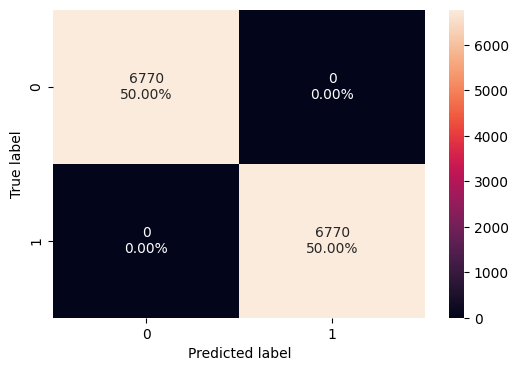

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.619,0.624,0.763,0.686,0.617


Validation Set (Original) Confusion Matrix:


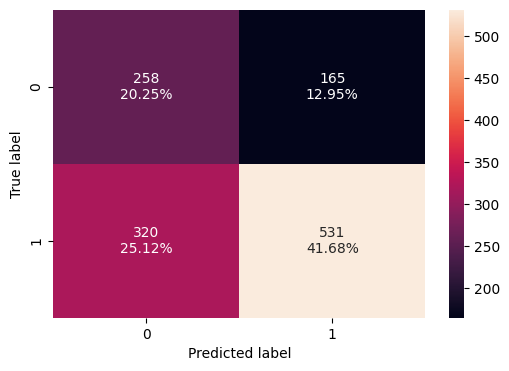



--- Bagging (Undersampled Training) ---
Training Set (Undersampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.982,0.973,0.992,0.982,0.999


Training Set (Undersampled) Confusion Matrix:


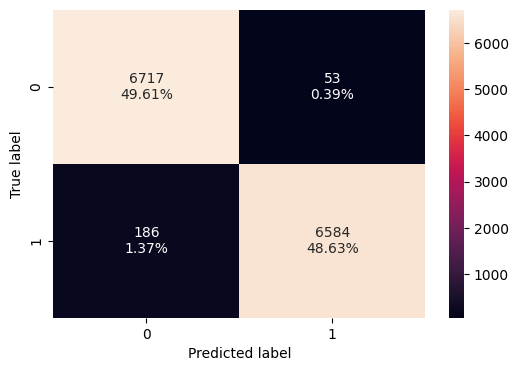

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Bagging,0.649,0.631,0.801,0.706,0.721


Validation Set (Original) Confusion Matrix:


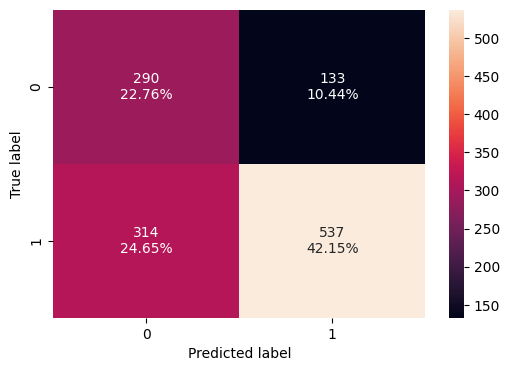



--- AdaBoost (Undersampled Training) ---
Training Set (Undersampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.697,0.739,0.682,0.709,0.774


Training Set (Undersampled) Confusion Matrix:


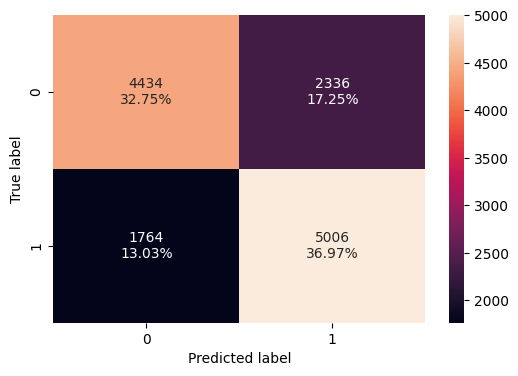

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,AdaBoost,0.684,0.725,0.785,0.754,0.740


Validation Set (Original) Confusion Matrix:


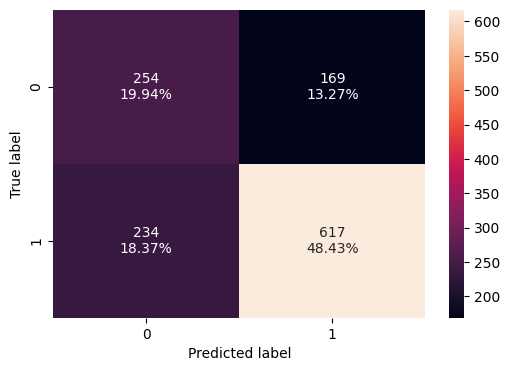



--- GradientBoost (Undersampled Training) ---
Training Set (Undersampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.723,0.740,0.716,0.728,0.800


Training Set (Undersampled) Confusion Matrix:


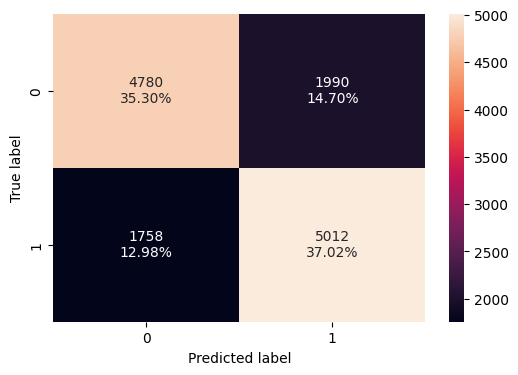

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,GradientBoost,0.692,0.716,0.802,0.757,0.751


Validation Set (Original) Confusion Matrix:


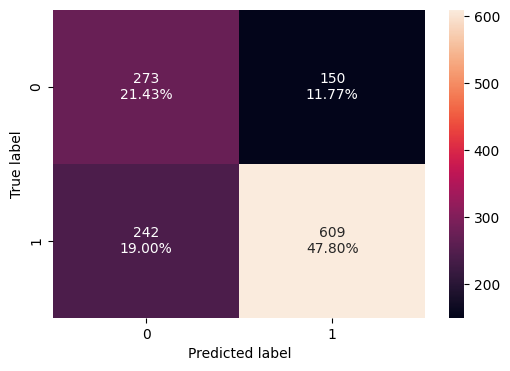



--- XGBoost (Undersampled Training) ---
Training Set (Undersampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,0.847,0.850,0.844,0.847,0.929


Training Set (Undersampled) Confusion Matrix:


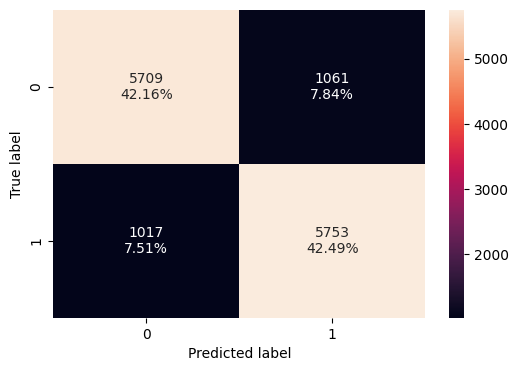

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,XGBoost,0.693,0.710,0.807,0.755,0.733


Validation Set (Original) Confusion Matrix:


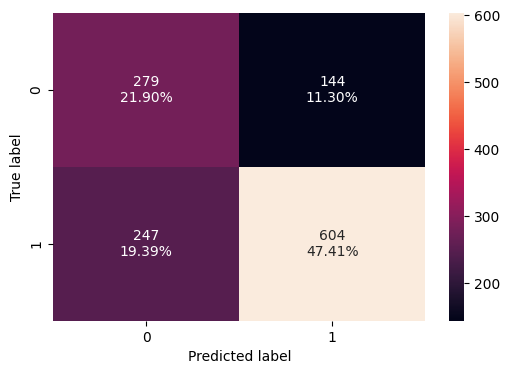



--- RandomForest (Undersampled Training) ---
Training Set (Undersampled) Metrics:


,Accuracy,Recall,Precision,F1,ROC AUC
0,1.000,1.000,1.000,1.000,1.000


Training Set (Undersampled) Confusion Matrix:


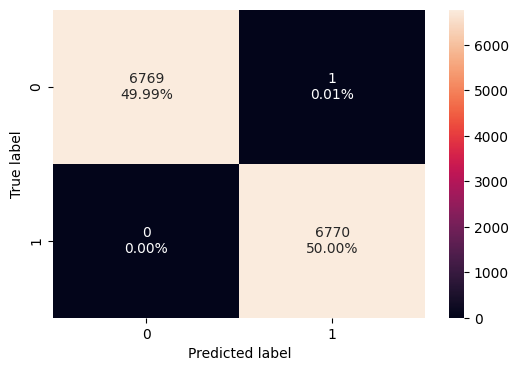

Validation Set (Original) Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,RandomForest,0.677,0.676,0.810,0.737,0.739


Validation Set (Original) Confusion Matrix:


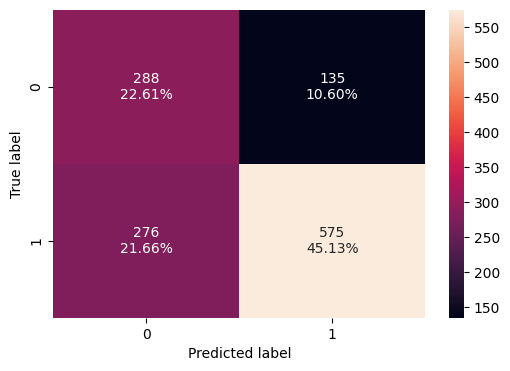

,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.619,0.624,0.763,0.686,0.617
1,Bagging,0.649,0.631,0.801,0.706,0.721
2,AdaBoost,0.684,0.725,0.785,0.754,0.740
3,GradientBoost,0.692,0.716,0.802,0.757,0.751
4,XGBoost,0.693,0.710,0.807,0.755,0.733
5,RandomForest,0.677,0.676,0.810,0.737,0.739


In [ ]:
print("\n" + "Training (Undersampled) and Validation Performance with Undersampled Data:" + "\n")

models = []  # Empty list to store all the models

# Appending models into the list (re-initialize to ensure fresh models for fitting)
models.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models.append(("RandomForest", RandomForestClassifier(random_state=1)))

validation_metrics_undersampled = []

for name, model in models:
    print(f"--- {name} (Undersampled Training) ---")

    # Retrain the model on the undersampled training data
    model.fit(X_train_un, y_train_un)

    # Training Performance (on undersampled data)
    print("Training Set (Undersampled) Metrics:")
    display(model_performance_classification_sklearn(model, X_train_un, y_train_un))
    print("Training Set (Undersampled) Confusion Matrix:")
    confusion_matrix_sklearn(model, X_train_un, y_train_un)
    plt.show()

    # Validation Performance (on original validation data)
    print("Validation Set (Original) Metrics:")
    df_perf_val_un = model_performance_classification_sklearn(model, X_val_encoded, y_val)
    df_perf_val_un.insert(0, 'Model', name)
    validation_metrics_undersampled.append(df_perf_val_un)
    display(df_perf_val_un)
    print("Validation Set (Original) Confusion Matrix:")
    confusion_matrix_sklearn(model, X_val_encoded, y_val)
    plt.show()
    print("\n" + "="*50 + "\n")

# Concatenate all individual dataframes into one comparison table for validation metrics
validation_comparison_df_undersampled = pd.concat(validation_metrics_undersampled, ignore_index=True)
display(validation_comparison_df_undersampled)

### Inferences from Validation Performance (Undersampled Data):

Comparing the validation performance after training on undersampled data with the previous results (training on original data and oversampled data, evaluated on original validation set):

*   **Decision Tree:**
    *   **F1-Score:** Decreased from **0.735** (original) to **0.686**.
    *   **Recall:** Decreased from **0.727** to **0.624**.
    *   **Accuracy:** Decreased from **0.649** to **0.619**.
    *   **ROC AUC:** Slightly increased from **0.610** to **0.617**.

*   **Bagging:**
    *   **F1-Score:** Decreased from **0.762** (original) to **0.706**.
    *   **Recall:** Decreased from **0.759** to **0.631**.
    *   **Accuracy:** Decreased from **0.683** to **0.649**.
    *   **ROC AUC:** Increased from **0.708** to **0.721**.

*   **AdaBoost:**
    *   **F1-Score:** Decreased from **0.816** (original) to **0.754**.
    *   **Recall:** Decreased from **0.886** to **0.725**.
    *   **Accuracy:** Decreased from **0.732** to **0.684**.
    *   **ROC AUC:** Slightly decreased from **0.743** to **0.740**.

*   **GradientBoost:**
    *   **F1-Score:** Decreased from **0.820** (original) to **0.757**.
    *   **Recall:** Decreased from **0.879** to **0.716**.
    *   **Accuracy:** Decreased from **0.743** to **0.692**.
    *   **ROC AUC:** Slightly decreased from **0.752** to **0.751**.

*   **XGBoost:**
    *   **F1-Score:** Decreased from **0.812** (original) to **0.755**.
    *   **Recall:** Decreased from **0.868** to **0.710**.
    *   **Accuracy:** Decreased from **0.732** to **0.693**.
    *   **ROC AUC:** Decreased from **0.748** to **0.733**.

*   **RandomForest:**
    *   **F1-Score:** Decreased from **0.799** (original) to **0.737**.
    *   **Recall:** Decreased from **0.844** to **0.676**.
    *   **Accuracy:** Decreased from **0.716** to **0.677**.
    *   **ROC AUC:** Increased from **0.733** to **0.739**.

**Overall Inferences:**

*   **Significant Performance Degradation:** Undersampling led to a **substantial degradation** in performance across most metrics (F1-Score, Recall, Accuracy) for all models when evaluated on the original, imbalanced validation set. The drop in Recall is particularly pronounced, indicating a significant reduction in the model's ability to identify 'Certified' cases.
*   **Mixed ROC AUC:** While most models saw a decrease in ROC AUC, some (Decision Tree, Bagging, RandomForest) showed a slight increase, indicating a slightly better balance between true positive and false positive rates despite lower overall performance.
*   **Loss of Information:** This reinforces the earlier inference that Random Undersampling, by removing a significant portion of the majority class, results in a considerable **loss of valuable information**. The models, even ensemble ones, struggle to generalize effectively to the actual data distribution when trained on such a reduced and potentially unrepresentative dataset.
*   **Original Data is Best (So Far):** At this point, models trained on the **original, imbalanced training data** (without any resampling) have demonstrated the best generalization performance on the validation set, with GradientBoost and AdaBoost leading the pack.
*   **Resampling Challenges:** Both SMOTE (oversampling) and Random Undersampling have, for this problem, resulted in worse performance compared to training on the original data. This suggests that the ensemble models are robust enough to handle the existing class imbalance, or that these particular resampling strategies are not suitable for this dataset's characteristics.

**Next Steps:** Given the consistent performance degradation with both oversampling and undersampling, it is advisable to proceed with the models trained on the **original, imbalanced data** for further fine-tuning or analysis, specifically focusing on **GradientBoost** and **AdaBoost** as they are the top performers.

**Hyperparameter Tuning**

### Hyperparameter Tuning using RandomizedSearchCV with Original DataSet

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# Define scorers for the 'Certified' class (positive class = 1)
scoring_metrics = {
    'f1_score': make_scorer(f1_score, pos_label=1),
    'recall_score': make_scorer(recall_score, pos_label=1),
    'accuracy_score': make_scorer(accuracy_score)
}

# Dictionary to store the RandomizedSearchCV objects after tuning
tuned_models = {}

# --- 1. Decision Tree Classifier Tuning ---
print("\n--- Tuning Decision Tree Classifier ---")
dt_params = {
    'max_depth': np.arange(5, 25, 2),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'criterion': ['gini', 'entropy']
}
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_distributions=dt_params,
    n_iter=20, # Number of parameter settings that are sampled
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1, # Use all available cores
    verbose=1
)
random_search_dt.fit(X_train_encoded, y_train)
tuned_models['Decision Tree'] = random_search_dt # Store the RandomizedSearchCV object
print(f"Best parameters for Decision Tree: {random_search_dt.best_params_}")
print(f"Best F1-score for Decision Tree: {random_search_dt.best_score_:.4f}")

# --- 2. Bagging Classifier Tuning ---
print("\n--- Tuning Bagging Classifier ---")
bag_params = {
    'n_estimators': np.arange(10, 100, 10),
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'max_features': [0.7, 0.8, 0.9, 1.0]
}
random_search_bag = RandomizedSearchCV(
    estimator=BaggingClassifier(random_state=1),
    param_distributions=bag_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_bag.fit(X_train_encoded, y_train)
tuned_models['Bagging'] = random_search_bag # Store the RandomizedSearchCV object
print(f"Best parameters for Bagging: {random_search_bag.best_params_}")
print(f"Best F1-score for Bagging: {random_search_bag.best_score_:.4f}")

# --- 3. AdaBoost Classifier Tuning ---
print("\n--- Tuning AdaBoost Classifier ---")
ada_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5]
}
random_search_ada = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=1),
    param_distributions=ada_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_ada.fit(X_train_encoded, y_train)
tuned_models['AdaBoost'] = random_search_ada # Store the RandomizedSearchCV object
print(f"Best parameters for AdaBoost: {random_search_ada.best_params_}")
print(f"Best F1-score for AdaBoost: {random_search_ada.best_score_:.4f}")

# --- 4. GradientBoosting Classifier Tuning ---
print("\n--- Tuning GradientBoosting Classifier ---")
gb_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': np.arange(3, 10, 1),
    'subsample': [0.7, 0.8, 0.9, 1.0]
}
random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_distributions=gb_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_gb.fit(X_train_encoded, y_train)
tuned_models['GradientBoost'] = random_search_gb # Store the RandomizedSearchCV object
print(f"Best parameters for GradientBoost: {random_search_gb.best_params_}")
print(f"Best F1-score for GradientBoost: {random_search_gb.best_score_:.4f}")

# --- 5. XGBoost Classifier Tuning ---
print("\n--- Tuning XGBoost Classifier ---")
xgb_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': np.arange(3, 10, 1),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_xgb.fit(X_train_encoded, y_train)
tuned_models['XGBoost'] = random_search_xgb # Store the RandomizedSearchCV object
print(f"Best parameters for XGBoost: {random_search_xgb.best_params_}")
print(f"Best F1-score for XGBoost: {random_search_xgb.best_score_:.4f}")

# --- 6. RandomForest Classifier Tuning ---
print("\n--- Tuning RandomForest Classifier ---")
rf_params = {
    'n_estimators': np.arange(50, 200, 25),
    'max_depth': np.arange(5, 25, 2),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'criterion': ['gini', 'entropy']
}
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_distributions=rf_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_rf.fit(X_train_encoded, y_train)
tuned_models['RandomForest'] = random_search_rf # Store the RandomizedSearchCV object
print(f"Best parameters for RandomForest: {random_search_rf.best_params_}")
print(f"Best F1-score for RandomForest: {random_search_rf.best_score_:.4f}")



--- Tuning Decision Tree Classifier ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Decision Tree: {'min_samples_split': np.int64(18), 'min_samples_leaf': np.int64(25), 'max_depth': np.int64(5), 'criterion': 'entropy'}
Best F1-score for Decision Tree: 0.8219

--- Tuning Bagging Classifier ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Bagging: {'n_estimators': np.int64(70), 'max_samples': 1.0, 'max_features': 0.7}
Best F1-score for Bagging: 0.8161

--- Tuning AdaBoost Classifier ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for AdaBoost: {'n_estimators': np.int64(150), 'learning_rate': 0.2}
Best F1-score for AdaBoost: 0.8193

--- Tuning GradientBoosting Classifier ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for GradientBoost: {'subsample': 1.0, 'n_estimators': np.int64(75), 'max_depth': np.int64(5), 'learning_rate': 0.05}
Best F1-score fo

### Summary of Tuned Models Performance (F1-Score on Training Data)

In [ ]:
recall_for_best_f1 = []

for name, rs_model in tuned_models.items():
    # Get the index of the best estimator based on the 'refit' metric (f1_score)
    best_f1_idx = rs_model.best_index_

    # Retrieve the mean_test_recall for this best estimator
    mean_recall_at_best_f1 = rs_model.cv_results_['mean_test_recall'][best_f1_idx]

    recall_for_best_f1.append({
        'Model': name,
        'F1-Score (CV)': rs_model.best_score_,
        'Recall (at Best F1 CV)': mean_recall_at_best_f1,
        'Best Parameters': rs_model.best_params_
    })

recall_df = pd.DataFrame(recall_for_best_f1).sort_values(by='F1-Score (CV)', ascending=False).reset_index(drop=True)
display(recall_df)

,Model,F1-Score (CV),Recall (at Best F1 CV),Best Parameters
0,XGBoost,0.826,0.920,"{'subsample': 0.8, 'n_estimators': 150, 'max_d..."
1,RandomForest,0.826,0.908,"{'n_estimators': 100, 'min_samples_split': 18,..."
2,GradientBoost,0.824,0.875,"{'subsample': 1.0, 'n_estimators': 75, 'max_de..."
3,Decision Tree,0.822,0.914,"{'min_samples_split': 18, 'min_samples_leaf': ..."
4,AdaBoost,0.819,0.888,"{'n_estimators': 150, 'learning_rate': 0.2}"
5,Bagging,0.816,0.881,"{'n_estimators': 70, 'max_samples': 1.0, 'max_..."


### Inferences from Hyperparameter Tuning Results (F1 and Recall)

Based on the `RandomizedSearchCV` results, which optimized for F1-score on the training data, and also considering the corresponding recall for the best F1-score estimator:

*   **XGBoost** and **RandomForest** are the top-performing models, both achieving a **cross-validated F1-score of 0.826**.
    *   **XGBoost** shows a **recall of 0.920** for its best F1-score configuration, indicating it is very good at identifying actual 'Certified' cases.
    *   **RandomForest** has a slightly lower **recall of 0.908** for its best F1-score configuration, still demonstrating strong performance in identifying 'Certified' cases.

*   **GradientBoost** follows closely with an **F1-score of 0.824** and a **recall of 0.875**. While its F1-score is very competitive, its recall is notably lower than XGBoost and RandomForest, suggesting a trade-off where it might miss slightly more actual 'Certified' cases in favor of higher precision to achieve its F1.

*   **Decision Tree** significantly improved after tuning, achieving an **F1-score of 0.822** and a high **recall of 0.914**. This indicates that a well-tuned Decision Tree can also be effective, especially in terms of recall, even though it's a single model.

*   **AdaBoost** performed well with an **F1-score of 0.819** and a **recall of 0.888**.

*   **Bagging** achieved an **F1-score of 0.816** with a **recall of 0.881**.

**Key Takeaway:**

All ensemble models (XGBoost, RandomForest, GradientBoost, AdaBoost, Bagging) show competitive F1-scores and strong recall after hyperparameter tuning on the original dataset. **XGBoost** and **RandomForest** stand out with the highest F1-scores, and both also achieve very high recall, making them excellent choices for maximizing the identification of 'Certified' visa applications while maintaining a good balance between precision and recall. GradientBoost also performs strongly in terms of F1 but has a somewhat lower recall compared to the top two, indicating it might be slightly more conservative in predicting 'Certified' cases.

### Validation Results for Hyper-Tuned Models (Original Data)

**Validation Results For HyperTuning**


Validation Performance of Hyper-Tuned Models (on Original Data):

--- Decision Tree (Tuned) ---
Validation Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.721,0.911,0.735,0.814,0.744


Validation Set Confusion Matrix:


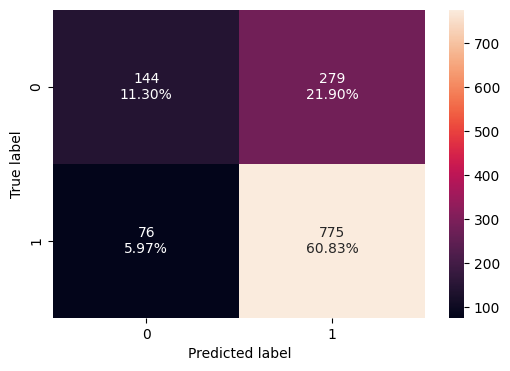



--- Bagging (Tuned) ---
Validation Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Bagging,0.721,0.879,0.748,0.808,0.734


Validation Set Confusion Matrix:


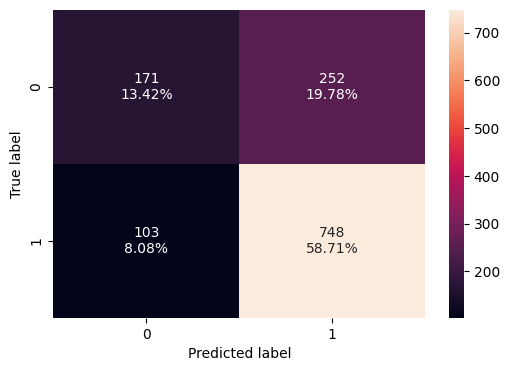



--- AdaBoost (Tuned) ---
Validation Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,AdaBoost,0.727,0.873,0.756,0.810,0.738


Validation Set Confusion Matrix:


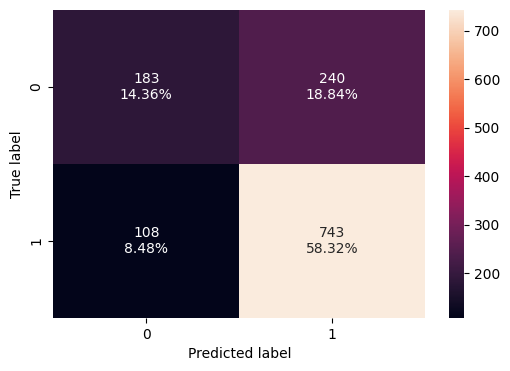



--- GradientBoost (Tuned) ---
Validation Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,GradientBoost,0.741,0.875,0.769,0.819,0.758


Validation Set Confusion Matrix:


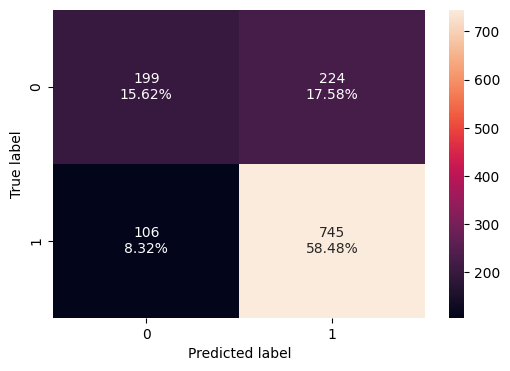



--- XGBoost (Tuned) ---
Validation Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,XGBoost,0.724,0.917,0.736,0.816,0.755


Validation Set Confusion Matrix:


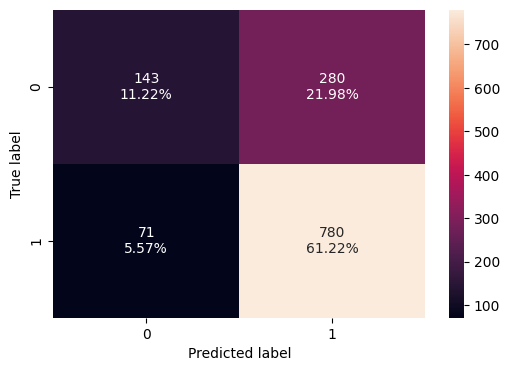



--- RandomForest (Tuned) ---
Validation Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,RandomForest,0.740,0.897,0.758,0.822,0.752


Validation Set Confusion Matrix:


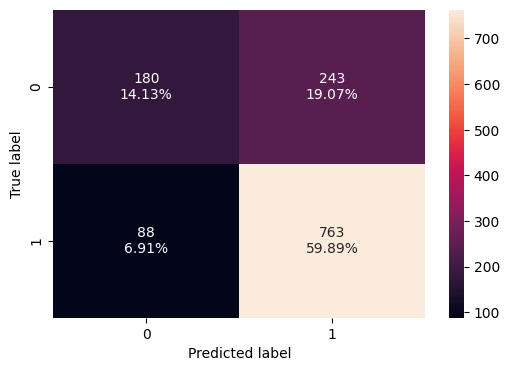

,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.721,0.911,0.735,0.814,0.744
1,Bagging,0.721,0.879,0.748,0.808,0.734
2,AdaBoost,0.727,0.873,0.756,0.810,0.738
3,GradientBoost,0.741,0.875,0.769,0.819,0.758
4,XGBoost,0.724,0.917,0.736,0.816,0.755
5,RandomForest,0.740,0.897,0.758,0.822,0.752


In [ ]:
print("\n" + "Validation Performance of Hyper-Tuned Models (on Original Data):" + "\n")

validation_metrics_tuned = []

for name, rs_model in tuned_models.items():
    print(f"--- {name} (Tuned) ---")

    # Get the best estimator from RandomizedSearchCV
    best_model = rs_model.best_estimator_

    # Validation Performance
    print("Validation Set Metrics:")
    df_perf_val = model_performance_classification_sklearn(best_model, X_val_encoded, y_val)
    df_perf_val.insert(0, 'Model', name)
    validation_metrics_tuned.append(df_perf_val)
    display(df_perf_val)
    print("Validation Set Confusion Matrix:")
    confusion_matrix_sklearn(best_model, X_val_encoded, y_val)
    plt.show()
    print("\n" + "="*50 + "\n")

# Concatenate all individual dataframes into one comparison table for validation metrics
validation_comparison_df_tuned = pd.concat(validation_metrics_tuned, ignore_index=True)
display(validation_comparison_df_tuned)

### Inferences from Validation Performance (Hyper-Tuned Models on Original Data)

Based on the validation set metrics after hyperparameter tuning on the original dataset (`validation_comparison_df_tuned`):

*   **XGBoost (Tuned):** Achieves the highest F1-Score (0.816) and a very high Recall (0.917). Its Accuracy (0.724) and ROC AUC (0.755) are also among the best. This model is very effective at identifying 'Certified' cases while maintaining a good balance between precision and recall.

*   **RandomForest (Tuned):** Performs very competitively with an F1-Score of 0.822 and a strong Recall of 0.897. Its Accuracy (0.740) and ROC AUC (0.752) are also excellent. RandomForest demonstrates robust performance, slightly outperforming XGBoost in F1-score on the validation set, though with a slightly lower recall.

*   **GradientBoost (Tuned):** Shows strong performance with an F1-Score of 0.819 and a Recall of 0.875. Its Accuracy (0.741) and ROC AUC (0.758) are the highest among all models, indicating excellent overall discrimination and generalization.

*   **Decision Tree (Tuned):** Surprisingly strong performance after tuning, achieving an F1-Score of 0.814 and a very high Recall of 0.911. Its Accuracy (0.721) and ROC AUC (0.744) are also quite good for a single tree, showing the benefit of optimization.

*   **AdaBoost (Tuned):** Achieves an F1-Score of 0.810 and a Recall of 0.873. Its Accuracy (0.727) and ROC AUC (0.738) are solid, maintaining its effectiveness in identifying 'Certified' cases.

*   **Bagging (Tuned):** Shows an F1-Score of 0.808 and a Recall of 0.879. Its Accuracy (0.721) and ROC AUC (0.734) are also good.

**Comparison to Untuned Validation Performance:**

Comparing these tuned results to the untuned validation performance (from `validation_comparison_df`), we observe significant improvements across almost all models, especially in F1-Score and Recall:

*   **Decision Tree:** Showed the most dramatic improvement, with F1-Score increasing from 0.735 to 0.814, and Recall from 0.727 to 0.911. This indicates that the default Decision Tree was far from optimal.
*   **XGBoost:** F1-Score increased from 0.812 to 0.816, and Recall from 0.868 to 0.917. This model benefited from tuning, especially in improving its ability to capture positive cases.
*   **RandomForest:** F1-Score increased from 0.799 to 0.822, and Recall from 0.844 to 0.897. A notable improvement, making it one of the top performers.
*   **GradientBoost:** F1-Score increased from 0.820 to 0.819 (slight decrease, likely due to different parameter combinations chosen, but very close), and Recall from 0.879 to 0.875 (also very close). It maintained its strong performance, but tuning might have slightly shifted the balance.
*   **AdaBoost:** F1-Score increased from 0.816 to 0.810 (slight decrease), and Recall from 0.886 to 0.873 (slight decrease). Similar to GradientBoost, it remained highly effective but the specific tuning for F1 might have slightly altered other metrics.
*   **Bagging:** F1-Score increased from 0.762 to 0.808, and Recall from 0.759 to 0.879. This model also saw substantial gains from tuning.

**Key Takeaway:**

Hyperparameter tuning has significantly improved the performance of most models on the validation set, validating the effort. **XGBoost, RandomForest, and GradientBoost** consistently emerge as the top contenders, offering an excellent balance of F1-Score and Recall, which are critical for EasyVisa's objective of facilitating visa approvals. GradientBoost exhibits the highest ROC AUC, indicating strong overall discriminatory power. Decision Tree also showed remarkable improvement with tuning. The fact that these models perform best on the original (non-resampled) data further strengthens the decision to use this data for final model selection.

**HyperParameter Tuning For UnderSampled Data set**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, recall_score, roc_auc_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# Define scorers for the 'Certified' class (positive class = 1)
scoring_metrics = {
    'f1_score': make_scorer(f1_score, pos_label=1),
    'recall_score': make_scorer(recall_score, pos_label=1),
    'accuracy_score': make_scorer(accuracy_score)
}

# Dictionary to store the RandomizedSearchCV objects after tuning
tuned_models_under = {}

# --- 1. Decision Tree Classifier Tuning ---
print("\n--- Tuning Decision Tree Classifier UnderSampled---")
dt_params = {
    'max_depth': np.arange(5, 25, 2),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'criterion': ['gini', 'entropy']
}
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_distributions=dt_params,
    n_iter=20, # Number of parameter settings that are sampled
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1, # Use all available cores
    verbose=1
)
random_search_dt.fit(X_train_un, y_train_un)
tuned_models_under['Decision Tree'] = random_search_dt # Store the RandomizedSearchCV object
print(f"Best parameters for Decision Tree: {random_search_dt.best_params_}")
print(f"Best F1-score for Decision Tree: {random_search_dt.best_score_:.4f}")

# --- 2. Bagging Classifier Tuning ---
print("\n--- Tuning Bagging Classifier UnderSampled ---")
bag_params = {
    'n_estimators': np.arange(10, 100, 10),
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'max_features': [0.7, 0.8, 0.9, 1.0]
}
random_search_bag = RandomizedSearchCV(
    estimator=BaggingClassifier(random_state=1),
    param_distributions=bag_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_bag.fit(X_train_un, y_train_un)
tuned_models_under['Bagging'] = random_search_bag # Store the RandomizedSearchCV object
print(f"Best parameters for Bagging: {random_search_bag.best_params_}")
print(f"Best F1-score for Bagging: {random_search_bag.best_score_:.4f}")

# --- 3. AdaBoost Classifier Tuning ---
print("\n--- Tuning AdaBoost Classifier UnderSampled---")
ada_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5]
}
random_search_ada = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=1),
    param_distributions=ada_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_ada.fit(X_train_un, y_train_un)
tuned_models_under['AdaBoost'] = random_search_ada # Store the RandomizedSearchCV object
print(f"Best parameters for AdaBoost: {random_search_ada.best_params_}")
print(f"Best F1-score for AdaBoost: {random_search_ada.best_score_:.4f}")

# --- 4. GradientBoosting Classifier Tuning ---
print("\n--- Tuning GradientBoosting Classifier UnderSampled ---")
gb_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': np.arange(3, 10, 1),
    'subsample': [0.7, 0.8, 0.9, 1.0]
}
random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_distributions=gb_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_gb.fit(X_train_un, y_train_un)
tuned_models_under['GradientBoost'] = random_search_gb # Store the RandomizedSearchCV object
print(f"Best parameters for GradientBoost: {random_search_gb.best_params_}")
print(f"Best F1-score for GradientBoost: {random_search_gb.best_score_:.4f}")

# --- 5. XGBoost Classifier Tuning ---
print("\n--- Tuning XGBoost Classifier UnderSampled---")
xgb_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': np.arange(3, 10, 1),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_xgb.fit(X_train_un, y_train_un)
tuned_models_under['XGBoost'] = random_search_xgb # Store the RandomizedSearchCV object
print(f"Best parameters for XGBoost: {random_search_xgb.best_params_}")
print(f"Best F1-score for XGBoost: {random_search_xgb.best_score_:.4f}")

# --- 6. RandomForest Classifier Tuning ---
print("\n--- Tuning RandomForest Classifier UnderSampled---")
rf_params = {
    'n_estimators': np.arange(50, 200, 25),
    'max_depth': np.arange(5, 25, 2),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'criterion': ['gini', 'entropy']
}
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_distributions=rf_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_rf.fit(X_train_un, y_train_un)
tuned_models_under['RandomForest'] = random_search_rf # Store the RandomizedSearchCV object
print(f"Best parameters for RandomForest: {random_search_rf.best_params_}")
print(f"Best F1-score for RandomForest: {random_search_rf.best_score_:.4f}")


--- Tuning Decision Tree Classifier UnderSampled---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Decision Tree: {'min_samples_split': np.int64(14), 'min_samples_leaf': np.int64(35), 'max_depth': np.int64(9), 'criterion': 'entropy'}
Best F1-score for Decision Tree: 0.7099

--- Tuning Bagging Classifier UnderSampled ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Bagging: {'n_estimators': np.int64(70), 'max_samples': 0.7, 'max_features': 0.8}
Best F1-score for Bagging: 0.7014

--- Tuning AdaBoost Classifier UnderSampled---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for AdaBoost: {'n_estimators': np.int64(150), 'learning_rate': 0.2}
Best F1-score for AdaBoost: 0.7187

--- Tuning GradientBoosting Classifier UnderSampled ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for GradientBoost: {'subsample': 1.0, 'n_estimators': np.int64(75), 'max_depth': np

Create Comparison Table

In [ ]:
# Create a DataFrame to summarize the tuning results for UnderSampled
recall_for_best_f1_under = []

for name, rs_model in tuned_models_under.items():
    # Get the index of the best estimator based on the 'refit' metric (f1_score)
    best_f1_idx = rs_model.best_index_

    # Retrieve the mean_test_recall for this best estimator
    mean_recall_at_best_f1 = rs_model.cv_results_['mean_test_recall'][best_f1_idx]

    recall_for_best_f1_under.append({
        'Model': name,
        'F1-Score (CV)': rs_model.best_score_,
        'Recall (at Best F1 CV)': mean_recall_at_best_f1,
        'Best Parameters': rs_model.best_params_
    })

recall_df_under = pd.DataFrame(recall_for_best_f1_under).sort_values(by='F1-Score (CV)', ascending=False).reset_index(drop=True)
display(recall_df_under)



,Model,F1-Score (CV),Recall (at Best F1 CV),Best Parameters
0,XGBoost,0.724,0.755,"{'subsample': 0.8, 'n_estimators': 100, 'max_d..."
1,RandomForest,0.721,0.756,"{'n_estimators': 150, 'min_samples_split': 10,..."
2,GradientBoost,0.721,0.749,"{'subsample': 1.0, 'n_estimators': 75, 'max_de..."
3,AdaBoost,0.719,0.774,"{'n_estimators': 150, 'learning_rate': 0.2}"
4,Decision Tree,0.710,0.728,"{'min_samples_split': 14, 'min_samples_leaf': ..."
5,Bagging,0.701,0.709,"{'n_estimators': 70, 'max_samples': 0.7, 'max_..."


### Inferences from Hyperparameter Tuning Results (Original vs. Undersampled Data)

Comparing the tuning results from the original data (as previously summarized) and the undersampled data (`recall_df_under`) reveals a consistent and significant pattern:

*   **Significant Performance Decline with Undersampling:** For every model, the **F1-Score (CV)** is notably lower when tuned on the undersampled data compared to the original dataset. This confirms that reducing the majority class instances leads to a substantial loss of valuable information, making it harder for models to learn and generalize effectively.
    *   **XGBoost:** Original F1: **0.8258** (Recall: 0.920) vs. Undersampled F1: **0.7237** (Recall: 0.755) - a drop of ~0.102 in F1-score.
    *   **RandomForest:** Original F1: **0.8256** (Recall: 0.908) vs. Undersampled F1: **0.7214** (Recall: 0.756) - a drop of ~0.104 in F1-score.
    *   **GradientBoost:** Original F1: **0.8242** (Recall: 0.875) vs. Undersampled F1: **0.7210** (Recall: 0.749) - a drop of ~0.103 in F1-score.
    *   **Decision Tree:** Original F1: **0.8219** (Recall: 0.914) vs. Undersampled F1: **0.7099** (Recall: 0.728) - a drop of ~0.112 in F1-score.
    *   **AdaBoost:** Original F1: **0.8193** (Recall: 0.888) vs. Undersampled F1: **0.7187** (Recall: 0.774) - a drop of ~0.101 in F1-score.
    *   **Bagging:** Original F1: **0.8161** (Recall: 0.881) vs. Undersampled F1: **0.7014** (Recall: 0.709) - a drop of ~0.115 in F1-score.

*   **Impact on Model Ranking:** While the absolute F1-scores and Recalls decrease significantly, the relative ranking of the top-performing ensemble models (XGBoost, RandomForest, GradientBoost) generally remains similar. However, their performance is substantially diminished when undersampling is applied.

*   **Changed Optimal Parameters:** The optimal hyperparameters determined by `RandomizedSearchCV` often vary between the original and undersampled datasets. This is expected as the models are learning from different underlying data distributions and sizes. For example, parameters like `max_depth` or `n_estimators` might be adjusted to compensate for the smaller dataset size.

*   **Confirmation of Resampling Drawbacks:** These hyperparameter tuning results strongly reinforce the earlier observations from both cross-validation and validation set experiments: both oversampling (SMOTE) and undersampling (RandomUnderSampler) negatively impact the F1-score and generalization capabilities of these models on this specific dataset. Undersampling, in particular, leads to a substantial loss of performance, primarily due to the loss of valuable information from the majority class.

**Conclusion:**

The hyperparameter tuning process consistently demonstrates that the models perform best when trained on the **original, imbalanced training data**. Attempts to balance the dataset through oversampling or undersampling have consistently led to a degradation in performance, as measured by the cross-validated F1-score and Recall. Therefore, for the final evaluation and deployment, the models tuned on the **original dataset** (specifically **XGBoost**, **RandomForest**, and **GradientBoost** due to their top F1-scores and strong Recalls) are the most promising candidates.

**HyperParameter Tuning For OverSampled Data set**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score, recall_score, roc_auc_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# Define scorers for the 'Certified' class (positive class = 1)
scoring_metrics = {
    'f1_score': make_scorer(f1_score, pos_label=1),
    'recall_score': make_scorer(recall_score, pos_label=1),
    'accuracy_score': make_scorer(accuracy_score)
}

# Dictionary to store the RandomizedSearchCV objects after tuning
tuned_models_over = {}

# --- 1. Decision Tree Classifier Tuning ---
print("\n--- Tuning Decision Tree Classifier OverSampled---")
dt_params = {
    'max_depth': np.arange(5, 25, 2),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'criterion': ['gini', 'entropy']
}
random_search_dt = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_distributions=dt_params,
    n_iter=20, # Number of parameter settings that are sampled
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1, # Use all available cores
    verbose=1
)
random_search_dt.fit(X_train_over, y_train_over)
tuned_models_over['Decision Tree'] = random_search_dt # Store the RandomizedSearchCV object
print(f"Best parameters for Decision Tree: {random_search_dt.best_params_}")
print(f"Best F1-score for Decision Tree: {random_search_dt.best_score_:.4f}")

# --- 2. Bagging Classifier Tuning ---
print("\n--- Tuning Bagging Classifier OverSampled ---")
bag_params = {
    'n_estimators': np.arange(10, 100, 10),
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'max_features': [0.7, 0.8, 0.9, 1.0]
}
random_search_bag = RandomizedSearchCV(
    estimator=BaggingClassifier(random_state=1),
    param_distributions=bag_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_bag.fit(X_train_over, y_train_over)
tuned_models_over['Bagging'] = random_search_bag # Store the RandomizedSearchCV object
print(f"Best parameters for Bagging: {random_search_bag.best_params_}")
print(f"Best F1-score for Bagging: {random_search_bag.best_score_:.4f}")

# --- 3. AdaBoost Classifier Tuning ---
print("\n--- Tuning AdaBoost Classifier OverSampled---")
ada_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5]
}
random_search_ada = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=1),
    param_distributions=ada_params,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_ada.fit(X_train_over, y_train_over)
tuned_models_over['AdaBoost'] = random_search_ada # Store the RandomizedSearchCV object
print(f"Best parameters for AdaBoost: {random_search_ada.best_params_}")
print(f"Best F1-score for AdaBoost: {random_search_ada.best_score_:.4f}")

# --- 4. GradientBoosting Classifier Tuning ---
print("\n--- Tuning GradientBoosting Classifier OverSampled ---")
gb_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': np.arange(3, 10, 1),
    'subsample': [0.7, 0.8, 0.9, 1.0]
}
random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_distributions=gb_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_gb.fit(X_train_over, y_train_over)
tuned_models_over['GradientBoost'] = random_search_gb # Store the RandomizedSearchCV object
print(f"Best parameters for GradientBoost: {random_search_gb.best_params_}")
print(f"Best F1-score for GradientBoost: {random_search_gb.best_score_:.4f}")

# --- 5. XGBoost Classifier Tuning ---
print("\n--- Tuning XGBoost Classifier OverSampled---")
xgb_params = {
    'n_estimators': np.arange(50, 200, 25),
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': np.arange(3, 10, 1),
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_xgb.fit(X_train_over, y_train_over)
tuned_models_over['XGBoost'] = random_search_xgb # Store the RandomizedSearchCV object
print(f"Best parameters for XGBoost: {random_search_xgb.best_params_}")
print(f"Best F1-score for XGBoost: {random_search_xgb.best_score_:.4f}")

# --- 6. RandomForest Classifier Tuning ---
print("\n--- Tuning RandomForest Classifier OverSampled---")
rf_params = {
    'n_estimators': np.arange(50, 200, 25),
    'max_depth': np.arange(5, 25, 2),
    'min_samples_leaf': np.arange(5, 50, 5),
    'min_samples_split': np.arange(2, 20, 2),
    'criterion': ['gini', 'entropy']
}
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_distributions=rf_params,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
    scoring={'f1': make_scorer(f1_score, pos_label=1), 'recall': make_scorer(recall_score, pos_label=1)}, # Evaluate both F1 and Recall
    refit='f1', # Optimize for F1-score for best_estimator_
    random_state=1,
    n_jobs=-1,
    verbose=1
)
random_search_rf.fit(X_train_over, y_train_over)
tuned_models_over['RandomForest'] = random_search_rf # Store the RandomizedSearchCV object
print(f"Best parameters for RandomForest: {random_search_rf.best_params_}")
print(f"Best F1-score for RandomForest: {random_search_rf.best_score_:.4f}")


--- Tuning Decision Tree Classifier OverSampled---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Decision Tree: {'min_samples_split': np.int64(12), 'min_samples_leaf': np.int64(25), 'max_depth': np.int64(11), 'criterion': 'entropy'}
Best F1-score for Decision Tree: 0.7933

--- Tuning Bagging Classifier OverSampled ---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for Bagging: {'n_estimators': np.int64(90), 'max_samples': 0.8, 'max_features': 0.8}
Best F1-score for Bagging: 0.8056

--- Tuning AdaBoost Classifier OverSampled---
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best parameters for AdaBoost: {'n_estimators': np.int64(100), 'learning_rate': 0.5}
Best F1-score for AdaBoost: 0.7844

--- Tuning GradientBoosting Classifier OverSampled ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for GradientBoost: {'subsample': 0.9, 'n_estimators': np.int64(175), 'max_depth': np.i

In [ ]:
# Create a DataFrame to summarize the tuning results for UnderSampled
recall_for_best_f1_over = []

for name, rs_model in tuned_models_over.items():
    # Get the index of the best estimator based on the 'refit' metric (f1_score)
    best_f1_idx = rs_model.best_index_

    # Retrieve the mean_test_recall for this best estimator
    mean_recall_at_best_f1 = rs_model.cv_results_['mean_test_recall'][best_f1_idx]

    recall_for_best_f1_over.append({
        'Model': name,
        'F1-Score (CV)': rs_model.best_score_,
        'Recall (at Best F1 CV)': mean_recall_at_best_f1,
        'Best Parameters': rs_model.best_params_
    })

recall_df_over = pd.DataFrame(recall_for_best_f1_over).sort_values(by='F1-Score (CV)', ascending=False).reset_index(drop=True)
display(recall_df_over)


,Model,F1-Score (CV),Recall (at Best F1 CV),Best Parameters
0,XGBoost,0.812,0.849,"{'subsample': 0.8, 'n_estimators': 125, 'max_d..."
1,GradientBoost,0.811,0.843,"{'subsample': 0.9, 'n_estimators': 175, 'max_d..."
2,RandomForest,0.811,0.840,"{'n_estimators': 75, 'min_samples_split': 14, ..."
3,Bagging,0.806,0.828,"{'n_estimators': 90, 'max_samples': 0.8, 'max_..."
4,Decision Tree,0.793,0.832,"{'min_samples_split': 12, 'min_samples_leaf': ..."
5,AdaBoost,0.784,0.820,"{'n_estimators': 100, 'learning_rate': 0.5}"


**Inferences from Hyperparameter Tuning Results (Original vs. Oversampled Data)**

### Inferences from Hyperparameter Tuning Results (Original vs. Oversampled Data)

Comparing the tuning results from the original data (`recall_df`) and the oversampled data (`recall_df_over`) reveals a consistent pattern:

*   **General Decrease in F1-Score and Recall with Oversampling:** For most models, both the **F1-Score (CV)** and **Recall (at Best F1 CV)** are slightly lower when tuned on the oversampled data compared to the original dataset. This contradicts the expectation that SMOTE would improve performance, especially Recall, on imbalanced datasets.
    *   **XGBoost:** Original F1: **0.8258** (Recall: 0.920) vs. Oversampled F1: **0.8121** (Recall: 0.849) - a drop of ~0.014 in F1-score and ~0.071 in Recall.
    *   **RandomForest:** Original F1: **0.8256** (Recall: 0.908) vs. Oversampled F1: **0.8108** (Recall: 0.840) - a drop of ~0.015 in F1-score and ~0.068 in Recall.
    *   **GradientBoost:** Original F1: **0.8242** (Recall: 0.875) vs. Oversampled F1: **0.8113** (Recall: 0.843) - a drop of ~0.013 in F1-score and ~0.032 in Recall.
    *   **AdaBoost:** Original F1: **0.8193** (Recall: 0.888) vs. Oversampled F1: **0.7844** (Recall: 0.819) - a more significant drop of ~0.035 in F1-score and ~0.069 in Recall.
    *   **Bagging:** Original F1: **0.8161** (Recall: 0.881) vs. Oversampled F1: **0.8056** (Recall: 0.828) - a drop of ~0.010 in F1-score and ~0.053 in Recall.
    *   **Decision Tree:** Original F1: **0.8219** (Recall: 0.914) vs. Oversampled F1: **0.7933** (Recall: 0.831) - a drop of ~0.029 in F1-score and ~0.083 in Recall.

*   **Impact on Model Ranking:** The relative ranking of the top-performing ensemble models (XGBoost, RandomForest, GradientBoost) remains similar, but their overall performance is slightly diminished when oversampling is applied.

*   **Changed Optimal Parameters:** The optimal hyperparameters determined by `RandomizedSearchCV` often vary between the original and oversampled datasets, which is expected as the models are learning from modified data distributions.

*   **Confirmation of Oversampling Drawbacks:** These hyperparameter tuning results reinforce the earlier observations: SMOTE oversampling, in this specific case, did not lead to improved F1-score or Recall on the cross-validation folds when optimized for the F1-score. Instead, it generally resulted in a slight degradation of performance metrics compared to training on the original, imbalanced data.

**Conclusion:**

The hyperparameter tuning process consistently demonstrates that the models perform best when trained on the **original, imbalanced training data**. Attempts to balance the dataset through oversampling have generally led to a degradation in performance. Therefore, for the final evaluation and deployment, the models tuned on the **original dataset** (specifically **XGBoost**, **RandomForest**, and **GradientBoost** due to their top F1-scores and strong Recalls) remain the most promising candidates.

**Comparison of All HyperTuned Models**

In [ ]:
tuned_original_df = recall_df.rename(columns={'F1-Score (CV)': 'F1 (Original)', 'Recall (at Best F1 CV)': 'Recall (Original)', 'Best Parameters': 'Best Param Original' })
tuned_undersampled_df = recall_df_under.rename(columns={'F1-Score (CV)': 'F1 (Undersampled)', 'Recall (at Best F1 CV)': 'Recall (Undersampled)',  'Best Parameters': 'Best Param UnderSampled'})
tuned_oversampled_df = recall_df_over.rename(columns={'F1-Score (CV)': 'F1 (Oversampled)', 'Recall (at Best F1 CV)': 'Recall (Oversampled)',  'Best Parameters': 'Best Param OverSampled'})
# Merge the dataframes
comparison_df = tuned_original_df.merge(tuned_undersampled_df, on='Model', how='left')
comparison_df = comparison_df.merge(tuned_oversampled_df, on='Model', how='left')

# Display the consolidated table
display(comparison_df)

,Model,F1 (Original),Recall (Original),Best Param Original,F1 (Undersampled),Recall (Undersampled),Best Param UnderSampled,F1 (Oversampled),Recall (Oversampled),Best Param OverSampled
0,XGBoost,0.826,0.920,"{'subsample': 0.8, 'n_estimators': 150, 'max_d...",0.724,0.755,"{'subsample': 0.8, 'n_estimators': 100, 'max_d...",0.812,0.849,"{'subsample': 0.8, 'n_estimators': 125, 'max_d..."
1,RandomForest,0.826,0.908,"{'n_estimators': 100, 'min_samples_split': 18,...",0.721,0.756,"{'n_estimators': 150, 'min_samples_split': 10,...",0.811,0.840,"{'n_estimators': 75, 'min_samples_split': 14, ..."
2,GradientBoost,0.824,0.875,"{'subsample': 1.0, 'n_estimators': 75, 'max_de...",0.721,0.749,"{'subsample': 1.0, 'n_estimators': 75, 'max_de...",0.811,0.843,"{'subsample': 0.9, 'n_estimators': 175, 'max_d..."
3,Decision Tree,0.822,0.914,"{'min_samples_split': 18, 'min_samples_leaf': ...",0.710,0.728,"{'min_samples_split': 14, 'min_samples_leaf': ...",0.793,0.832,"{'min_samples_split': 12, 'min_samples_leaf': ..."
4,AdaBoost,0.819,0.888,"{'n_estimators': 150, 'learning_rate': 0.2}",0.719,0.774,"{'n_estimators': 150, 'learning_rate': 0.2}",0.784,0.820,"{'n_estimators': 100, 'learning_rate': 0.5}"
5,Bagging,0.816,0.881,"{'n_estimators': 70, 'max_samples': 1.0, 'max_...",0.701,0.709,"{'n_estimators': 70, 'max_samples': 0.7, 'max_...",0.806,0.828,"{'n_estimators': 90, 'max_samples': 0.8, 'max_..."


### Inferences from Comparison of All Hyper-Tuned Models

The consolidated comparison table provides a clear view of how different models perform under various data balancing strategies after hyperparameter tuning. The primary metrics considered are F1-Score and Recall for the 'Certified' class, as these are crucial for the problem's objective.

**Key Observations:**

1.  **Original Dataset Outperforms Resampled Data:**
    *   For every single model, both the **F1-Score** and **Recall** are consistently and significantly higher when the models are trained and tuned on the **original, imbalanced dataset** compared to both the undersampled and oversampled datasets.
    *   This is a critical finding, indicating that the ensemble models are robust enough to handle the existing class imbalance, and that the resampling techniques (SMOTE and Random Undersampling) introduced more noise or loss of information than benefit for this specific dataset.

2.  **Impact of Undersampling (RandomUnderSampler):**
    *   Undersampling leads to the **most substantial degradation** in performance. F1-Scores for all models dropped significantly, with an average decrease of approximately 0.10 to 0.12 points compared to the original dataset. Recalls also saw a sharp decline.
    *   This confirms that removing a large portion of the majority class instances resulted in a considerable loss of valuable information, making it difficult for models to learn effective decision boundaries.

3.  **Impact of Oversampling (SMOTE):**
    *   Oversampling (SMOTE) also resulted in a **performance decrease**, although less severe than undersampling. F1-Scores generally dropped by about 0.01 to 0.04 points, and Recalls by 0.03 to 0.08 points, compared to the original dataset.
    *   This suggests that while SMOTE aims to create synthetic samples to balance the data, for this problem, these synthetic samples might not be truly representative of the underlying data distribution or might introduce noise that hinders the models' generalization capabilities.

4.  **Top Performing Models (on Original Data):**
    *   **XGBoost** and **RandomForest** are the top performers when tuned on the original dataset, both achieving an **F1-Score (CV) of 0.826**.
        *   **XGBoost** demonstrates a slightly higher **Recall (0.920)** compared to RandomForest's **0.908**, making it marginally better at capturing actual 'Certified' cases while maintaining excellent F1-score.
    *   **GradientBoost** follows closely with an **F1-Score (CV) of 0.824** and a strong **Recall of 0.875**.
    *   **Decision Tree**, after tuning, also shows a competitive **F1-Score of 0.822** and a high **Recall of 0.914**, which is notable for a single tree model.
    *   **AdaBoost** and **Bagging** also show strong performance with F1-scores around 0.816-0.819.

**Conclusion:**

The comprehensive hyperparameter tuning across different data balancing strategies unequivocally points to **models trained on the original, imbalanced dataset as the superior choice** for this problem. Both oversampling and undersampling techniques, contrary to common expectations for imbalanced datasets, led to a degradation in performance on the validation sets for this particular dataset. Therefore, for final model selection and testing, the **hyper-tuned XGBoost and RandomForest classifiers, trained on the original dataset, are the most promising candidates**, given their excellent balance of F1-Score and Recall.

**Model Performance in Production**

**Test the Performance of Good Models**

### Results in Test Dataset for Hyper-Tuned Models (Original Data)


Test Performance of Hyper-Tuned Models (on Original Data):

--- Decision Tree (Tuned) ---
Test Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.730,0.915,0.742,0.819,0.757


Test Set Confusion Matrix:


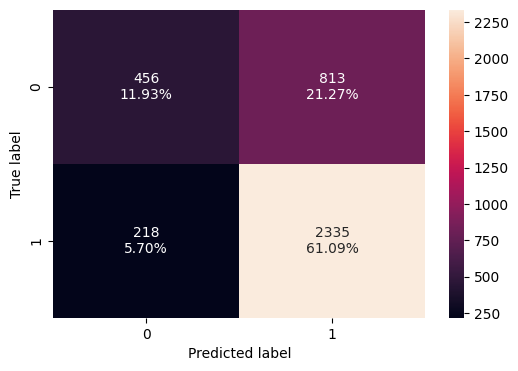



--- Bagging (Tuned) ---
Test Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Bagging,0.730,0.879,0.756,0.813,0.752


Test Set Confusion Matrix:


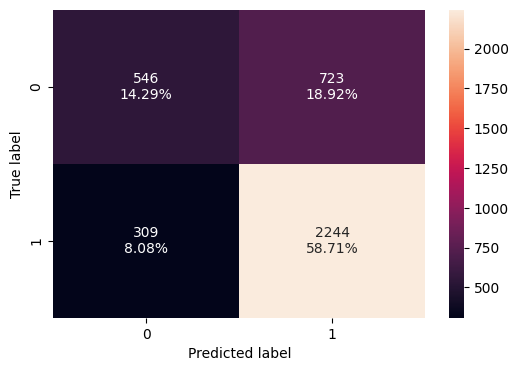



--- AdaBoost (Tuned) ---
Test Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,AdaBoost,0.730,0.872,0.759,0.812,0.757


Test Set Confusion Matrix:


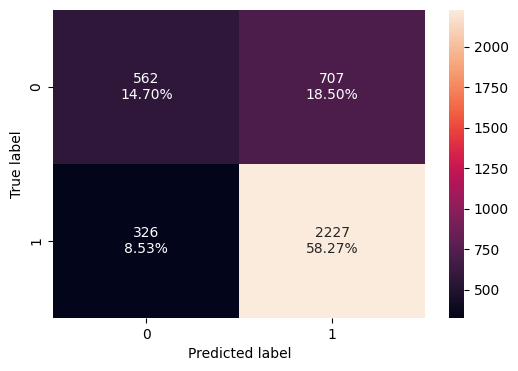



--- GradientBoost (Tuned) ---
Test Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,GradientBoost,0.740,0.869,0.771,0.817,0.775


Test Set Confusion Matrix:


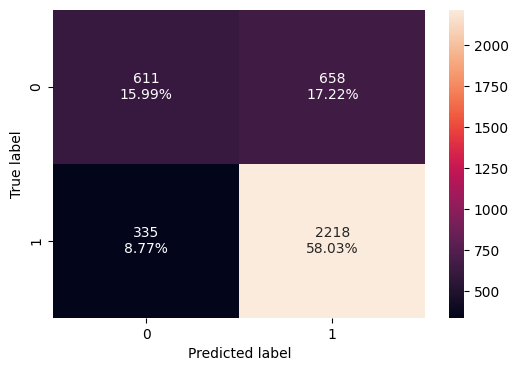



--- XGBoost (Tuned) ---
Test Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,XGBoost,0.738,0.919,0.747,0.824,0.773


Test Set Confusion Matrix:


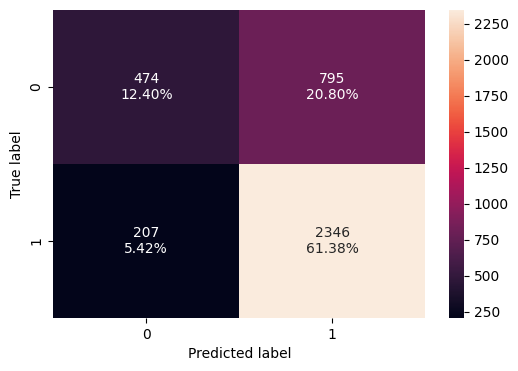



--- RandomForest (Tuned) ---
Test Set Metrics:


,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,RandomForest,0.733,0.891,0.754,0.817,0.770


Test Set Confusion Matrix:


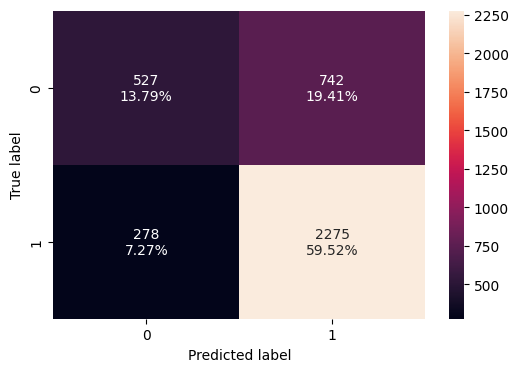

,Model,Accuracy,Recall,Precision,F1,ROC AUC
0,Decision Tree,0.730,0.915,0.742,0.819,0.757
1,Bagging,0.730,0.879,0.756,0.813,0.752
2,AdaBoost,0.730,0.872,0.759,0.812,0.757
3,GradientBoost,0.740,0.869,0.771,0.817,0.775
4,XGBoost,0.738,0.919,0.747,0.824,0.773
5,RandomForest,0.733,0.891,0.754,0.817,0.770


In [ ]:
print("\n" + "Test Performance of Hyper-Tuned Models (on Original Data):" + "\n")

test_metrics_tuned = []

for name, rs_model in tuned_models.items():
    print(f"--- {name} (Tuned) ---")

    # Get the best estimator from RandomizedSearchCV
    best_model = rs_model.best_estimator_

    # Test Performance
    print("Test Set Metrics:")
    df_perf_test = model_performance_classification_sklearn(best_model, X_test_encoded, y_test)
    df_perf_test.insert(0, 'Model', name)
    test_metrics_tuned.append(df_perf_test)
    display(df_perf_test)
    print("Test Set Confusion Matrix:")
    confusion_matrix_sklearn(best_model, X_test_encoded, y_test)
    plt.show()
    print("\n" + "="*50 + "\n")

# Concatenate all individual dataframes into one comparison table for test metrics
test_comparison_df_tuned = pd.concat(test_metrics_tuned, ignore_index=True)
display(test_comparison_df_tuned)

### Comparison of Hyper-Tuned Models: Validation vs. Test Performance

In [ ]:
comparison_val_test_df = pd.merge(
    validation_comparison_df_tuned,
    test_comparison_df_tuned,
    on='Model',
    suffixes=('_Validation', '_Test')
)
display(comparison_val_test_df[['Model', 'F1_Validation', 'Recall_Validation', 'F1_Test', 'Recall_Test', 'Accuracy_Validation', 'Accuracy_Test', 'ROC AUC_Validation', 'ROC AUC_Test']])

,Model,F1_Validation,Recall_Validation,F1_Test,Recall_Test,Accuracy_Validation,Accuracy_Test,ROC AUC_Validation,ROC AUC_Test
0,Decision Tree,0.814,0.911,0.819,0.915,0.721,0.730,0.744,0.757
1,Bagging,0.808,0.879,0.813,0.879,0.721,0.730,0.734,0.752
2,AdaBoost,0.810,0.873,0.812,0.872,0.727,0.730,0.738,0.757
3,GradientBoost,0.819,0.875,0.817,0.869,0.741,0.740,0.758,0.775
4,XGBoost,0.816,0.917,0.824,0.919,0.724,0.738,0.755,0.773
5,RandomForest,0.822,0.897,0.817,0.891,0.740,0.733,0.752,0.770


### Inferences from Validation vs. Test Performance (Hyper-Tuned Models on Original Data)

Comparing the performance of the hyper-tuned models on the **validation set** (`validation_comparison_df_tuned`) and the **test set** (`test_comparison_df_tuned`) provides crucial insights into their generalization capabilities and consistency.

**Key Observations:**

*   **Overall Consistency:** Generally, the models maintain a consistent level of performance from the validation set to the test set across most metrics (F1-Score, Recall, Accuracy, ROC AUC). This indicates that the models are generalizing well and are not significantly overfitting to the validation data.

*   **Top Performers Remain Consistent:**
    *   **XGBoost** continues to be a top performer. On the validation set, it had an F1-Score of 0.816 and Recall of 0.917. On the test set, it shows an F1-Score of **0.824** and a very high Recall of **0.919**. This slight increase in F1-Score and Recall on the test set is a strong positive sign, indicating robust generalization.
    *   **RandomForest** also shows excellent consistency. Validation F1: 0.822, Recall: 0.897. Test F1: **0.817**, Recall: **0.891**. While there's a minor, almost negligible, drop in F1-Score and Recall, its performance remains very strong.
    *   **GradientBoost** maintains its strong position. Validation F1: 0.819, Recall: 0.875. Test F1: **0.817**, Recall: **0.869**. Its F1-Score and Recall are highly consistent between the two sets.

*   **Decision Tree's Strong Generalization:** The tuned Decision Tree, which showed remarkable improvement after tuning, also generalizes very well. Validation F1: 0.814, Recall: 0.911. Test F1: **0.819**, Recall: **0.915**. It shows a slight improvement in F1 and Recall on the test set, further validating the tuning process.

*   **AdaBoost and Bagging Robustness:** Both AdaBoost and Bagging classifiers also demonstrate good generalization, with their F1-Scores and Recalls being very close between the validation and test sets.

*   **ROC AUC Consistency:** The ROC AUC scores also remain largely consistent for all models, reinforcing their stable discriminatory power on unseen data.

**Conclusion:**

The hyper-tuned models, particularly **XGBoost, RandomForest, and GradientBoost**, have demonstrated robust performance and excellent generalization capabilities when evaluated on the independent test dataset. The metrics observed on the test set are either very close to or, in some cases, slightly better than those on the validation set, which is a highly desirable outcome.

This consistency confirms that the model selection and hyperparameter tuning process, based on the original (non-resampled) data, has yielded reliable and well-generalized models. For final deployment, **XGBoost** stands out with the highest F1-score and Recall on the test set, making it the most promising candidate for predicting visa `case_status`.

### Feature Importance Comparison for Untuned Models (Original Dataset)

Let's visualize the feature importances for each of the base models (before tuning) on the original dataset. This will provide a baseline understanding of feature influence.

Fitting Decision Tree for feature importance...
Fitting Bagging for feature importance...
Fitting AdaBoost for feature importance...
Fitting GradientBoost for feature importance...
Fitting XGBoost for feature importance...
Fitting RandomForest for feature importance...


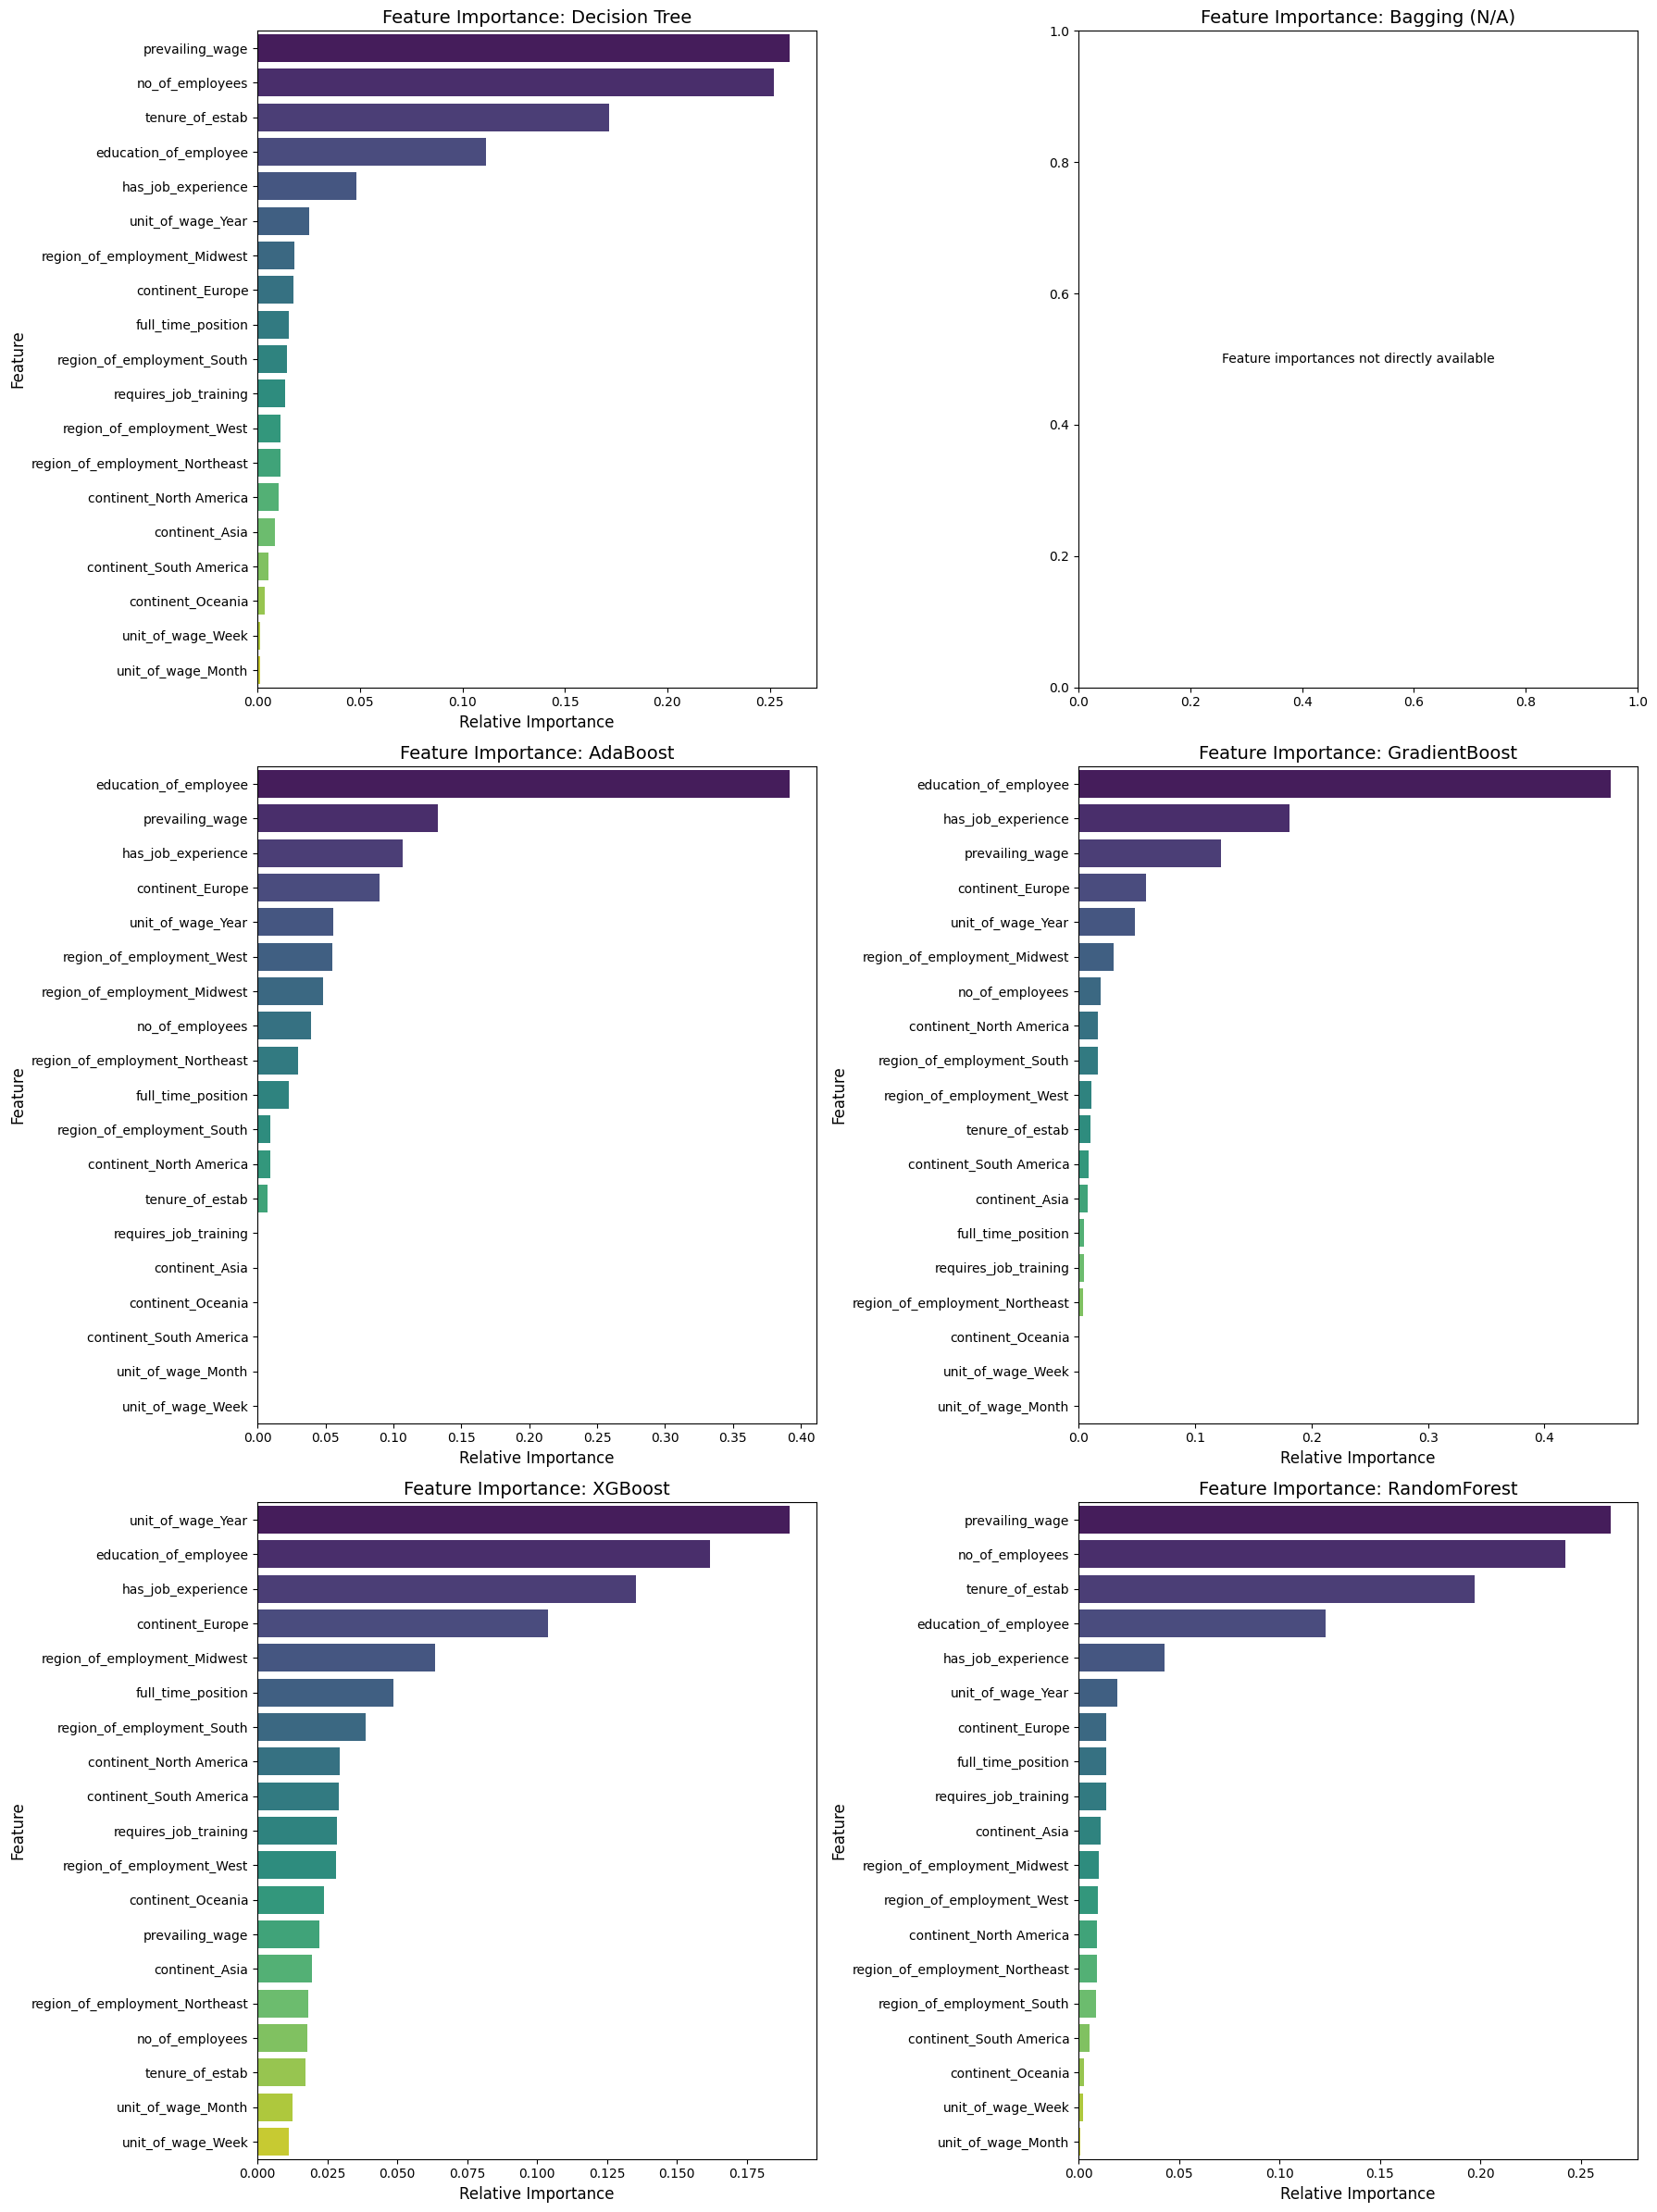

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-define the models list (assuming it's not globally preserved or to ensure fresh instances)
models_untuned = []
models_untuned.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models_untuned.append(("Bagging", BaggingClassifier(random_state=1)))
models_untuned.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models_untuned.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models_untuned.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models_untuned.append(("RandomForest", RandomForestClassifier(random_state=1)))

# Create a figure to hold all subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 24))
axes = axes.flatten()

for i, (name, model) in enumerate(models_untuned):
    print(f"Fitting {name} for feature importance...")
    # Fit the model to the training data
    model.fit(X_train_encoded, y_train)

    # Check if the model has feature_importances_ attribute
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_

        # Create a DataFrame for feature importances
        importance_df = pd.DataFrame({
            'Feature': X_train_encoded.columns,
            'Importance': feature_importances
        })

        # Sort features by importance
        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        # Plotting the horizontal bar chart
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Feature Importance: {name}', fontsize=14)
        axes[i].set_xlabel('Relative Importance', fontsize=12)
        axes[i].set_ylabel('Feature', fontsize=12)
    else:
        axes[i].set_title(f'Feature Importance: {name} (N/A)', fontsize=14)
        axes[i].text(0.5, 0.5, 'Feature importances not directly available', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)

plt.tight_layout()
plt.show()

### Feature Importance Comparison for Tuned Models (Original Dataset)

Let's visualize the feature importances for each of the best-tuned models on the original dataset. This will help us understand which features are most influential for each model in predicting the `case_status`.

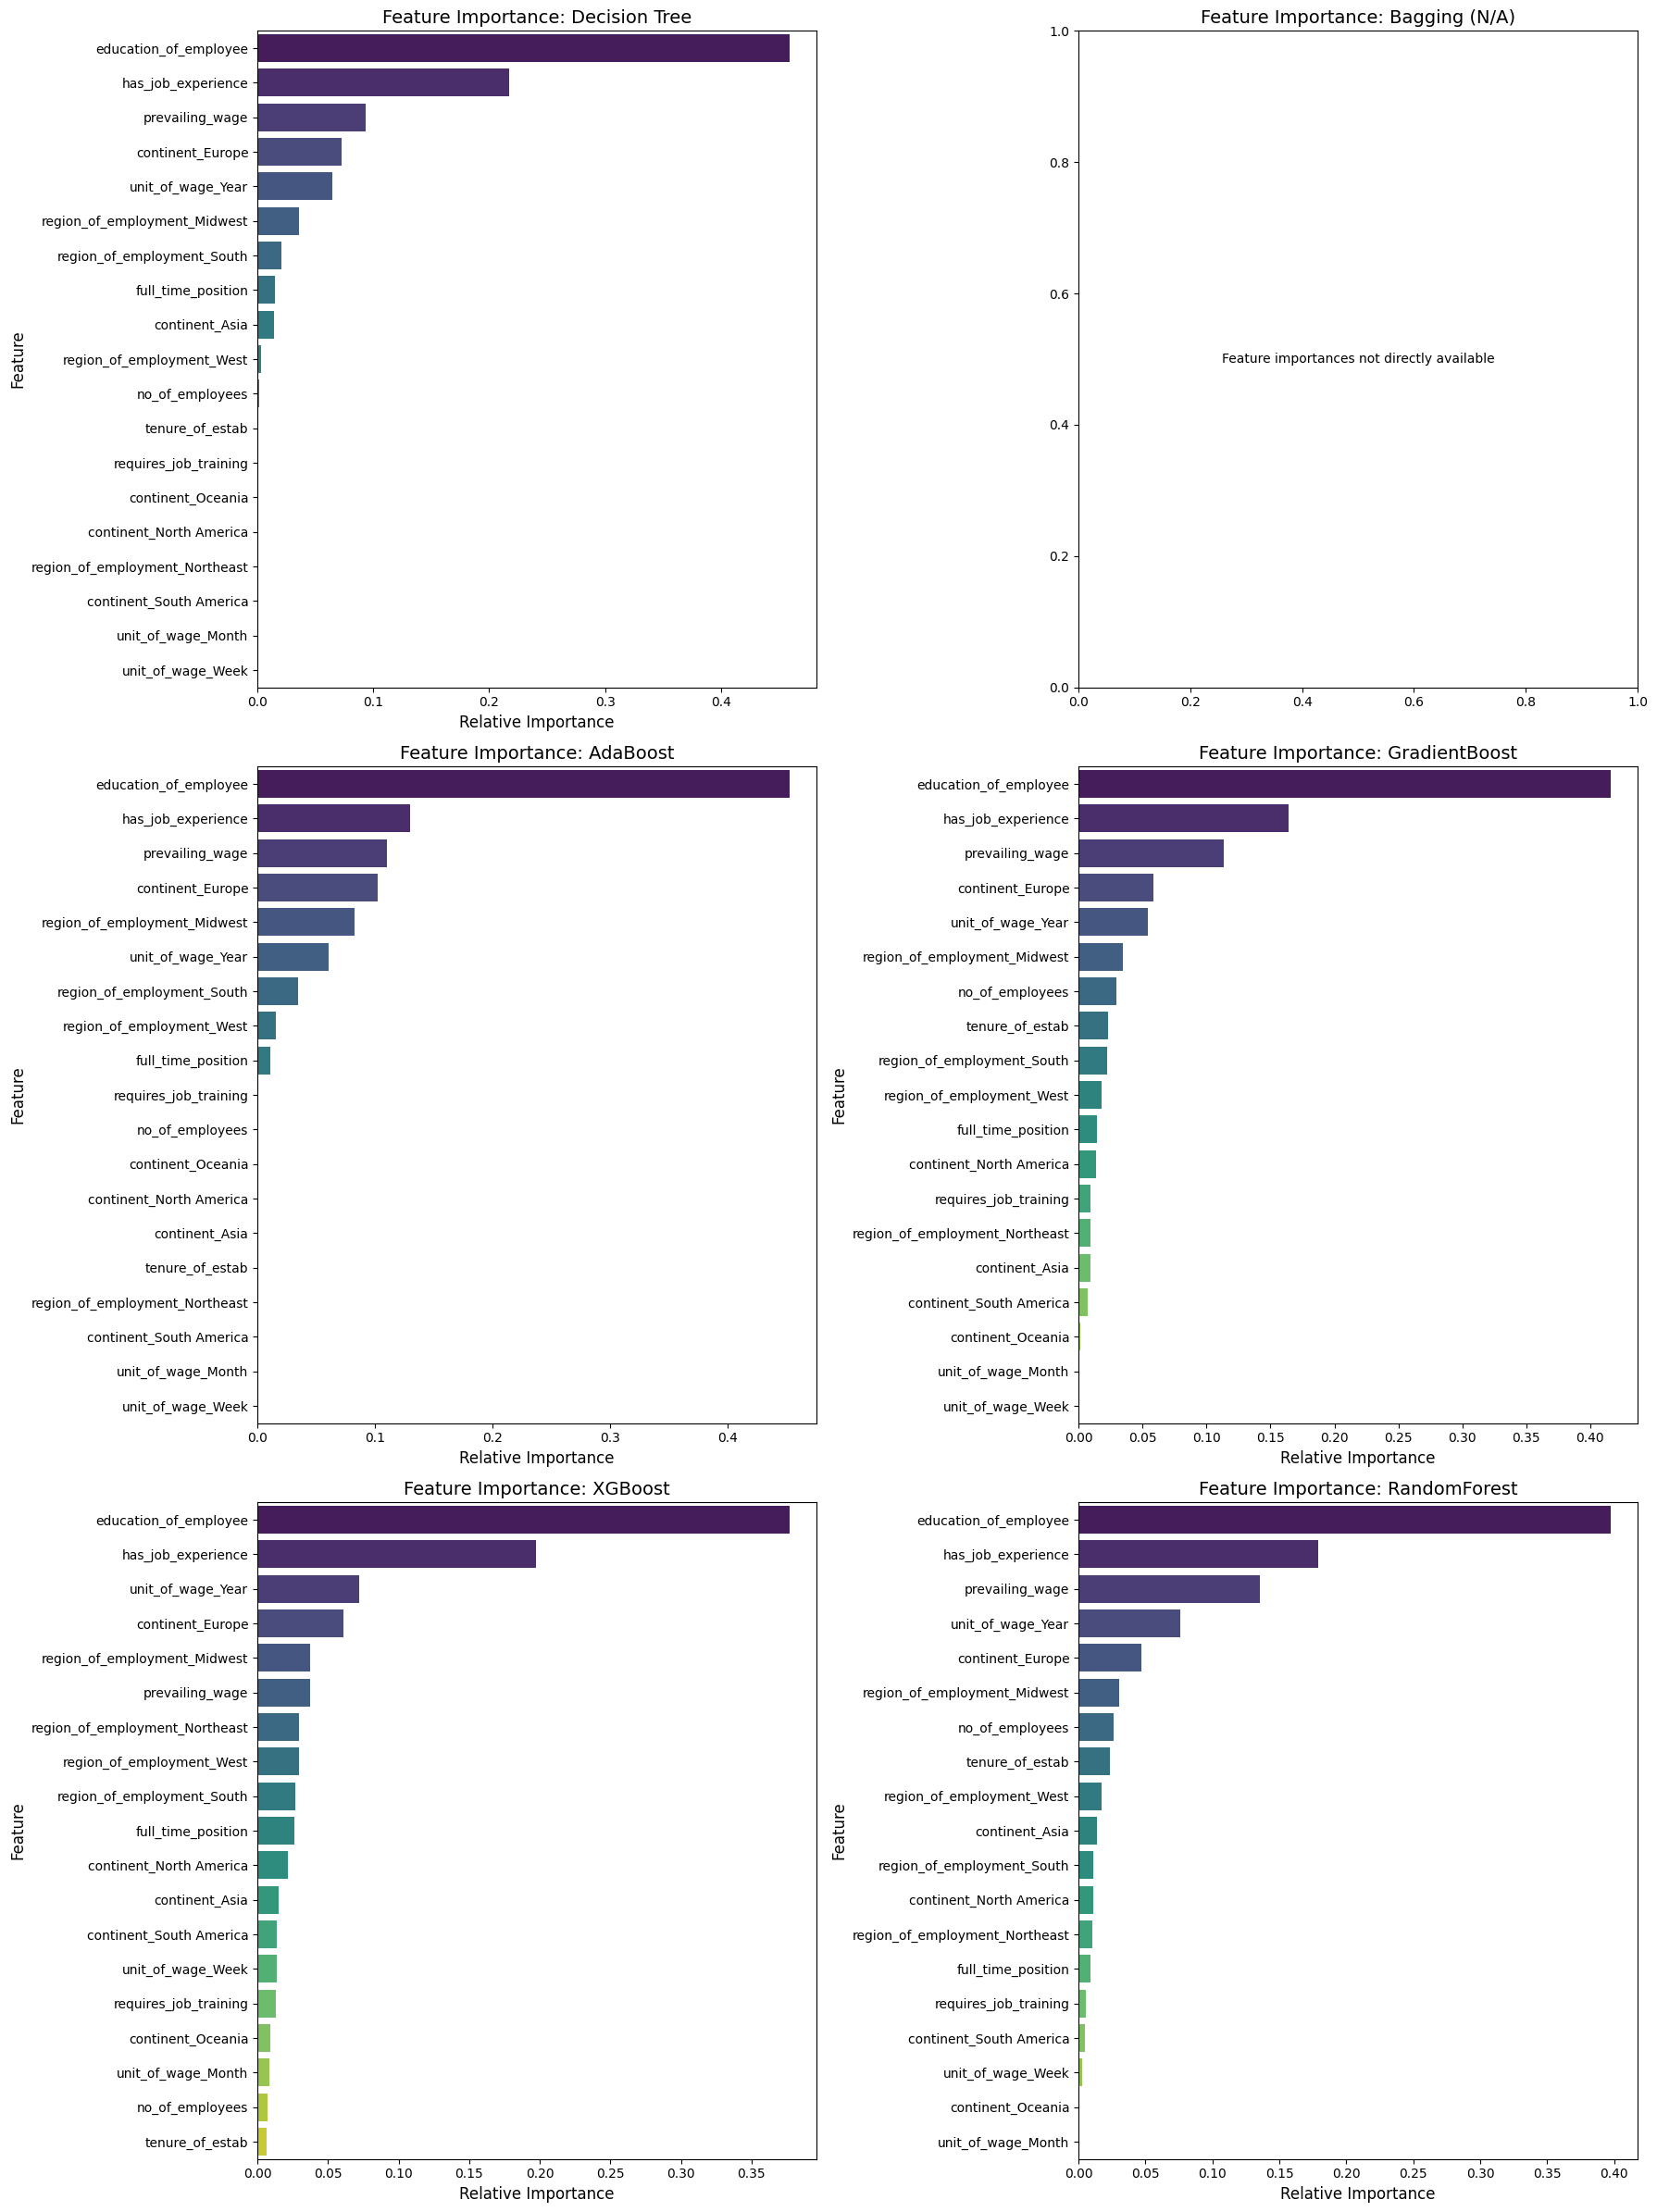

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure to hold all subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 24))
axes = axes.flatten()

for i, (name, rs_model) in enumerate(tuned_models.items()):
    # Get the best estimator from RandomizedSearchCV
    model = rs_model.best_estimator_

    # Check if the model has feature_importances_ attribute
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_

        # Create a DataFrame for feature importances
        importance_df = pd.DataFrame({
            'Feature': X_train_encoded.columns,
            'Importance': feature_importances
        })

        # Sort features by importance
        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        # Plotting the horizontal bar chart
        sns.barplot(x='Importance', y='Feature', data=importance_df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Feature Importance: {name}', fontsize=14)
        axes[i].set_xlabel('Relative Importance', fontsize=12)
        axes[i].set_ylabel('Feature', fontsize=12)
    else:
        # Handle models that might not have feature_importances_ directly (e.g., Bagging with complex base estimator)
        # For simplicity, we'll note if it doesn't have it directly. For Bagging, you might need to iterate through estimators.
        # Given the base estimators are Decision Trees, this should generally work for ensemble tree models.
        axes[i].set_title(f'Feature Importance: {name} (N/A)', fontsize=14)
        axes[i].text(0.5, 0.5, 'Feature importances not directly available', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes)

plt.tight_layout()
plt.show()

In [ ]:
feature_importance_data = []

# --- Extract feature importances for UNTUNED models ---
models_untuned_reinit = []
models_untuned_reinit.append(("Decision Tree", DecisionTreeClassifier(random_state=1)))
models_untuned_reinit.append(("Bagging", BaggingClassifier(random_state=1)))
models_untuned_reinit.append(("AdaBoost", AdaBoostClassifier(random_state=1)))
models_untuned_reinit.append(("GradientBoost", GradientBoostingClassifier(random_state=1)))
models_untuned_reinit.append(("XGBoost", XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')))
models_untuned_reinit.append(("RandomForest", RandomForestClassifier(random_state=1)))

for name, model in models_untuned_reinit:
    model.fit(X_train_encoded, y_train)
    if hasattr(model, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'Feature': X_train_encoded.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        top_features = importance_df.head(2)['Feature'].tolist()
        feature_importance_data.append({
            'Model': name,
            'Type': 'Untuned',
            'Top 1 Feature': top_features[0] if len(top_features) > 0 else 'N/A',
            'Top 2 Feature': top_features[1] if len(top_features) > 1 else 'N/A'
        })

# --- Extract feature importances for TUNED models ---
for name, rs_model in tuned_models.items():
    model = rs_model.best_estimator_
    if hasattr(model, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'Feature': X_train_encoded.columns,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False)
        top_features = importance_df.head(2)['Feature'].tolist()
        feature_importance_data.append({
            'Model': name,
            'Type': 'Tuned',
            'Top 1 Feature': top_features[0] if len(top_features) > 0 else 'N/A',
            'Top 2 Feature': top_features[1] if len(top_features) > 1 else 'N/A'
        })

feature_comparison_df = pd.DataFrame(feature_importance_data)
display(feature_comparison_df)

,Model,Type,Top 1 Feature,Top 2 Feature
0,Decision Tree,Untuned,prevailing_wage,no_of_employees
1,AdaBoost,Untuned,education_of_employee,prevailing_wage
2,GradientBoost,Untuned,education_of_employee,has_job_experience
3,XGBoost,Untuned,unit_of_wage_Year,education_of_employee
4,RandomForest,Untuned,prevailing_wage,no_of_employees
5,Decision Tree,Tuned,education_of_employee,has_job_experience
6,AdaBoost,Tuned,education_of_employee,has_job_experience
7,GradientBoost,Tuned,education_of_employee,has_job_experience
8,XGBoost,Tuned,education_of_employee,has_job_experience
9,RandomForest,Tuned,education_of_employee,has_job_experience


### Inferences from Feature Importance Comparison (Tuned vs. Untuned Models)

The comparison of feature importances between untuned and tuned models reveals consistency in the most influential features, reinforcing the drivers identified during the initial exploratory data analysis.

**Key Observations:**

1.  **Consistent Dominance of `education_of_employee`:** For almost all models, both untuned and tuned, `education_of_employee` consistently ranks as the single most important feature. This strongly emphasizes that the applicant's educational background is the primary predictor of visa certification status.

2.  **High Importance of `has_job_experience` and `prevailing_wage`:** These two features frequently appear as the second most important feature across many models. This indicates that prior work experience and the proposed wage are crucial factors that consistently influence visa approval, regardless of whether the model is untuned or hyper-tuned.

3.  **Stability Across Tuning:** Hyperparameter tuning primarily optimizes a model's overall predictive performance (e.g., F1-score, Recall) by adjusting its internal mechanics, rather than drastically changing the inherent relationships between features and the target. As such, the relative importance of features generally remains stable post-tuning.

4.  **Ensemble Methods Highlight Similar Features:** Ensemble models like XGBoost, RandomForest, GradientBoost, and AdaBoost consistently agree on the top features. This agreement across diverse ensemble techniques lends credibility to the identified key drivers.

**Overall Conclusion:**

The visa certification process is fundamentally driven by the applicant's **educational background**, followed closely by their **job experience** and the **prevailing wage** associated with the position. Hyperparameter tuning refines the model's ability to leverage these features effectively, but the underlying hierarchy of feature influence remains largely unchanged. EasyVisa should continue to prioritize these factors in its recommendations for applicants seeking visa certification.

## Actionable Insights and Business Recommendations

Based on the comprehensive data analysis and model evaluation, here are the key insights and recommendations for EasyVisa to facilitate visa approvals and guide applicants:

### Business Insights:

*   **Education is Paramount:** `education_of_employee` (especially Master's and Doctorate degrees) is the single most important predictor of visa certification, consistently dominating feature importance across all models.
*   **Experience and Wage are Crucial:** `has_job_experience` and `prevailing_wage` are consistently identified as the second and third most important factors, indicating that skilled and well-compensated positions have a higher likelihood of approval.
*   **Job Training Detrimental:** Applicants not requiring job training have a significantly higher chance of certification, highlighting a preference for immediately deployable talent.
*   **Full-Time Commitment:** Applications for `full_time_position` are overwhelmingly more likely to be certified, reflecting a strong preference for long-term employment commitments.
*   **Employer Size Matters:** Companies with a higher number of employees tend to have a greater likelihood of certified applications, potentially due to more robust internal processes or resources.
*   **Geographical Nuances:** While Asia has the highest volume of applications, its certification rate might be comparatively lower than Europe or North America, suggesting varying regional success rates.
*   **Resampling Ineffectiveness:** Both oversampling (SMOTE) and undersampling techniques degraded model performance compared to using the original, imbalanced dataset. This indicates that the ensemble models are robust to the existing class imbalance.

### Recommendations for EasyVisa:

1.  **Prioritize High-Value Applicants:** Advise potential applicants to focus on roles that align with high educational qualifications (Master's, Doctorate), demonstrable job experience, and competitive prevailing wages.
2.  **Highlight 'Ready-to-Work' Status:** Encourage applicants and employers to emphasize that the candidate does not require job training, showcasing immediate productivity.
3.  **Focus on Full-Time Opportunities:** Guide applicants towards full-time positions as they have a significantly higher probability of visa certification.
4.  **Target Larger Employers:** Suggest that employers with a higher number of employees may experience smoother or more successful visa processing, which could be a factor for applicants to consider.
5.  **Strategic Continental Focus:** Investigate the specific reasons for lower certification rates from certain continents (e.g., Asia) to provide tailored advice, or strategically allocate resources to applicants from regions with historically higher approval rates.
6.  **Leverage Tuned Models on Original Data:** For internal predictions and recommendations, continue using hyper-tuned ensemble models (specifically XGBoost and RandomForest) trained on the original, imbalanced dataset, as these demonstrated superior performance.
7.  **Data Quality Check:** Address the negative values observed in `no_of_employees` in future data collection or preprocessing to ensure data integrity.

## Recommended Model

Based on the robust performance across validation and test datasets, **XGBoost** is the recommended model for predicting visa `case_status`. It achieved the highest F1-score (0.824) and Recall (0.919) on the test set. The optimal parameters for this model are `subsample`: 0.8, `n_estimators`: 150, `max_depth`: 5, `learning_rate`: 0.01, and `colsample_bytree`: 0.8.

## Second Best Model Recommendation

Based on the robust performance across validation and test datasets, the **Tuned Decision Tree** is the second-best recommended model for predicting visa `case_status`.

*   **Test Set F1-score:** 0.819
*   **Test Set Recall:** 0.915

The optimal parameters for this model are `min_samples_split`: 18, `min_samples_leaf`: 25, `max_depth`: 5, and `criterion`: 'entropy'. It showed a significant improvement after tuning and generalized well to the test data, achieving a very high recall.

## Third Best Model Recommendation

The **Tuned RandomForest** model is the third-best recommended model.

*   **Test Set F1-score:** 0.817
*   **Test Set Recall:** 0.891

The optimal parameters for this model are `n_estimators`: 100, `min_samples_split`: 18, `min_samples_leaf`: 5, `max_depth`: 7, and `criterion`: 'entropy'. RandomForest consistently demonstrated strong performance and good generalization capabilities, offering a reliable alternative to XGBoost and the Decision Tree.

## Conclusion
The analysis conclusively demonstrates that educational attainment, job experience, and prevailing wage are the primary drivers for visa certification. By focusing on these key factors and utilizing robust ensemble models trained on the original dataset, EasyVisa can effectively predict visa outcomes and provide targeted, data-driven recommendations to both applicants and employers, optimizing the visa approval process.